Plot for complete markets

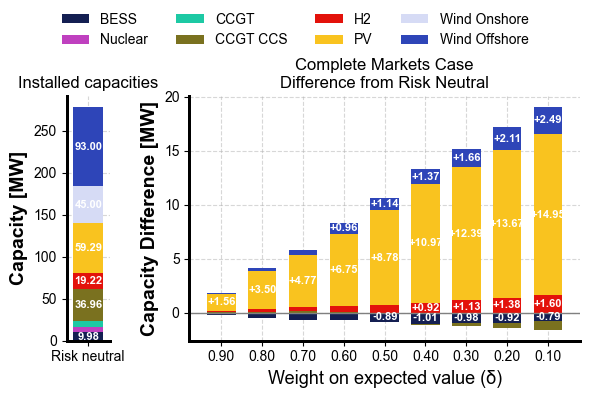

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
from matplotlib.patches import Rectangle

# === Matplotlib setup ===
rcParams['patch.edgecolor'] = 'none'
rcParams['patch.linewidth'] = 0
rcParams['patch.antialiased'] = False
rcParams['font.family'] = 'Arial'
rcParams['axes.labelweight'] = 'bold'

# === Load & filter data ===
df_raw = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\risk_aversion_results.csv")
df = df_raw[df_raw["delta"] != 0]

capacity_cols = ['PV', 'Gas', 'Gas_CCS', 'Wind_Onshore', 'Wind_Offshore', 'Nuclear', 'BESS_P', 'H2_P']
df = df[['delta'] + capacity_cols]

# === Split data ===
df_rn = df[df['delta'] == 1].iloc[0]
df_others = df[df['delta'] != 1].sort_values('delta')

# === Techs, labels, colors ===
techs  = ['BESS_P', 'Nuclear', 'Gas', 'Gas_CCS', 'H2_P', 'PV', 'Wind_Onshore', 'Wind_Offshore']
labels = ['BESS',   'Nuclear', 'CCGT', 'CCGT CCS', 'H2',   'PV', 'Wind Onshore', 'Wind Offshore']
colors = {
    'BESS_P': '#141F52',
    'Nuclear': '#BF40BF',
    'Gas': '#1DC9A4',
    'Gas_CCS': "#7a711f",
    'H2_P': '#E3120B',
    'PV': '#F9C31F',
    'Wind_Onshore': '#D6DBF5',
    'Wind_Offshore': '#2E45B8'
}

# === Plot setup ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 4), gridspec_kw={'width_ratios': [1, 9]}) # itan 1 4

for ax in [ax1, ax2]:
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.xaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)

# === Left: Risk Neutral ===
bar_width = 0.35
bottom = 0
for tech in techs:
    value = df_rn[tech]
    ax1.bar(0.25, value, width=bar_width, bottom=bottom, color=colors[tech])
    #ax1.bar(0, value, width=bar_width, bottom=bottom, color=colors[tech])
    if value > 9.90:
        ax1.text(0.25, bottom + value / 2, f'{value:.2f}', ha='center', va='center', color='white', fontsize=8, fontweight='bold')
    bottom += value
ax1.set_xticks([0.25])
ax1.set_xlim(0, 0.5)
ax1.set_xticklabels(['Risk neutral'], fontsize=11)
ax1.set_ylabel("Capacity [MW]", fontsize=14, fontweight='bold')
ax1.set_title("Installed capacities", fontsize=12, fontweight='normal')
ax1.tick_params(labelsize=10)

# === Right: Differences ===
deltas = sorted(df_others['delta'].unique(), reverse=True)
x = np.arange(len(deltas))
df_others = df_others.set_index('delta').loc[deltas].reset_index()
width = 0.7

bottom_pos = np.zeros_like(x, dtype=float)
bottom_neg = np.zeros_like(x, dtype=float)

for tech in techs:
    diffs = df_others[tech].values - df_rn[tech]
    for i, diff in enumerate(diffs):
        if diff >= 0.01:
            ax2.bar(x[i], diff, width=width, bottom=bottom_pos[i], color=colors[tech])
            if diff >= 0.78:
                ax2.text(x[i], bottom_pos[i] + diff / 2, f'+{diff:.2f}', ha='center', va='center', fontsize=8, color='white',fontweight='bold')
            
            bottom_pos[i] += diff
        else:
            ax2.bar(x[i], diff, width=width, bottom=bottom_neg[i], color=colors[tech])
            if abs(diff) > 0.78:
                ax2.text(x[i], bottom_neg[i] + diff / 2, f'{diff:.2f}', ha='center', va='center', fontsize=8, color='white',fontweight='bold')
            bottom_neg[i] += diff

ax2.set_xticks(x)
ax2.set_xticklabels([f"{d:.2f}" for d in deltas], fontsize=10)
ax2.set_xlabel("Weight on expected value (δ)", fontsize=13, fontweight='normal')
ax2.set_ylabel("Capacity Difference [MW]", fontsize=14, fontweight='bold')
ax2.set_title("Complete Markets Case\nDifference from Risk Neutral", fontsize=12, fontweight='normal')
#ax2.set_title("Incomplete Markets Case\nDifference from Risk Neutral", fontsize=13, fontweight='normal')
ax2.axhline(0, color='gray', linewidth=1)

from matplotlib.patches import Rectangle
import matplotlib.lines as mlines

# === Legend ===
#handles = [plt.Rectangle((0, 0), 1, 1, color=colors[t]) for t in techs]
#fig.legend(handles, labels, loc='upper center', ncol=len(techs), fontsize=9, frameon=False)
handles = [Rectangle((0, 0), 1, 1, facecolor=colors[t], edgecolor='black') for t in techs]
fig.legend(handles, labels, loc='upper center', ncol=4, fontsize=10, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

fig.savefig("complete_type2.png", dpi=600, bbox_inches='tight')

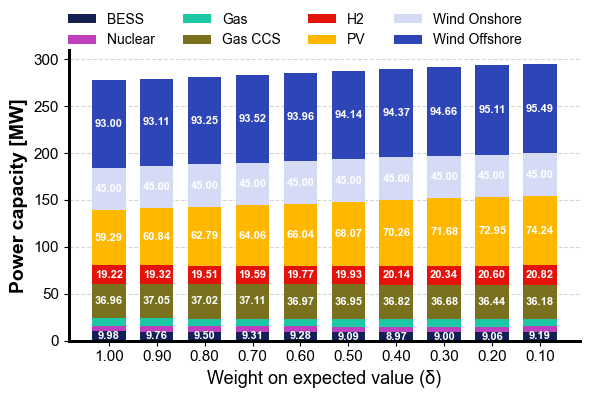

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
from matplotlib.patches import Rectangle

# === Matplotlib setup ===
rcParams['patch.edgecolor'] = 'none'
rcParams['patch.linewidth'] = 0
rcParams['patch.antialiased'] = False
rcParams['font.family'] = 'Arial'
rcParams['axes.labelweight'] = 'bold'

# === Load & filter data ===
df_raw = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\risk_aversion_results.csv")
df = df_raw[df_raw["delta"] != 0]

capacity_cols = ['PV', 'Gas', 'Gas_CCS', 'Wind_Onshore', 'Wind_Offshore', 'Nuclear', 'BESS_P', 'H2_P']
df = df[['delta'] + capacity_cols]

# target deltas (ensure present, keep this order)
target_deltas = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5,0.4,0.3,0.2,0.1]
df_plot = (
    df[df['delta'].round(2).isin([round(d, 2) for d in target_deltas])]
    .drop_duplicates(subset=['delta'])
    .set_index('delta')
    .reindex(target_deltas)
)

# === Techs, labels, colors ===
techs  = ['BESS_P', 'Nuclear', 'Gas', 'Gas_CCS', 'H2_P', 'PV', 'Wind_Onshore', 'Wind_Offshore']
labels = ['BESS',   'Nuclear', 'Gas', 'Gas CCS', 'H2',   'PV', 'Wind Onshore', 'Wind Offshore']
colors = {
    'BESS_P': '#141F52',
    'Nuclear': '#BF40BF',
    'Gas': '#1DC9A4',
    'Gas_CCS': "#7a711f",
    'H2_P': '#E3120B',
    'PV': '#FFB700',
    'Wind_Onshore': '#D6DBF5',
    'Wind_Offshore': '#2E45B8'
}

# === Single figure/axes ===
fig, ax = plt.subplots(figsize=(6, 4))
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

x = np.arange(len(target_deltas))
bar_width = 0.7

# stacked bars + white labels
bottom = np.zeros(len(target_deltas), dtype=float)
for tech in techs:
    vals = df_plot[tech].to_numpy(dtype=float)
    bars = ax.bar(x, vals, width=bar_width, bottom=bottom, color=colors[tech])
    for i, bar in enumerate(bars):
        if vals[i] > 0.1:  # avoid tiny labels
            if 8.9 < vals[i]<10:
                ax.text(
                    bar.get_x() + bar.get_width()/2,
                    bottom[i] + vals[i]/2,
                    f"{vals[i]:.2f}",
                    ha="center", va="center",
                    color="white", fontsize=8, fontweight="bold"
                )
            elif 10 < vals[i]:
                ax.text(
                    bar.get_x() + bar.get_width()/2,
                    bottom[i] + vals[i]/2,
                    f"{vals[i]:.2f}",
                    ha="center", va="center",
                    color="white", fontsize=8, fontweight="bold"
                )
                
    bottom += vals

# labels/ticks
ax.set_xticks(x)
ax.set_xticklabels([f"{d:.2f}" for d in target_deltas], fontsize=11)
ax.set_xlabel("Weight on expected value (δ)", fontsize=13, fontweight = 'normal')
ax.set_ylabel("Power capacity [MW]", fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=11)


# legend
handles = [Rectangle((0, 0), 1, 1, facecolor=colors[t]) for t in techs]
fig.legend(handles, labels, loc='upper center', ncol=len(techs)/2, fontsize=10, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


fig.savefig("complete_pscc.png", format="png", dpi=600, bbox_inches="tight")

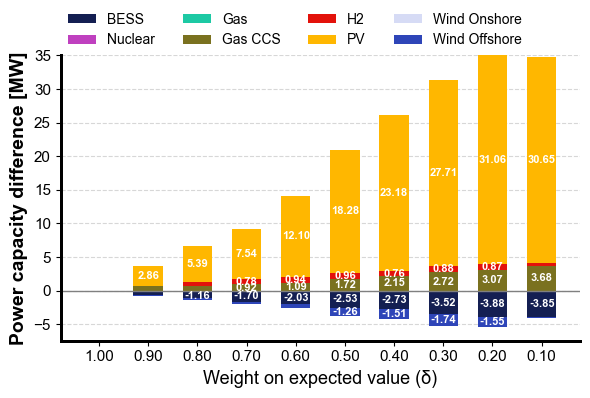

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
from matplotlib.patches import Rectangle

# === Matplotlib setup ===
rcParams['patch.edgecolor'] = 'none'
rcParams['patch.linewidth'] = 0
rcParams['patch.antialiased'] = False
rcParams['font.family'] = 'Arial'
rcParams['axes.labelweight'] = 'bold'

# === Load & filter data (BASELINE from CSV) ===
df_raw = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\risk_aversion_results.csv")
df2_raw = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Fully_incomplete_markets_ADMM\PSCC\PSCC_higher_resolution\trycodes_3_final_higher_resolution\H2_15000_ADMM_risk_aversion_results.csv")

df = df_raw[df_raw["delta"] != 0]

capacity_cols = ['PV', 'Gas', 'Gas_CCS', 'Wind_Onshore', 'Wind_Offshore', 'Nuclear', 'BESS_P', 'H2_P']
df = df[['delta'] + capacity_cols]

# target deltas (ensure present, keep this order)
#target_deltas = [1.00, 0.75, 0.50, 0.25]
target_deltas = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5,0.4,0.3,0.2,0.1]
df_plot = (
    df[df['delta'].round(2).isin([round(d, 2) for d in target_deltas])]
    .drop_duplicates(subset=['delta'])
    .set_index('delta')
    .reindex(target_deltas)
)



df2 = df2_raw[df2_raw["delta"] != 0]
df2 = df2[['delta'] + capacity_cols]
df_plot2 = (
    df2[df2['delta'].round(2).isin([round(d, 2) for d in target_deltas])]
    .drop_duplicates(subset=['delta'])
    .set_index('delta')
    .reindex(target_deltas)
)

# === Compute differences (Excel - CSV) for each tech & delta ===
diff_plot = -(df_plot2[capacity_cols] - df_plot[capacity_cols])


# === Techs, labels, colors ===
techs  = ['BESS_P', 'Nuclear', 'Gas', 'Gas_CCS', 'H2_P', 'PV', 'Wind_Onshore', 'Wind_Offshore']
labels = ['BESS',   'Nuclear', 'Gas', 'Gas CCS', 'H2',   'PV', 'Wind Onshore', 'Wind Offshore']
colors = {
    'BESS_P': '#141F52',
    'Nuclear': '#BF40BF',
    'Gas': '#1DC9A4',
    'Gas_CCS': "#7a711f",
    'H2_P': '#E3120B',
    'PV': '#FFB700',
    'Wind_Onshore': '#D6DBF5',
    'Wind_Offshore': '#2E45B8'
}

# === Single figure/axes ===
fig, ax = plt.subplots(figsize=(6, 4))
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

x = np.arange(len(target_deltas))
bar_width = 0.6

# === Stacked bars of DIFFERENCES (positives up, negatives down) + white labels ===
bottom_pos = np.zeros(len(target_deltas), dtype=float)
bottom_neg = np.zeros(len(target_deltas), dtype=float)

for tech in techs:
    diffs = diff_plot[tech].to_numpy(dtype=float)

    # positive part
    pos = np.where(diffs > 0, diffs, 0.0)
    bars_pos = ax.bar(x, pos, width=bar_width, bottom=bottom_pos, color=colors[tech])
    for i, bar in enumerate(bars_pos):
        if pos[i] > 0.49:
            if 0.76 < pos[i] < 1:
                ax.text(
                    bar.get_x() + bar.get_width()/2,
                    bottom_pos[i] + pos[i]/2,
                    f"{pos[i]:.2f}",
                    ha="center", va="center",
                    color="white", fontsize=8, fontweight="bold"
                )
            elif pos[i] > 1:
                ax.text(
                bar.get_x() + bar.get_width()/2,
                bottom_pos[i] + pos[i]/2,
                f"{pos[i]:.2f}",
                ha="center", va="center",
                color="white", fontsize=8, fontweight="bold"
            )
            
    bottom_pos += pos

    # negative part
    neg = np.where(diffs < 0, diffs, 0.0)
    bars_neg = ax.bar(x, neg, width=bar_width, bottom=bottom_neg, color=colors[tech])
    for i, bar in enumerate(bars_neg):
        if -1.17 < neg[i] < -1:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bottom_neg[i] + neg[i]/1.5,
                f"{neg[i]:.2f}",
                ha="center", va="center",
                color="white", fontsize=8, fontweight="bold"
            )
        elif  neg[i] < -1.18:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bottom_neg[i] + neg[i]/2,
                f"{neg[i]:.2f}",
                ha="center", va="center",
                color="white", fontsize=8, fontweight="bold"
            )
    bottom_neg += neg

# labels/ticks
ax.set_xticks(x)
ax.set_xticklabels([f"{d:.2f}" for d in target_deltas], fontsize=11)
ax.set_xlabel("Weight on expected value (δ)", fontsize=13, fontweight='normal')
ax.set_ylabel("Power capacity difference [MW]", fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=11)
ax.axhline(0, color='gray', linewidth=1)

# legend
handles = [Rectangle((0, 0), 1, 1, facecolor=colors[t]) for t in techs]
fig.legend(handles, labels, loc='upper center', ncol=len(techs)/2, fontsize=10, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


fig.savefig("incomplete_pscc.png", format="png", dpi=600, bbox_inches="tight")

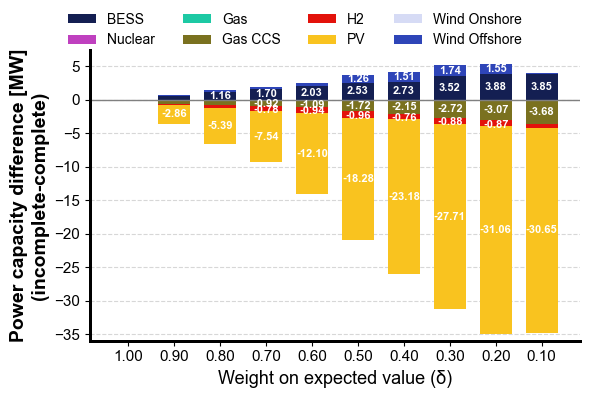

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
from matplotlib.patches import Rectangle

# === Matplotlib setup ===
rcParams['patch.edgecolor'] = 'none'
rcParams['patch.linewidth'] = 0
rcParams['patch.antialiased'] = False
rcParams['font.family'] = 'Arial'
rcParams['axes.labelweight'] = 'bold'

# === Load & filter data (BASELINE from CSV) ===
df_raw = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\risk_aversion_results.csv")
df2_raw = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Fully_incomplete_markets_ADMM\PSCC\PSCC_higher_resolution\trycodes_3_final_higher_resolution\H2_15000_ADMM_risk_aversion_results.csv")

df = df_raw[df_raw["delta"] != 0]

capacity_cols = ['PV', 'Gas', 'Gas_CCS', 'Wind_Onshore', 'Wind_Offshore', 'Nuclear', 'BESS_P', 'H2_P']
df = df[['delta'] + capacity_cols]

# target deltas (ensure present, keep this order)
#target_deltas = [1.00, 0.75, 0.50, 0.25]
target_deltas = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5,0.4,0.3,0.2,0.1]
df_plot = (
    df[df['delta'].round(2).isin([round(d, 2) for d in target_deltas])]
    .drop_duplicates(subset=['delta'])
    .set_index('delta')
    .reindex(target_deltas)
)



df2 = df2_raw[df2_raw["delta"] != 0]
df2 = df2[['delta'] + capacity_cols]
df_plot2 = (
    df2[df2['delta'].round(2).isin([round(d, 2) for d in target_deltas])]
    .drop_duplicates(subset=['delta'])
    .set_index('delta')
    .reindex(target_deltas)
)

# === Compute differences (Excel - CSV) for each tech & delta ===
diff_plot = (df_plot2[capacity_cols] - df_plot[capacity_cols])


# === Techs, labels, colors ===
techs  = ['BESS_P', 'Nuclear', 'Gas', 'Gas_CCS', 'H2_P', 'PV', 'Wind_Onshore', 'Wind_Offshore']
labels = ['BESS',   'Nuclear', 'Gas', 'Gas CCS', 'H2',   'PV', 'Wind Onshore', 'Wind Offshore']
colors = {
    'BESS_P': '#141F52',
    'Nuclear': '#BF40BF',
    'Gas': '#1DC9A4',
    'Gas_CCS': "#7a711f",
    'H2_P': '#E3120B',
    'PV': '#F9C31F',
    'Wind_Onshore': '#D6DBF5',
    'Wind_Offshore': '#2E45B8'
}

# === Single figure/axes ===
fig, ax = plt.subplots(figsize=(6, 4))
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

x = np.arange(len(target_deltas))
bar_width = 0.7

# === Stacked bars of DIFFERENCES (positives up, negatives down) + white labels ===
bottom_pos = np.zeros(len(target_deltas), dtype=float)
bottom_neg = np.zeros(len(target_deltas), dtype=float)

for tech in techs:
    diffs = diff_plot[tech].to_numpy(dtype=float)

    # positive part
    pos = np.where(diffs > 0, diffs, 0.0)
    bars_pos = ax.bar(x, pos, width=bar_width, bottom=bottom_pos, color=colors[tech])
    for i, bar in enumerate(bars_pos):
        if pos[i] > 0.49:
            if 0.76 < pos[i] < 1:
                ax.text(
                    bar.get_x() + bar.get_width()/2,
                    bottom_pos[i] + pos[i]/2,
                    f"{pos[i]:.2f}",
                    ha="center", va="center",
                    color="white", fontsize=8, fontweight="bold"
                )
            elif pos[i] > 1:
                ax.text(
                bar.get_x() + bar.get_width()/2,
                bottom_pos[i] + pos[i]/2,
                f"{pos[i]:.2f}",
                ha="center", va="center",
                color="white", fontsize=8, fontweight="bold"
            )
            
    bottom_pos += pos

    # negative part
    neg = np.where(diffs < 0, diffs, 0.0)
    bars_neg = ax.bar(x, neg, width=bar_width, bottom=bottom_neg, color=colors[tech])
    for i, bar in enumerate(bars_neg):
        if -1.17 < neg[i] < -0.91:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bottom_neg[i] + neg[i]/1.5,
                f"{neg[i]:.2f}",
                ha="center", va="center",
                color="white", fontsize=8, fontweight="bold"
            )
        elif  neg[i] < -1.18:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bottom_neg[i] + neg[i]/2,
                f"{neg[i]:.2f}",
                ha="center", va="center",
                color="white", fontsize=8, fontweight="bold"
            )
        elif -0.91 <neg[i]<-0.75:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bottom_neg[i] + neg[i]/1.4,
                f"{neg[i]:.2f}",
                ha="center", va="center",
                color="white", fontsize=8, fontweight="bold"
            )
    bottom_neg += neg

# labels/ticks
ax.set_xticks(x)
ax.set_xticklabels([f"{d:.2f}" for d in target_deltas], fontsize=11)
ax.set_xlabel("Weight on expected value (δ)", fontsize=13, fontweight='normal')
ax.set_ylabel("Power capacity difference [MW]\n(incomplete-complete)", fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=11)
ax.set_ylim(-36,None)
ax.axhline(0, color='gray', linewidth=1)

# legend
handles = [Rectangle((0, 0), 1, 1, facecolor=colors[t]) for t in techs]
fig.legend(handles, labels, loc='upper center', ncol=len(techs)/2, fontsize=10, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


fig.savefig("incomplete_pscc_new.png", format="png", dpi=600, bbox_inches="tight")

19.31977138 19.23405232 4067.492761 4004.083593
19.51088594 19.0124724 4105.244416 3935.169165
19.58971865 18.80761818 4115.887978 3889.966734
19.76935034 18.83061061 4161.430641 3912.836907
19.92543202 18.96428556 4183.204136 3974.581419
20.13869337 19.37674211 4226.914198 3984.054698
20.34392126 19.46736703 4270.726338 3928.744703
20.60024227 19.7268926 4335.214123 3884.467205
20.81716493 20.32294451 4401.100487 3437.604266


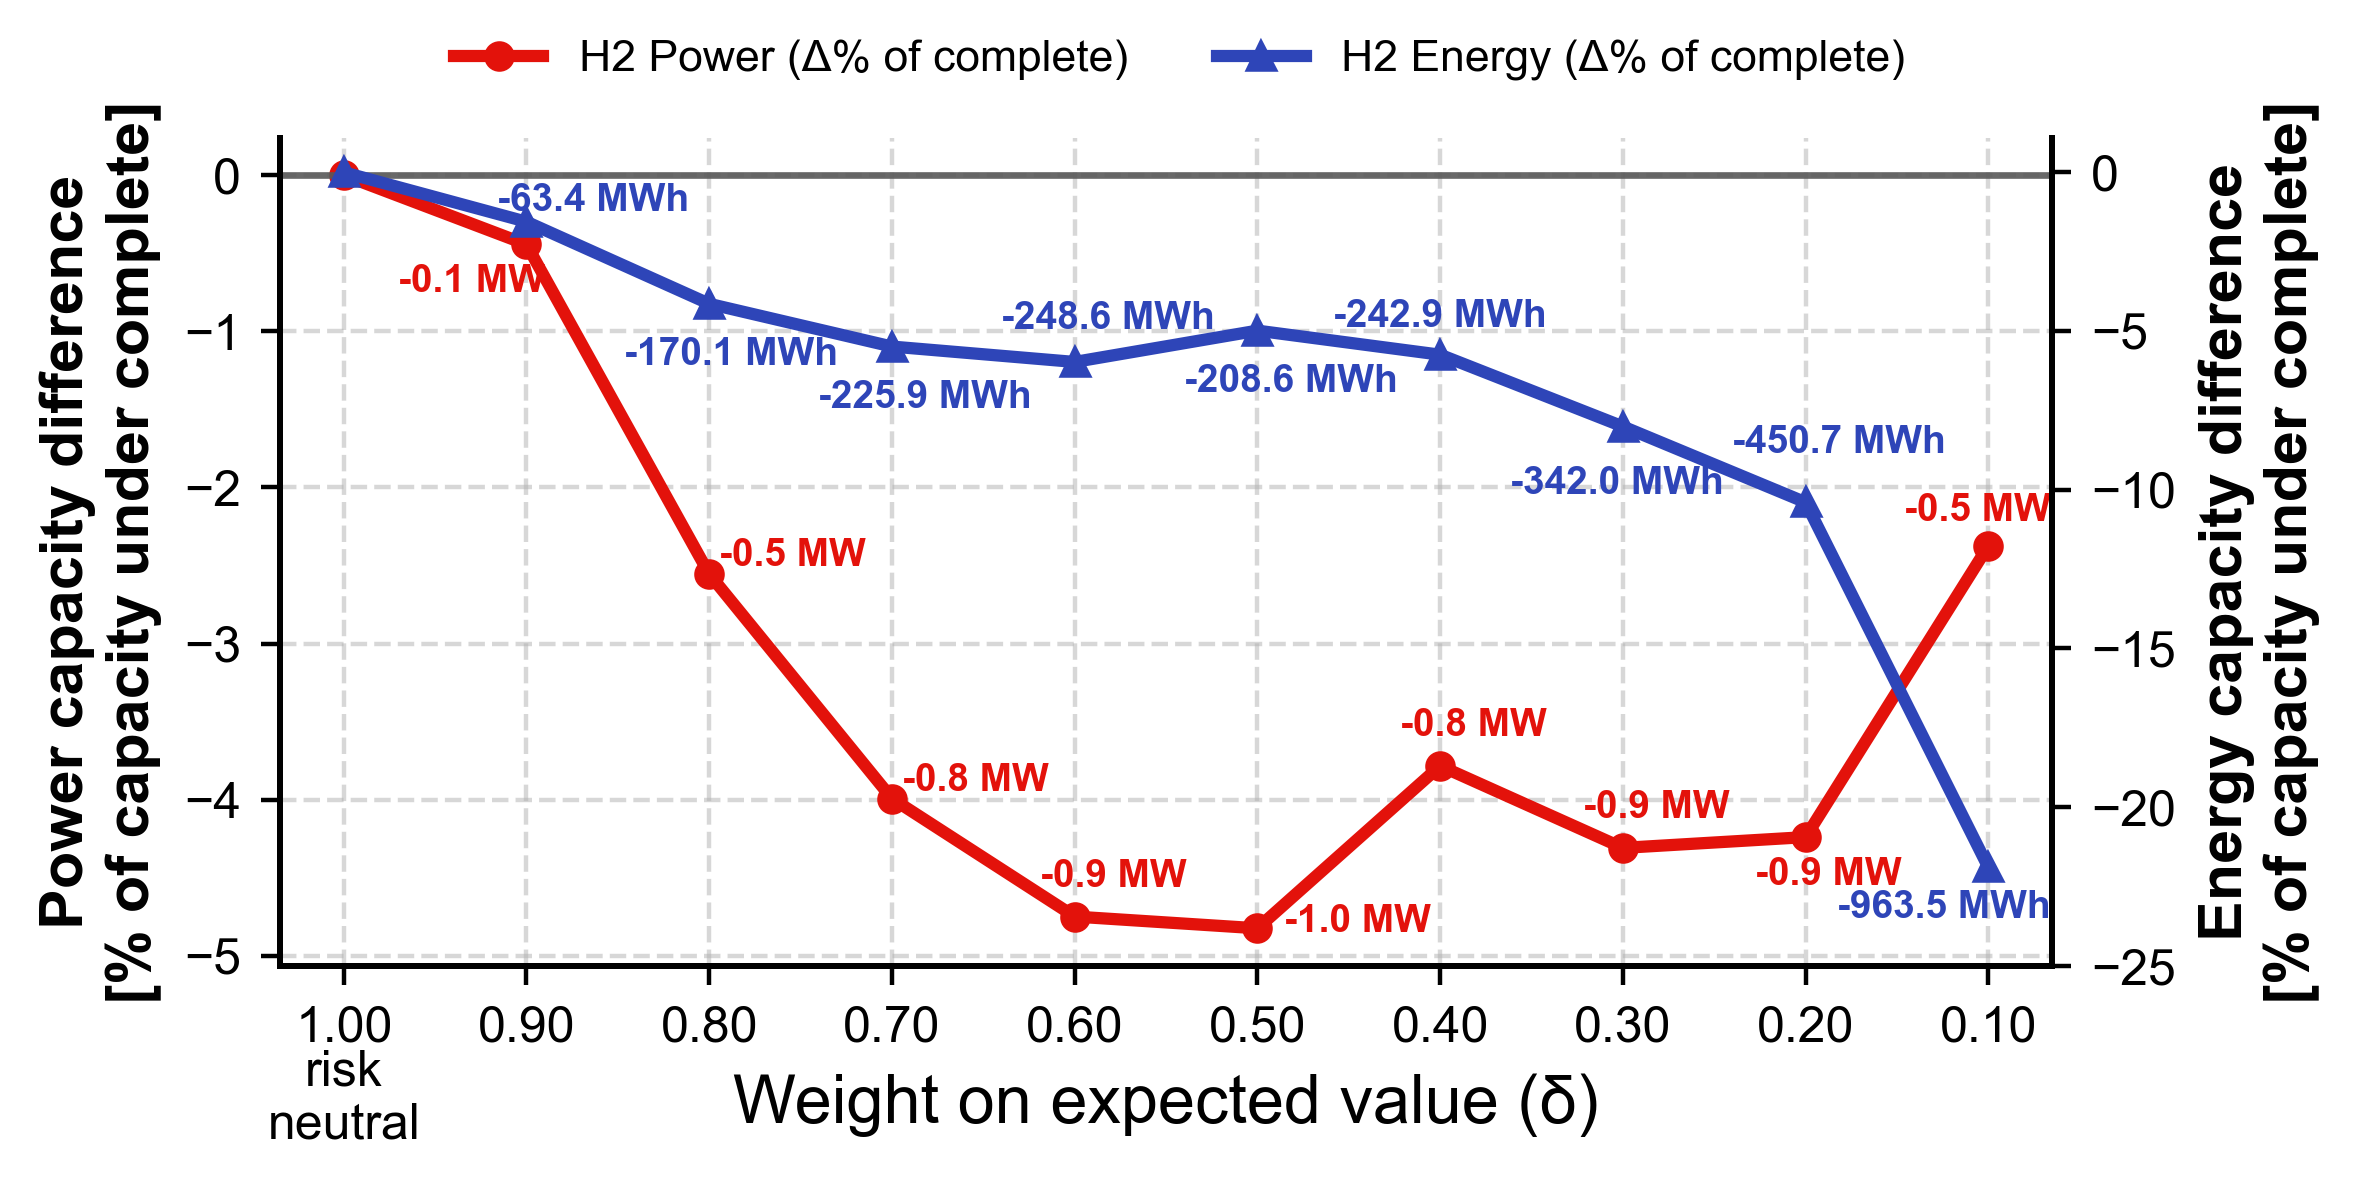

In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams



# === Matplotlib setup ===
rcParams['patch.edgecolor']   = 'none'
rcParams['patch.linewidth']   = 0
rcParams['patch.antialiased'] = False
rcParams['font.family']       = 'Arial'     # (2) Arial
rcParams['axes.labelweight']  = 'bold'

# === Load & filter data (BASELINE from CSV) ===
df_c = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\risk_aversion_results.csv")
df_i = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Fully_incomplete_markets_ADMM\PSCC\PSCC_higher_resolution\trycodes_3_final_higher_resolution\H2_15000_ADMM_risk_aversion_results.csv")

# keep only needed cols, filter weird deltas
need = ['delta', 'H2_P', 'H2_E']
df_c = df_c[need].copy()
df_i = df_i[need].copy()
df_c = df_c[df_c['delta'] != 0]
df_i = df_i[df_i['delta'] != 0]

# round deltas for robust matching
df_c['delta_r'] = df_c['delta'].round(2)
df_i['delta_r'] = df_i['delta'].round(2)

# inner-join on rounded delta so both datasets exist at that weight
dfm = pd.merge(
    df_c.rename(columns={'H2_P': 'H2_P_c', 'H2_E': 'H2_E_c'}),
    df_i.rename(columns={'H2_P': 'H2_P_i', 'H2_E': 'H2_E_i'}),
    on='delta_r', how='inner', suffixes=('_c','_i')
)

# === Percentage differences relative to COMPLETE (1) ===
# %Δ = 100 * (Complete - Incomplete) / Complete
dfm['H2_P_pct'] = 100.0 * (-dfm['H2_P_c'] + dfm['H2_P_i']) / dfm['H2_P_c'].replace(0, np.nan)
dfm['H2_E_pct'] = 100.0 * (-dfm['H2_E_c'] + dfm['H2_E_i']) / dfm['H2_E_c'].replace(0, np.nan)

# Choose x-axis deltas from 0.20 to 1.00 present in BOTH datasets
x_vals = (
    dfm.loc[(dfm['delta_r'] >= 0.10) & (dfm['delta_r'] <= 1.00), 'delta_r']
    .drop_duplicates()
    .sort_values(ascending=False)       # (1) 1.00 on the LEFT
    .to_numpy()
)

# align to x
df_plot = (
    dfm.set_index('delta_r')
       .loc[x_vals, ['H2_P_pct','H2_E_pct','H2_P_c','H2_E_c','H2_P_i','H2_E_i']]
       .astype(float)
)

# ========= Figure (5) 6x3 inches =========
fig, ax1 = plt.subplots(figsize=(6, 3), dpi=400)

# general axes styling
for spine in ['top', 'right']:
    ax1.spines[spine].set_visible(False)
ax1.yaxis.grid(True, linestyle='--', alpha=0.5)
ax1.xaxis.grid(True, linestyle='--', alpha=0.5)
ax1.set_axisbelow(True)

# (4) Economist palette colors
col_power  = '#E3120B'  # red
col_energy = '#2E45B8'  # blue

# primary axis: Power % difference
line1, = ax1.plot(
    x_vals, df_plot['H2_P_pct'].to_numpy(),
    linewidth=2.2, marker='o', ms=4.5, label='H2 Power (Δ% of complete)'
)
line1.set_color(col_power)

ax1.set_xlabel("Weight on expected value (δ)", fontsize=12, fontweight='normal')
ax1.set_ylabel("Power capacity difference\n[% of capacity under complete]", fontsize=11)
ax1.tick_params(axis='x', labelsize=9)
ax1.tick_params(axis='y', labelsize=9)

# secondary axis: Energy % difference
ax2 = ax1.twinx()
for spine in ['top', 'left']:
    ax2.spines[spine].set_visible(False)

line2, = ax2.plot(
    x_vals, df_plot['H2_E_pct'].to_numpy(),
    linewidth=2.2, marker='^', ms=4.5, linestyle='-',
    label='H2 Energy (Δ% of complete)'
)
line2.set_color(col_energy)
ax2.set_ylabel("Energy capacity difference\n[% of capacity under complete]", fontsize=11)
ax2.tick_params(axis='y', labelsize=9)


# x ticks shown as 2 decimals (descending)
ax1.set_xticks(x_vals)
ax1.set_xticklabels([f"{x:.2f}" for x in x_vals], rotation=0, fontsize=9)

ax1.set_xlim(1.035, float(np.min(x_vals)-0.035))
ax2.set_ylim(-25, None)

ax1.text(
    1.00, -0.10, "risk\nneutral",
    transform=ax1.get_xaxis_transform(),  # x in data coords, y in axes fraction
    ha='center', va='top', fontsize=9
)

# (3) zero line in dark grey
ax1.axhline(0, linewidth=1.2, linestyle='-', color='0.35', alpha=0.9)

# Legend (top, single row, no frame)
lines = [line1, line2]
labels = [l.get_label() for l in lines]
fig.legend(lines, labels, loc='upper center', ncol=2, fontsize=8, frameon=False)

# (6) End labels at δ = 1.00 and δ = 0.20 with ABSOLUTE complete values

for delta_end in [0.9]:
    if delta_end in df_plot.index:
        # positions (percent differences)
        y1 = df_plot.loc[delta_end, 'H2_P_pct']
        y2 = df_plot.loc[delta_end, 'H2_E_pct']
        # absolute COMPLETE values to display
        p_abs = df_plot.loc[delta_end, 'H2_P_c']
        e_abs = df_plot.loc[delta_end, 'H2_E_c']
        p_abs1 = df_plot.loc[delta_end, 'H2_P_i']
        e_abs1 = df_plot.loc[delta_end, 'H2_E_i']
        print(p_abs,p_abs1,e_abs,e_abs1)
        # annotate near each series' marker (offset a few points to declutter)
        ax1.annotate(f"{-p_abs+p_abs1:.1f} MW",
                     xy=(delta_end, y1),
                     xytext=(-10, -10), textcoords="offset points",
                     ha='center', va='bottom', fontsize=7, color=col_power,
                     fontweight='bold')
        ax2.annotate(f"{-e_abs+e_abs1:.1f} MWh",
                     xy=(delta_end, y2),
                     xytext=(12,7), textcoords="offset points",
                     ha='center', va='top', fontsize=7, color=col_energy,
                     fontweight='bold')
for delta_end in [0.8]:
    if delta_end in df_plot.index:
        # positions (percent differences)
        y1 = df_plot.loc[delta_end, 'H2_P_pct']
        y2 = df_plot.loc[delta_end, 'H2_E_pct']
        # absolute COMPLETE values to display
        p_abs = df_plot.loc[delta_end, 'H2_P_c']
        e_abs = df_plot.loc[delta_end, 'H2_E_c']
        p_abs1 = df_plot.loc[delta_end, 'H2_P_i']
        e_abs1 = df_plot.loc[delta_end, 'H2_E_i']
        print(p_abs,p_abs1,e_abs,e_abs1)
        # annotate near each series' marker (offset a few points to declutter)
        ax1.annotate(f"{-p_abs+p_abs1:.1f} MW",
                     xy=(delta_end, y1),
                     xytext=(15, 0), textcoords="offset points",
                     ha='center', va='bottom', fontsize=7, color=col_power,
                     fontweight='bold')
        ax2.annotate(f"{-e_abs+e_abs1:.1f} MWh",
                     xy=(delta_end, y2),
                     xytext=(4, -6), textcoords="offset points",
                     ha='center', va='top', fontsize=7, color=col_energy,
                     fontweight='bold')
for delta_end in [0.7]:
    if delta_end in df_plot.index:
        # positions (percent differences)
        y1 = df_plot.loc[delta_end, 'H2_P_pct']
        y2 = df_plot.loc[delta_end, 'H2_E_pct']
        # absolute COMPLETE values to display
        p_abs = df_plot.loc[delta_end, 'H2_P_c']
        e_abs = df_plot.loc[delta_end, 'H2_E_c']
        p_abs1 = df_plot.loc[delta_end, 'H2_P_i']
        e_abs1 = df_plot.loc[delta_end, 'H2_E_i']
        print(p_abs,p_abs1,e_abs,e_abs1)
        # annotate near each series' marker (offset a few points to declutter)
        ax1.annotate(f"{-p_abs+p_abs1:.1f} MW",
                     xy=(delta_end, y1),
                     xytext=(15, 0), textcoords="offset points",
                     ha='center', va='bottom', fontsize=7, color=col_power,
                     fontweight='bold')
        ax2.annotate(f"{-e_abs+e_abs1:.1f} MWh",
                     xy=(delta_end, y2),
                     xytext=(6, -6), textcoords="offset points",
                     ha='center', va='top', fontsize=7, color=col_energy,
                     fontweight='bold')
for delta_end in [0.6]:
    if delta_end in df_plot.index:
        # positions (percent differences)
        y1 = df_plot.loc[delta_end, 'H2_P_pct']
        y2 = df_plot.loc[delta_end, 'H2_E_pct']
        # absolute COMPLETE values to display
        p_abs = df_plot.loc[delta_end, 'H2_P_c']
        e_abs = df_plot.loc[delta_end, 'H2_E_c']
        p_abs1 = df_plot.loc[delta_end, 'H2_P_i']
        e_abs1 = df_plot.loc[delta_end, 'H2_E_i']
        print(p_abs,p_abs1,e_abs,e_abs1)
        # annotate near each series' marker (offset a few points to declutter)
        ax1.annotate(f"{-p_abs+p_abs1:.1f} MW",
                     xy=(delta_end, y1),
                     xytext=(7, +4), textcoords="offset points",
                     ha='center', va='bottom', fontsize=7, color=col_power,
                     fontweight='bold')
        ax2.annotate(f"{-e_abs+e_abs1:.1f} MWh",
                     xy=(delta_end, y2),
                     xytext=(6, +11), textcoords="offset points",
                     ha='center', va='top', fontsize=7, color=col_energy,
                     fontweight='bold')
for delta_end in [0.5]:
    if delta_end in df_plot.index:
        # positions (percent differences)
        y1 = df_plot.loc[delta_end, 'H2_P_pct']
        y2 = df_plot.loc[delta_end, 'H2_E_pct']
        # absolute COMPLETE values to display
        p_abs = df_plot.loc[delta_end, 'H2_P_c']
        e_abs = df_plot.loc[delta_end, 'H2_E_c']
        p_abs1 = df_plot.loc[delta_end, 'H2_P_i']
        e_abs1 = df_plot.loc[delta_end, 'H2_E_i']
        print(p_abs,p_abs1,e_abs,e_abs1)
        # annotate near each series' marker (offset a few points to declutter)
        ax1.annotate(f"{-p_abs+p_abs1:.1f} MW",
                     xy=(delta_end, y1),
                     xytext=(18 ,-2), textcoords="offset points",
                     ha='center', va='bottom', fontsize=7, color=col_power,
                     fontweight='bold')
        ax2.annotate(f"{-e_abs+e_abs1:.1f} MWh",
                     xy=(delta_end, y2),
                     xytext=(6, -6), textcoords="offset points",
                     ha='center', va='top', fontsize=7, color=col_energy,
                     fontweight='bold')
for delta_end in [0.4]:
    if delta_end in df_plot.index:
        # positions (percent differences)
        y1 = df_plot.loc[delta_end, 'H2_P_pct']
        y2 = df_plot.loc[delta_end, 'H2_E_pct']
        # absolute COMPLETE values to display
        p_abs = df_plot.loc[delta_end, 'H2_P_c']
        e_abs = df_plot.loc[delta_end, 'H2_E_c']
        p_abs1 = df_plot.loc[delta_end, 'H2_P_i']
        e_abs1 = df_plot.loc[delta_end, 'H2_E_i']
        print(p_abs,p_abs1,e_abs,e_abs1)
        # annotate near each series' marker (offset a few points to declutter)
        ax1.annotate(f"{-p_abs+p_abs1:.1f} MW",
                     xy=(delta_end, y1),
                     xytext=(6, +4), textcoords="offset points",
                     ha='center', va='bottom', fontsize=7, color=col_power,
                     fontweight='bold')
        ax2.annotate(f"{-e_abs+e_abs1:.1f} MWh",
                     xy=(delta_end, y2),
                     xytext=(0, +10), textcoords="offset points",
                     ha='center', va='top', fontsize=7, color=col_energy,
                     fontweight='bold')
for delta_end in [0.3]:
    if delta_end in df_plot.index:
        # positions (percent differences)
        y1 = df_plot.loc[delta_end, 'H2_P_pct']
        y2 = df_plot.loc[delta_end, 'H2_E_pct']
        # absolute COMPLETE values to display
        p_abs = df_plot.loc[delta_end, 'H2_P_c']
        e_abs = df_plot.loc[delta_end, 'H2_E_c']
        p_abs1 = df_plot.loc[delta_end, 'H2_P_i']
        e_abs1 = df_plot.loc[delta_end, 'H2_E_i']
        print(p_abs,p_abs1,e_abs,e_abs1)
        # annotate near each series' marker (offset a few points to declutter)
        ax1.annotate(f"{-p_abs+p_abs1:.1f} MW",
                     xy=(delta_end, y1),
                     xytext=(6, +4), textcoords="offset points",
                     ha='center', va='bottom', fontsize=7, color=col_power,
                     fontweight='bold')
        ax2.annotate(f"{-e_abs+e_abs1:.1f} MWh",
                     xy=(delta_end, y2),
                     xytext=(-1, -7), textcoords="offset points",
                     ha='center', va='top', fontsize=7, color=col_energy,
                     fontweight='bold')
for delta_end in [0.2]:
    if delta_end in df_plot.index:
        # positions (percent differences)
        y1 = df_plot.loc[delta_end, 'H2_P_pct']
        y2 = df_plot.loc[delta_end, 'H2_E_pct']
        # absolute COMPLETE values to display
        p_abs = df_plot.loc[delta_end, 'H2_P_c']
        e_abs = df_plot.loc[delta_end, 'H2_E_c']
        p_abs1 = df_plot.loc[delta_end, 'H2_P_i']
        e_abs1 = df_plot.loc[delta_end, 'H2_E_i']
        print(p_abs,p_abs1,e_abs,e_abs1)
        # annotate near each series' marker (offset a few points to declutter)
        ax1.annotate(f"{-p_abs+p_abs1:.1f} MW",
                     xy=(delta_end, y1),
                     xytext=(4, -10), textcoords="offset points",
                     ha='center', va='bottom', fontsize=7, color=col_power,
                     fontweight='bold')
        ax2.annotate(f"{-e_abs+e_abs1:.1f} MWh",
                     xy=(delta_end, y2),
                     xytext=(6, 14), textcoords="offset points",
                     ha='center', va='top', fontsize=7, color=col_energy,
                     fontweight='bold')
"""
for delta_end in [1.00]:
    if delta_end in df_plot.index:
        # positions (percent differences)
        y1 = df_plot.loc[delta_end, 'H2_P_pct']
        y2 = df_plot.loc[delta_end, 'H2_E_pct']
        # absolute COMPLETE values to display
        p_abs = df_plot.loc[delta_end, 'H2_P_c']
        e_abs = df_plot.loc[delta_end, 'H2_E_c']
        p_abs1 = df_plot.loc[delta_end, 'H2_P_i']
        e_abs1 = df_plot.loc[delta_end, 'H2_E_i']
        
        # annotate near each series' marker (offset a few points to declutter)
        ax1.annotate(f"{abs(p_abs-p_abs1):.0f} MW",
                     xy=(delta_end, y1),
                     xytext=(0, 5), textcoords="offset points",
                     ha='center', va='bottom', fontsize=7, color=col_power,
                     fontweight='bold')
        ax2.annotate(f"{abs(e_abs-e_abs1):.0f} MWh",
                     xy=(delta_end, y2),
                     xytext=(2.4, 20), textcoords="offset points",
                     ha='center', va='top', fontsize=7, color=col_energy,
                     fontweight='bold')
"""

for delta_end in [0.10]:
    if delta_end in df_plot.index:
        # positions (percent differences)
        y1 = df_plot.loc[delta_end, 'H2_P_pct']
        y2 = df_plot.loc[delta_end, 'H2_E_pct']
        # absolute COMPLETE values to display
        p_abs = df_plot.loc[delta_end, 'H2_P_c']
        e_abs = df_plot.loc[delta_end, 'H2_E_c']
        p_abs1 = df_plot.loc[delta_end, 'H2_P_i']
        e_abs1 = df_plot.loc[delta_end, 'H2_E_i']
        print(p_abs,p_abs1,e_abs,e_abs1)
        # annotate near each series' marker (offset a few points to declutter)
        ax1.annotate(f"{-p_abs+p_abs1:.1f} MW",
                     xy=(delta_end, y1),
                     xytext=(-2,3), textcoords="offset points",
                     ha='center', va='bottom', fontsize=7, color=col_power,
                     fontweight='bold')
        ax2.annotate(f"{-e_abs+e_abs1:.1f} MWh",
                     xy=(delta_end, y2),
                     xytext=(-8,-4), textcoords="offset points",
                     ha='center', va='top', fontsize=7, color=col_energy,
                     fontweight='bold')
        
# Tight layout with headroom for legend
plt.tight_layout(rect=[0, 0, 1, 0.95])

# High-res export
out_path = "LDES_P_E_complete_vs_incomplete2.png"
fig.savefig(out_path, format="png", dpi=600, bbox_inches="tight")
plt.show()


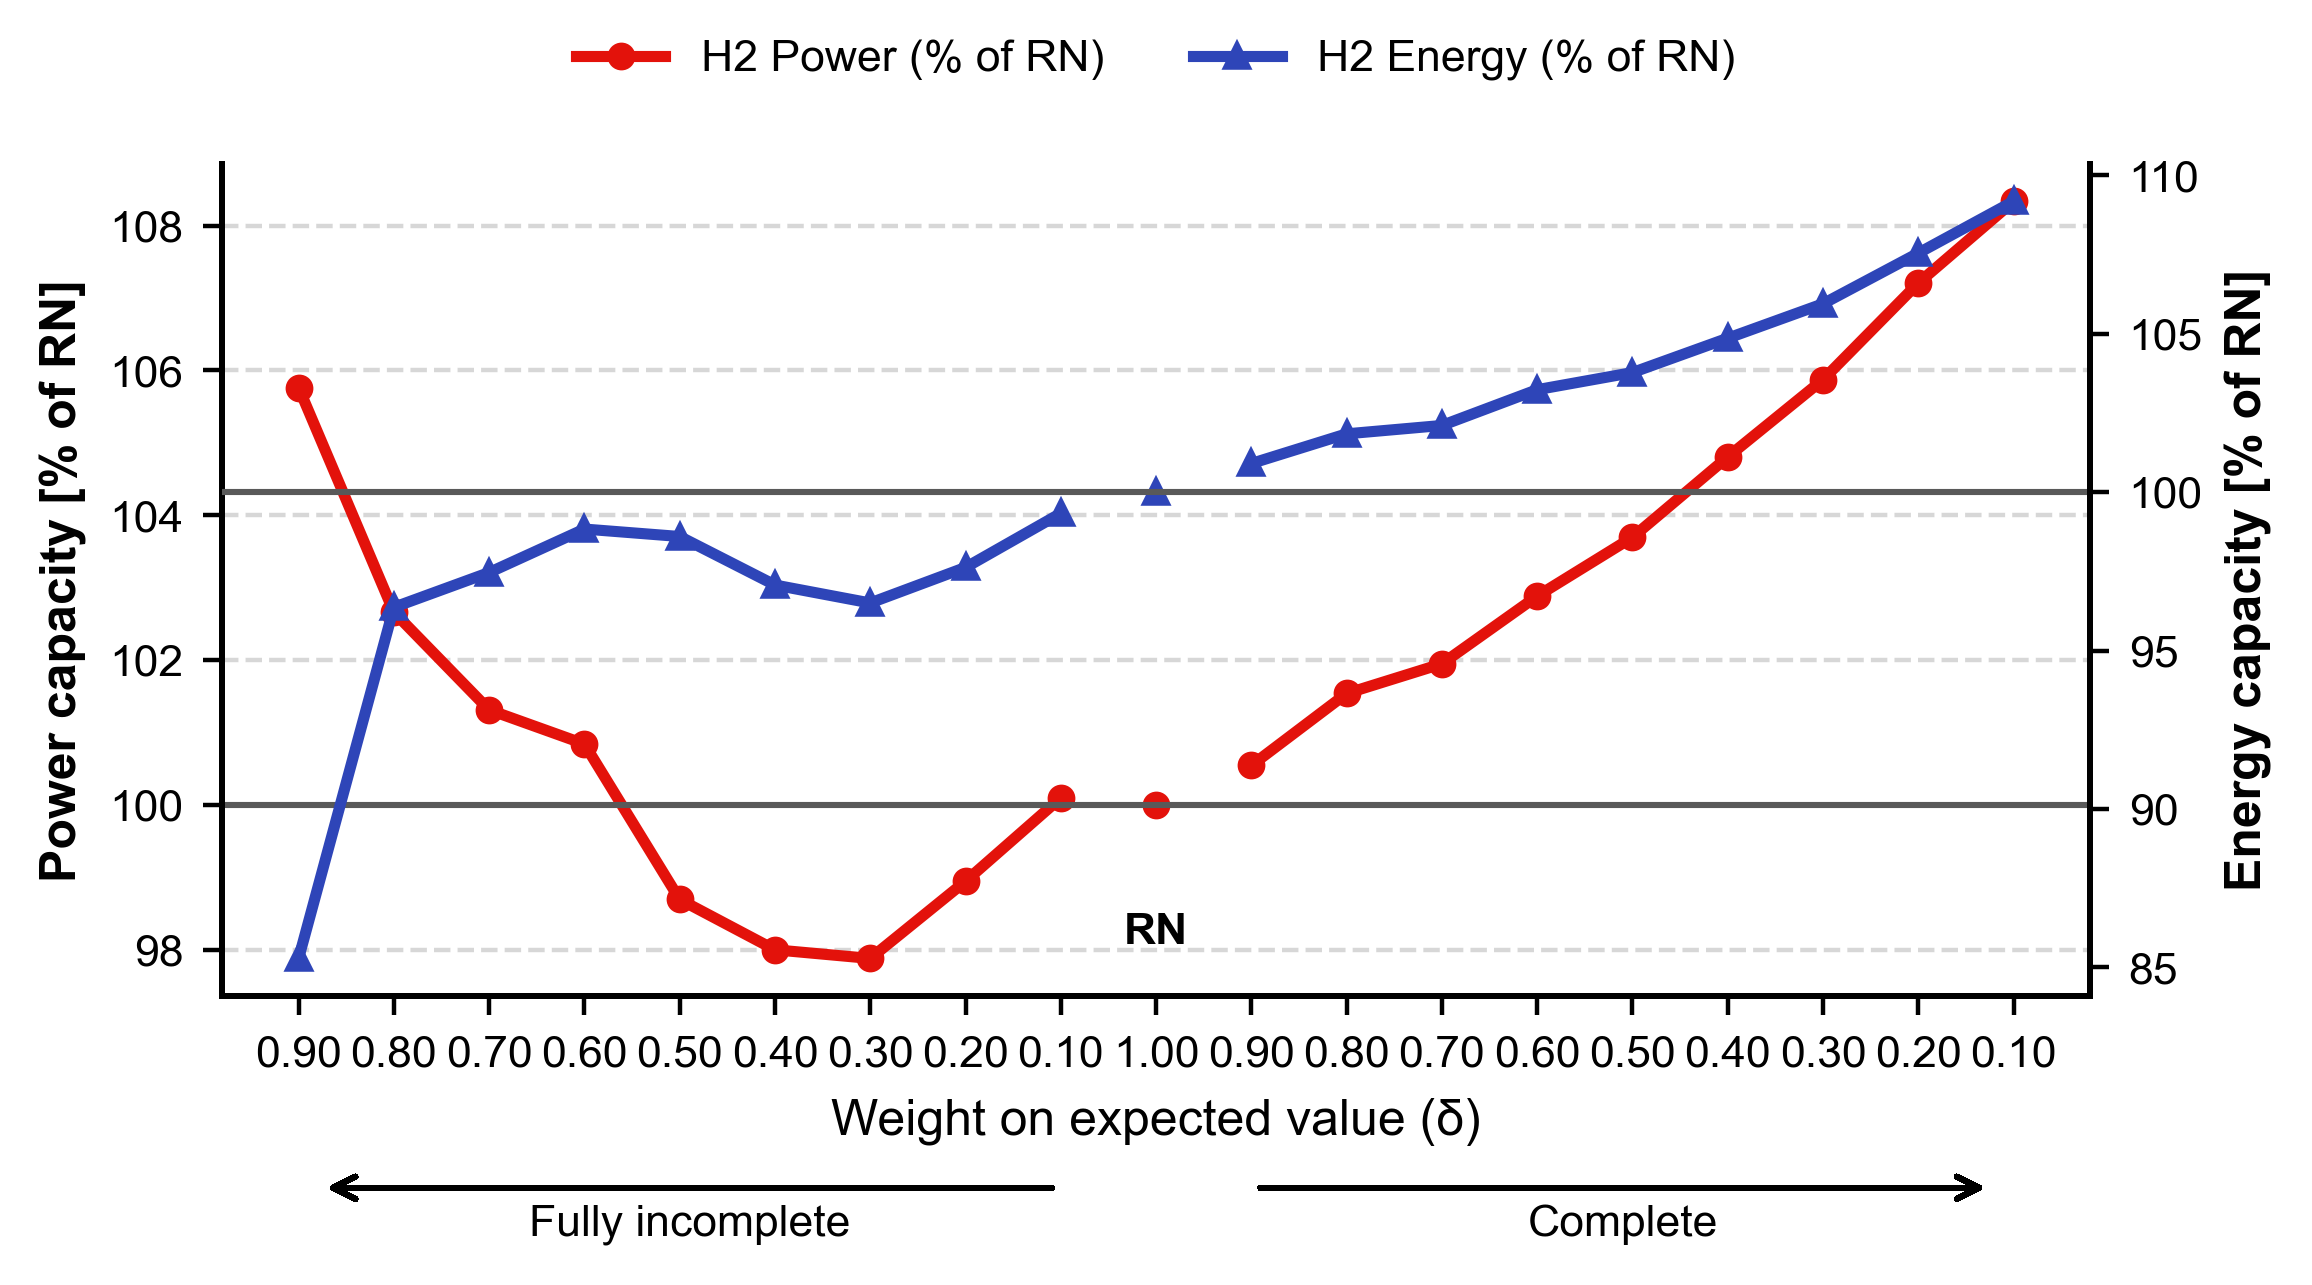

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# === Matplotlib setup (from your style) ===
rcParams['patch.edgecolor']   = 'none'
rcParams['patch.linewidth']   = 0
rcParams['patch.antialiased'] = False
rcParams['font.family']       = 'Arial'
rcParams['axes.labelweight']  = 'bold'

# === INPUT FILES (Hydrogen: complete vs incomplete) ===
#   Expect columns: ['delta', 'H2_P', 'H2_E']
complete_csv   = r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\risk_aversion_results.csv"
incomplete_csv = r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Fully_incomplete_markets_ADMM\PSCC\PSCC_higher_resolution\trycodes_3_final_higher_resolution\H2_15000_ADMM_risk_aversion_results.csv"

# === Load & prep ===
need = ['delta', 'H2_P', 'H2_E']
df_c = pd.read_csv(complete_csv)[need].rename(columns={'H2_P':'P','H2_E':'E'}).copy()
df_i = pd.read_csv(incomplete_csv)[need].rename(columns={'H2_P':'P','H2_E':'E'}).copy()

# Drop zero/strange deltas; round so 1.00 matches robustly
df_c = df_c[df_c['delta'] != 0].copy()
df_i = df_i[df_i['delta'] != 0].copy()
df_c['delta_r'] = df_c['delta'].round(2)
df_i['delta_r'] = df_i['delta'].round(2)

# Series indexed by rounded delta
cP = df_c.set_index('delta_r')['P']
cE = df_c.set_index('delta_r')['E']
iP = df_i.set_index('delta_r')['P']
iE = df_i.set_index('delta_r')['E']

# Risk-neutral baselines (each relative to its own RN)
RN = 1.00
cP_RN = float(cP.loc[RN]); cE_RN = float(cE.loc[RN])
iP_RN = float(iP.loc[RN]); iE_RN = float(iE.loc[RN])

# Percent of RN for deltas 0.90..0.10 (descending list of δ)
deltas_desc = [round(x, 2) for x in np.arange(0.90, 0.0, -0.10)]

# ----------------- KEY CHANGE: remap x so ticks decrease away from RN -----------------
# We place points at x = ±(1 - δ).
#   δ=0.90 -> x=±0.10 (near RN)
#   δ=0.10 -> x=±0.90 (far from RN)
# Right side (Complete): +x
right_d  = [d for d in deltas_desc if d in cP.index and d in cE.index]
x_right  = +(1 - np.array(right_d))            # 0.10 .. 0.90 (RN outward, δ decreases)
yP_right = 100.0 * (cP[right_d].values / cP_RN)
yE_right = 100.0 * (cE[right_d].values / cE_RN)

# Left side (Incomplete): -x
left_d   = [d for d in deltas_desc if d in iP.index and d in iE.index]
x_left   = -(1 - np.array(left_d))             # -0.10 .. -0.90 (RN outward, δ decreases)
yP_left  = 100.0 * (iP[left_d].values / iP_RN)
yE_left  = 100.0 * (iE[left_d].values / iE_RN)

# === Figure ===
fig, axP = plt.subplots(figsize=(6, 4.3), dpi=400)

# Aesthetics
for s in ['top', 'right']:
    axP.spines[s].set_visible(False)
axP.yaxis.grid(True, linestyle='--', alpha=0.5)
axP.xaxis.grid(False)
axP.set_axisbelow(True)

# Colors
col_power  = '#E3120B'  # red
col_energy = '#2E45B8'  # blue

# Plot Power (%) on primary axis
axP.plot(x_left,  yP_left,  marker='o', ms=4.0, lw=2.0, color=col_power,  label='H\u2082 Power (% of RN)')
axP.plot([0], [100], marker='o', ms=4.0, color=col_power)  # RN marker
axP.plot(x_right, yP_right, marker='o', ms=4.0, lw=2.0, color=col_power)

axP.set_ylabel('Power capacity [% of RN]', fontsize=9)
axP.tick_params(axis='y', labelsize=8)

# Secondary axis: Energy (%)
axE = axP.twinx()
for s in ['top', 'left']:
    axE.spines[s].set_visible(False)

axE.plot(x_left,  yE_left,  marker='^', ms=4.0, lw=2.0, color=col_energy, label='H\u2082 Energy (% of RN)')
axE.plot([0], [100], marker='^', ms=4.0, color=col_energy)  # RN marker
axE.plot(x_right, yE_right, marker='^', ms=4.0, lw=2.0, color=col_energy)

axE.set_ylabel('Energy capacity [% of RN]', fontsize=9)
axE.tick_params(axis='y', labelsize=8)

# ----------------- Ticks & labels with desired order -----------------
# Build ticks at ±(1-δ) for δ=0.90..0.10
left_pos_all  = -(1 - np.array(deltas_desc))   # [-0.10, -0.20, ..., -0.90]
right_pos_all = +(1 - np.array(deltas_desc))   # [ +0.10, +0.20, ..., +0.90]

# Sort for left-to-right placement
left_sort_idx  = np.argsort(left_pos_all)      # -> [-0.90 ... -0.10]
right_sort_idx = np.argsort(right_pos_all)     # -> [ +0.10 ... +0.90]

xticks = list(left_pos_all[left_sort_idx]) + [0.0] + list(right_pos_all[right_sort_idx])
xlabels_left  = [f"{d:.2f}" for d in np.array(deltas_desc)[left_sort_idx]]   # left: 0.10 .. 0.90 (left->right)
xlabels_right = [f"{d:.2f}" for d in np.array(deltas_desc)[right_sort_idx]]  # right: 0.90 .. 0.10 (left->right)
# But we want labels to read: left side 0.90 .. 0.10 | RN | right side 0.90 .. 0.10
# So reverse the left labels:
xlabels_left_display = xlabels_left[::-1]
xlabels = xlabels_left_display + ["1.00"] + xlabels_right

axP.set_xticks(xticks)
axP.set_xticklabels(xlabels, fontsize=8)
axP.set_xlabel("Weight on expected value (δ)", fontsize=9, fontweight='normal')

# RN label under center tick
axP.text(0, +0.1, "RN", transform=axP.get_xaxis_transform(),
         ha='center', va='top', fontsize=8, fontweight='bold')

# Ax limits & baseline at 100%
axP.set_xlim(-0.98, 0.98)
axP.axhline(100, color='0.35', lw=1.1)  # baseline at RN (%)
axE.axhline(100, color='0.35', lw=1.1)  # baseline at RN (%)

# Legend (top center)
lines = [axP.lines[0], axE.lines[0]]
labels = ['H2 Power (% of RN)', 'H2 Energy (% of RN)']
fig.legend(lines, labels, loc='upper center', ncol=2, fontsize=8, frameon=False)

# Arrows & labels beneath axis
arrow_y = -0.18+0.2
text_y  = -0.18+0.2
# Right: RN → complete
axP.annotate('', xy=(0.95, arrow_y-0.25), xytext=(0.55, arrow_y-0.25),
             xycoords='axes fraction', textcoords='axes fraction',
             arrowprops=dict(arrowstyle='->', lw=1.0, color='black'))
axP.text(0.75, text_y-0.27, "Complete", transform=axP.transAxes,
         ha='center', va='top', fontsize=8)
# Left: incomplete ← RN
axP.annotate('', xy=(0.05, arrow_y-0.25), xytext=(0.45, arrow_y-0.25),
             xycoords='axes fraction', textcoords='axes fraction',
             arrowprops=dict(arrowstyle='->', lw=1.0, color='black'))
axP.text(0.25, text_y-0.27, "Fully incomplete", transform=axP.transAxes,
         ha='center', va='top', fontsize=8)

# Tight layout with room for legend and bottom annotations
plt.tight_layout(rect=[0.02, 0.18, 1, 0.95])

# Show / save
# plt.savefig("H2_power_energy_RN_center_butterfly.png", dpi=600, bbox_inches='tight')
plt.show()

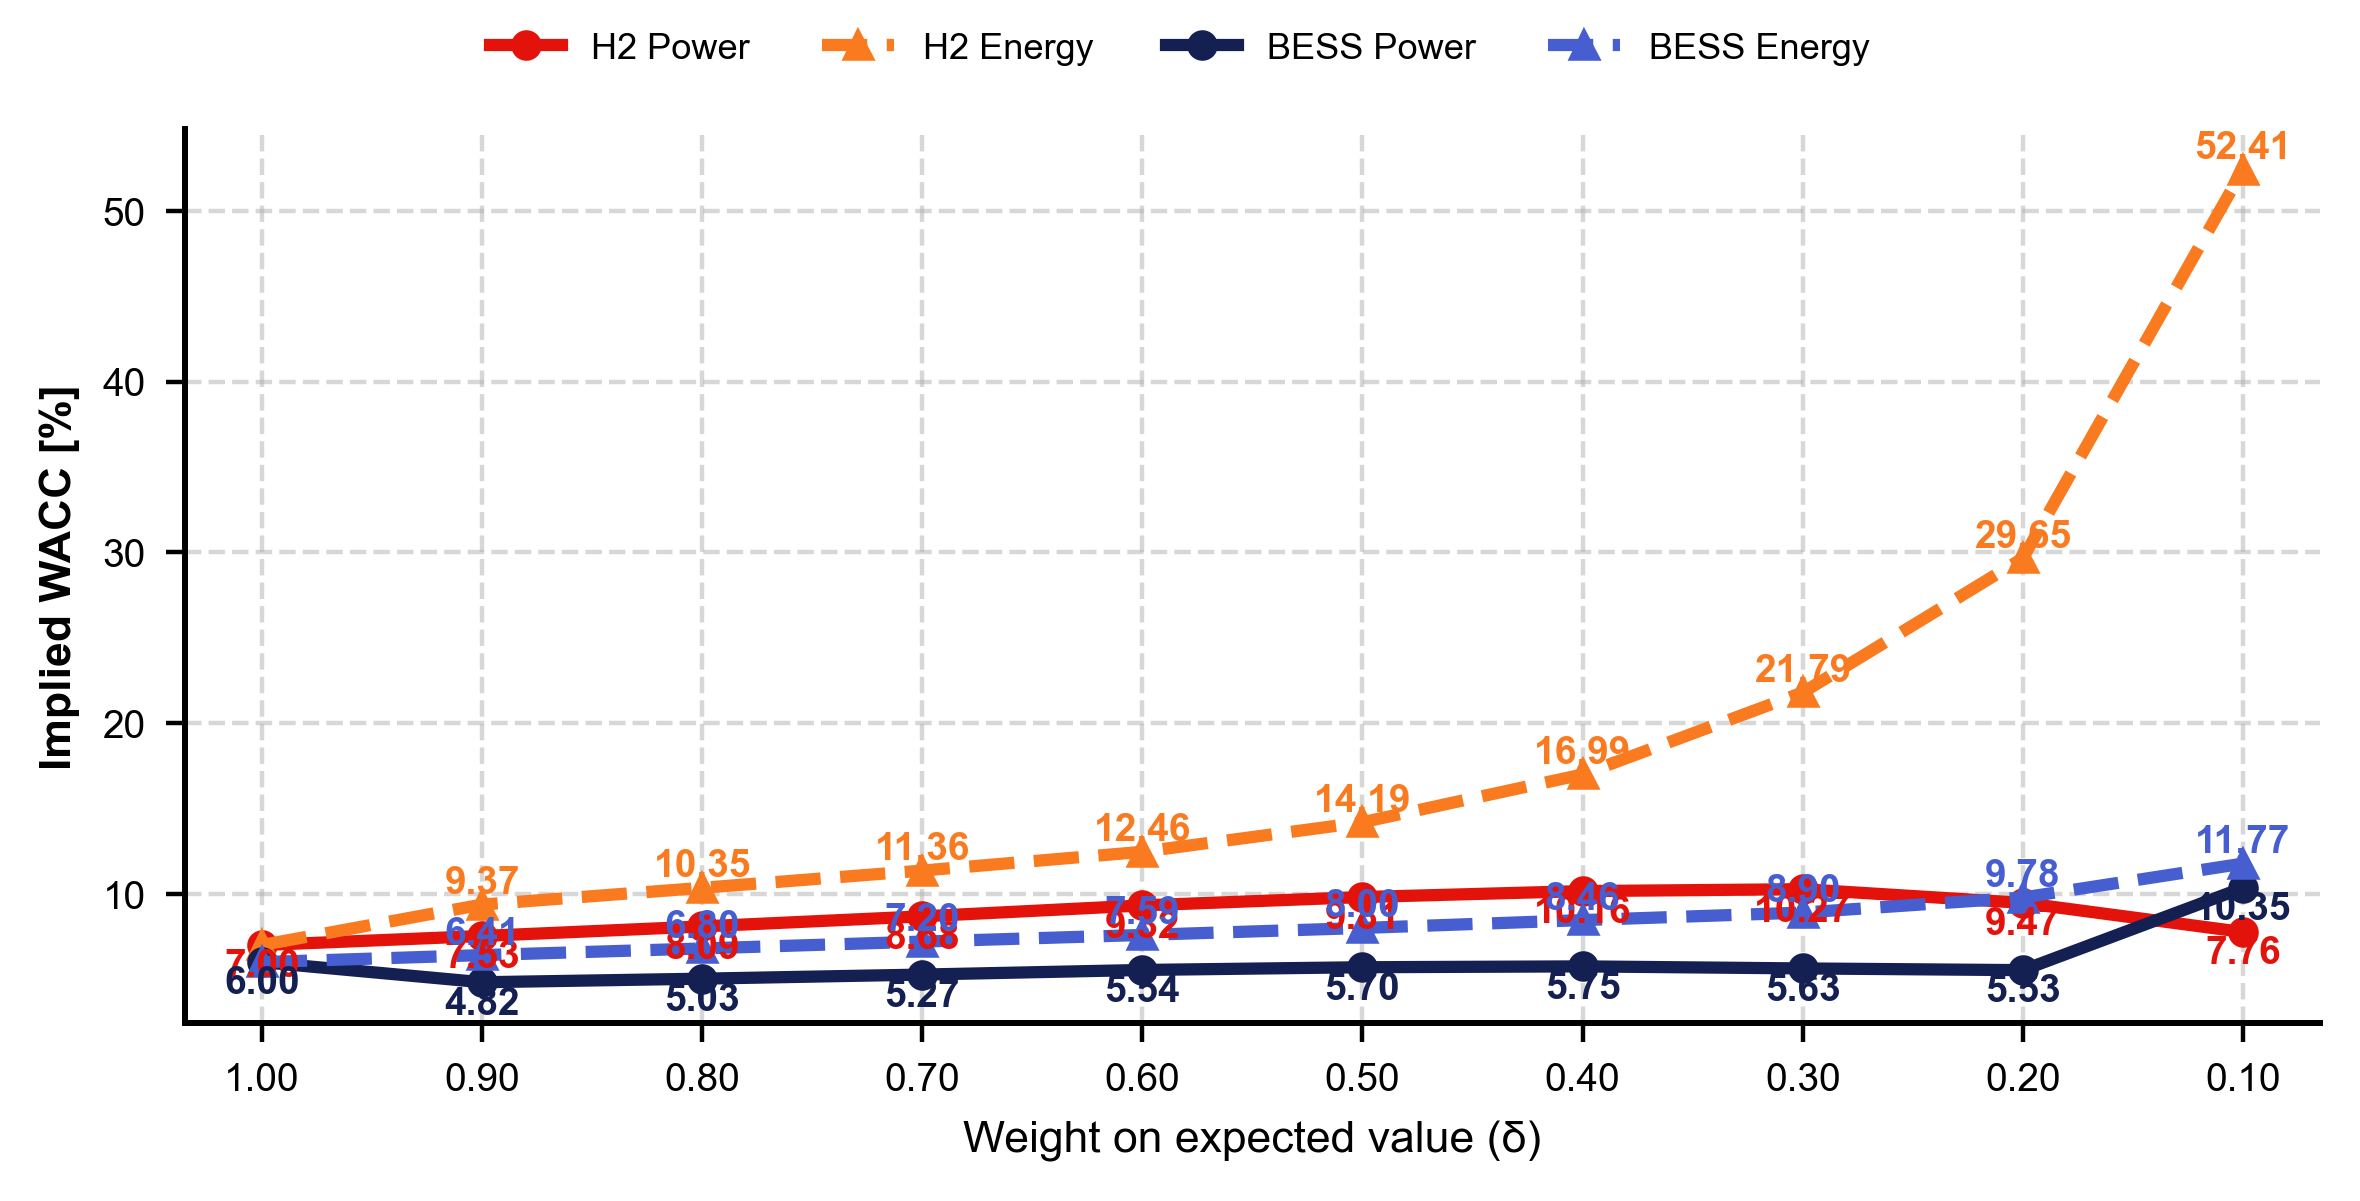

In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# === Matplotlib setup (match your style) ===
rcParams['patch.edgecolor']   = 'none'
rcParams['patch.linewidth']   = 0
rcParams['patch.antialiased'] = False
rcParams['font.family']       = 'Arial'
rcParams['axes.labelweight']  = 'bold'

AXIS_LABEL_FS = 8
TICK_FS       = 7
LEGEND_FS     = 6.5
ANNOT_FS      = 7

# ---- Data ----
# Fully Incomplete WACC (percent)
deltas = [1.00, 0.90, 0.80, 0.70, 0.60, 0.50, 0.40, 0.30, 0.20, 0.10]

wacc = {
    "H2 Power":   [7.00, 7.53, 8.09, 8.68, 9.32, 9.81, 10.16, 10.27, 9.47, 7.76],
    "H2 Energy":  [7.00, 9.37, 10.35, 11.36, 12.46, 14.19, 16.99, 21.79, 29.65, 52.41],
    "BESS Power": [6.00, 4.82, 5.03, 5.27, 5.54, 5.70, 5.75, 5.63, 5.53, 10.35],
    "BESS Energy":[6.00, 6.41, 6.80, 7.20, 7.59, 8.00, 8.46, 8.90, 9.78, 11.77],
}

# Economist-inspired palette
colors = {
    "H2 Power":   '#E3120B',   # red
    "H2 Energy":  '#F97A1F',   # orange
    "BESS Power": '#141F52',   # dark blue
    "BESS Energy":"#475ED1",   # teal
}

# Styles (solid for Power, triangle/dashed for Energy)
styles = {
    "H2 Power":   {"marker": "o", "linestyle": "-"},
    "H2 Energy":  {"marker": "^", "linestyle": "--"},
    "BESS Power": {"marker": "o", "linestyle": "-"},
    "BESS Energy":{"marker": "^", "linestyle": "--"},
}

# ---- Plot ----
fig, ax = plt.subplots(figsize=(6, 3), dpi=400)

# remove top/right spines, match grid
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# lines + point annotations
for tech, values in wacc.items():
    line = ax.plot(
        deltas, values,
        marker=styles[tech]["marker"],
        linestyle=styles[tech]["linestyle"],
        label=tech,
        linewidth=2.2, markersize=4.5,
        color=colors[tech]
    )[0]

    # annotate (skip energy at RN to avoid overlap)
    for x, y in zip(deltas, values):
        if np.isclose(x, 1.00) and ("Energy" in tech):
            continue
        offset = 0.20 if "Energy" in tech else -0.20
        va = "bottom" if "Energy" in tech else "top"
        ax.text(x, y + offset, f"{y:.2f}", ha="center", va=va,
                fontsize=ANNOT_FS, color=colors[tech], fontweight="bold")

# Axes formatting like the reference figure
ax.set_xlabel("Weight on expected value (δ)", fontsize=AXIS_LABEL_FS, fontweight='normal')
ax.set_ylabel("Implied WACC [%]", fontsize=AXIS_LABEL_FS, fontweight='bold')
ax.tick_params(axis='both', labelsize=TICK_FS)

# ticks shown as 2 decimals (descending), with margin like the reference plot
ax.set_xticks(deltas)
ax.set_xticklabels([f"{x:.2f}" for x in deltas])
ax.set_xlim(1.035, min(deltas) - 0.035)  # 1.00 on the LEFT, little padding



# Legend (top, single row, no frame) – using fig.legend for clean placement
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, fontsize=LEGEND_FS, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # headroom for legend
# plt.savefig("wacc_line_poster.png", dpi=600, bbox_inches="tight")
plt.savefig("wacc_line_poster.svg", format="svg", dpi=600, bbox_inches="tight")
plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_25368\360270917.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 1.2])


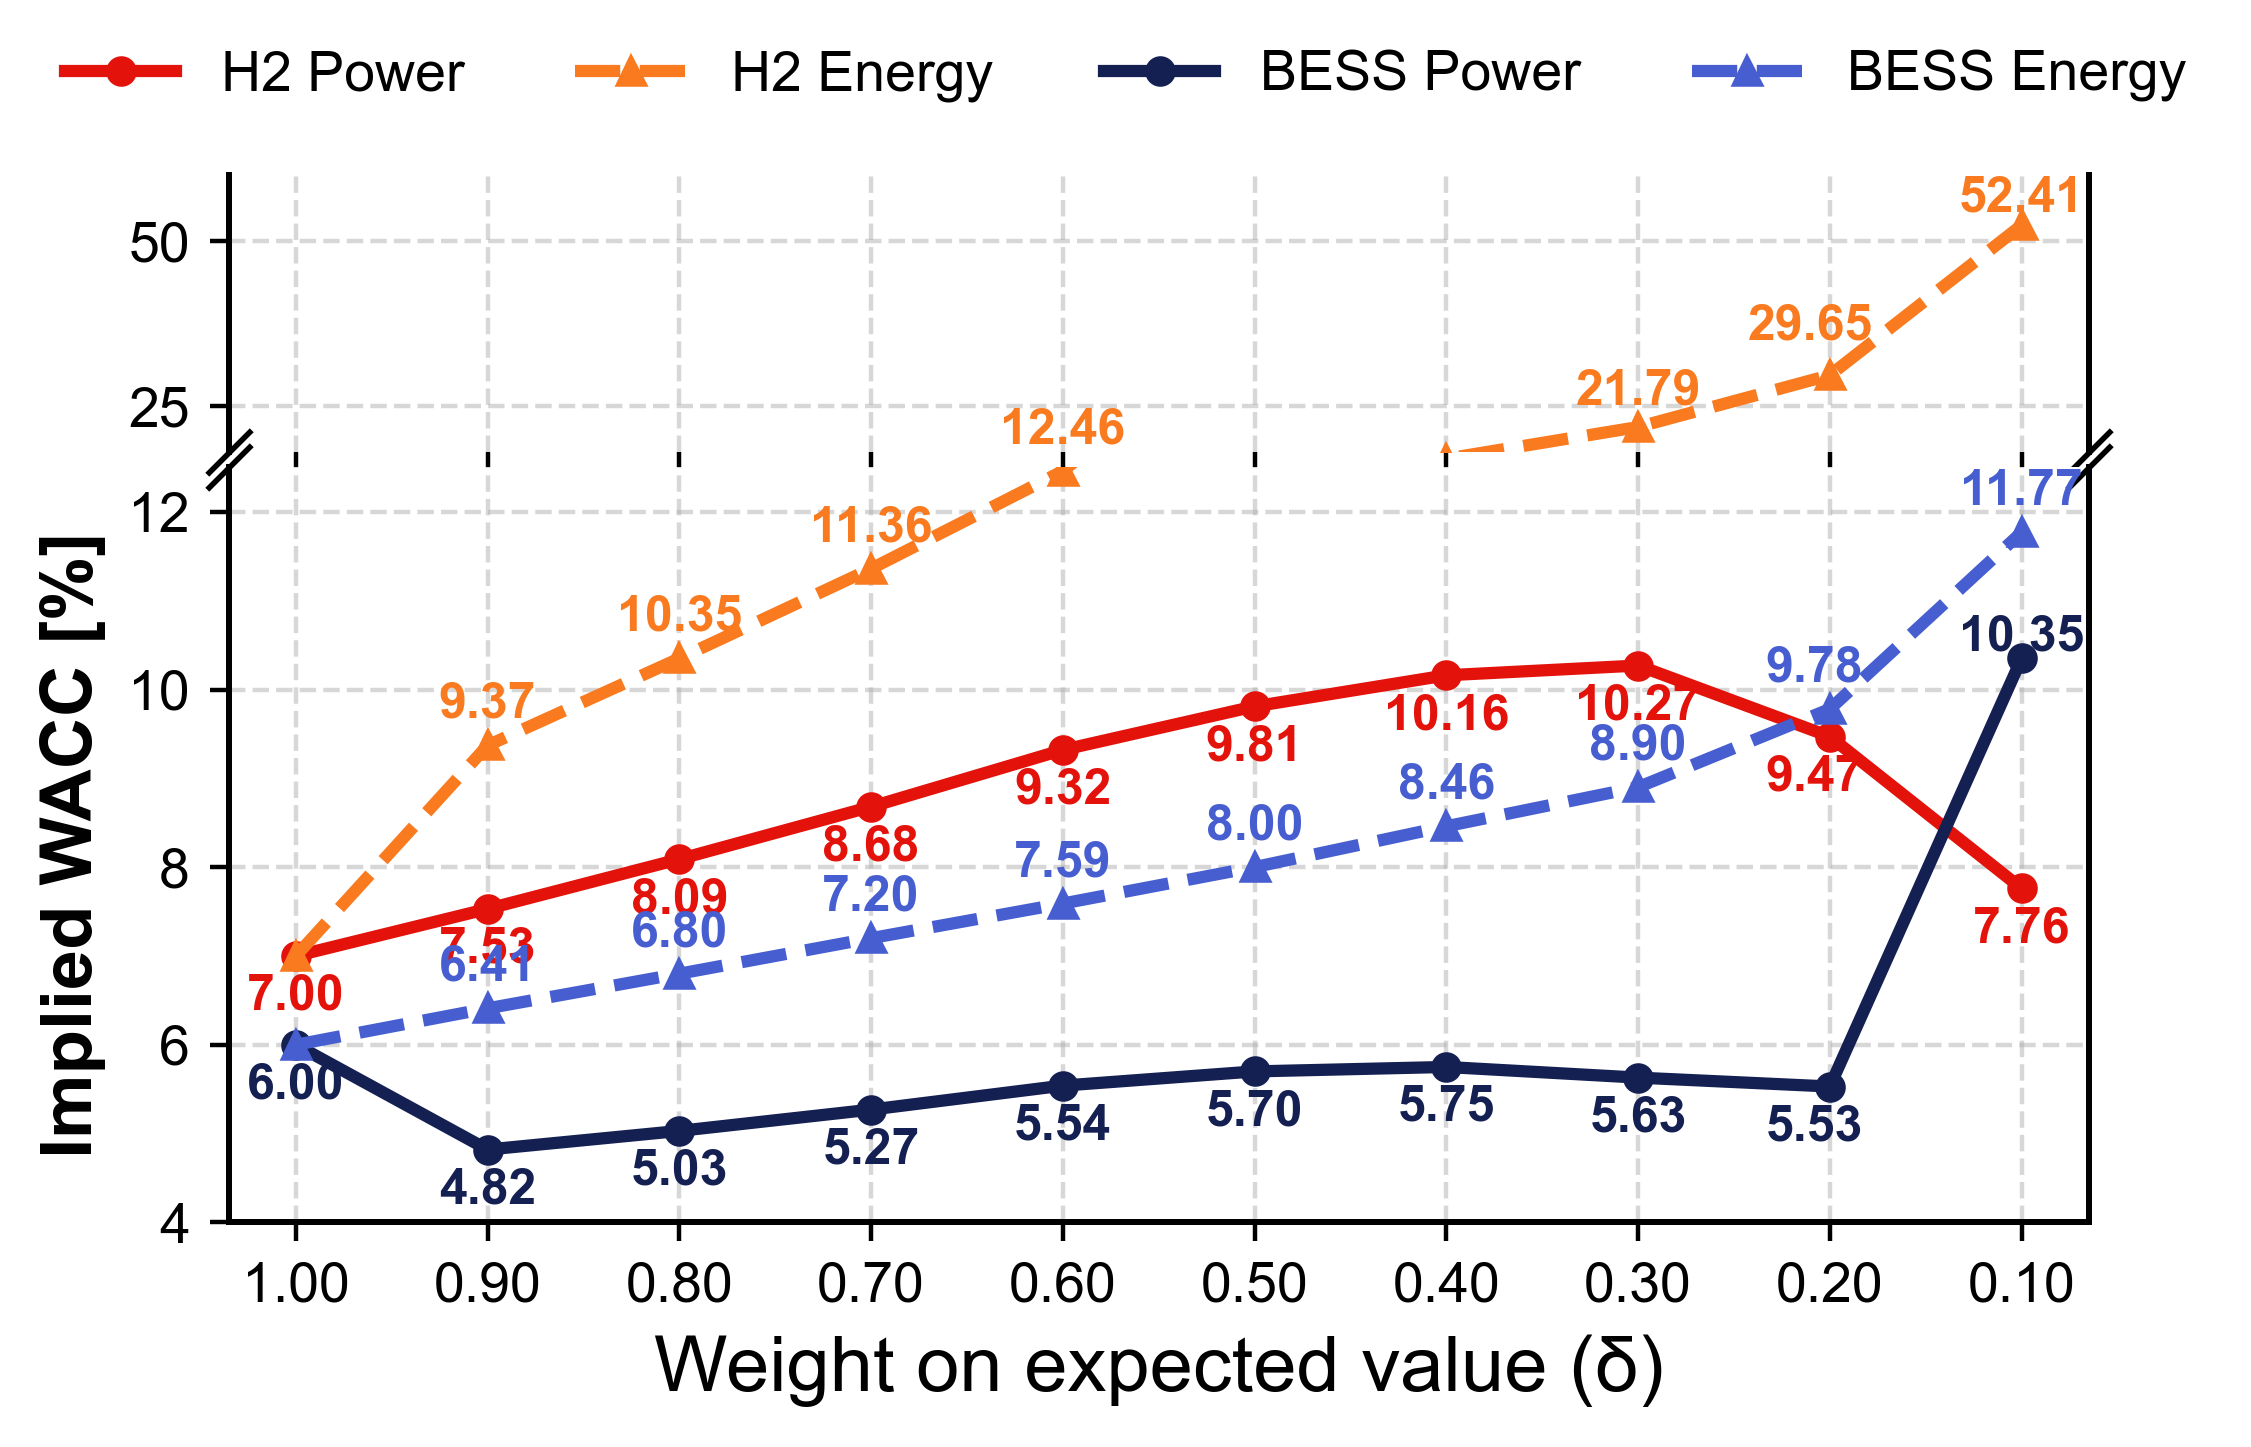

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# === Matplotlib setup (match your style) ===
rcParams['patch.edgecolor']   = 'none'
rcParams['patch.linewidth']   = 0
rcParams['patch.antialiased'] = False
rcParams['font.family']       = 'Arial'
rcParams['axes.labelweight']  = 'bold'

AXIS_LABEL_FS = 13
TICK_FS       = 10
LEGEND_FS     = 10
ANNOT_FS      = 9

# ---- Data ----
deltas = [1.00, 0.90, 0.80, 0.70, 0.60, 0.50, 0.40, 0.30, 0.20, 0.10]
wacc = {
    "H2 Power":   [7.00, 7.53, 8.09, 8.68, 9.32, 9.81, 10.16, 10.27, 9.47, 7.76],
    "H2 Energy":  [7.00, 9.37, 10.35, 11.36, 12.46, 14.19, 16.99, 21.79, 29.65, 52.41],
    "BESS Power": [6.00, 4.82, 5.03, 5.27, 5.54, 5.70, 5.75, 5.63, 5.53, 10.35],
    "BESS Energy":[6.00, 6.41, 6.80, 7.20, 7.59, 8.00, 8.46, 8.90, 9.78, 11.77],
}
colors = {
    "H2 Power":   '#E3120B',   # red
    "H2 Energy":  '#F97A1F',   # orange
    "BESS Power": '#141F52',   # navy
    "BESS Energy":"#475ED1",   # mid blue
}
styles = {
    "H2 Power":   {"marker": "o", "linestyle": "-"},
    "H2 Energy":  {"marker": "^", "linestyle": "--"},
    "BESS Power": {"marker": "o", "linestyle": "-"},
    "BESS Energy":{"marker": "^", "linestyle": "--"},
}

# ---- Broken y-axis ranges ----
LOW_MIN,  LOW_MAX  = 4.5, 12.5   # bottom panel (most series)
HIGH_MIN, HIGH_MAX = 18.0, 55.0  # top panel (H2 Energy tail)

# ---- Figure with two stacked axes (TOP = HIGH, BOTTOM = LOW) ----
fig, (ax_high, ax_low) = plt.subplots(
    2, 1, sharex=True, figsize=(6, 3.4), dpi=400,
    gridspec_kw={'height_ratios': [1.1, 3.0], 'hspace': 0.03}
)

def style_axes(ax):
    ax.spines['top'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.xaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', labelsize=TICK_FS)

style_axes(ax_high)
style_axes(ax_low)

# Hide the meeting spines to imply the break
ax_high.spines['bottom'].set_visible(False)
ax_low.spines['top'].set_visible(False)

# Plot on BOTH axes; annotate where each value falls inside that panel’s y-range
for tech, vals in wacc.items():
    # lines
    ax_high.plot(deltas, vals, marker=styles[tech]['marker'],
                 linestyle=styles[tech]['linestyle'], linewidth=2.2,
                 markersize=4.5, color=colors[tech], label=tech)
    ax_low.plot(deltas, vals,  marker=styles[tech]['marker'],
                linestyle=styles[tech]['linestyle'], linewidth=2.2,
                markersize=4.5, color=colors[tech], label='_nolegend_')

    # annotations
    for x, y in zip(deltas, vals):
        # top panel (high range; mainly H2 Energy)
        if HIGH_MIN <= y <= HIGH_MAX and ("H2 Energy" in tech):
            if x==0.2 :
                ax_high.text(x+0.01, y + 4, f"{y:.2f}", ha='center', va='bottom',
                         fontsize=ANNOT_FS, color=colors[tech], fontweight='bold')
            elif x==0.3 :
                ax_high.text(x, y + 2, f"{y:.2f}", ha='center', va='bottom',
                         fontsize=ANNOT_FS, color=colors[tech], fontweight='bold')
            else:
                ax_high.text(x, y + 0.6, f"{y:.2f}", ha='center', va='bottom',
                         fontsize=ANNOT_FS, color=colors[tech], fontweight='bold')
        # bottom panel (low range; all others)
        if LOW_MIN <= y <= LOW_MAX and not (np.isclose(x, 1.00) and ("Energy" in tech)):
            offset = 0.20 if "Energy" in tech else -0.20
            va = "bottom" if "Energy" in tech else "top"
            if x==0.2 :
                ax_low.text(x+0.008, y + offset, f"{y:.2f}", ha='center', va=va,
                        fontsize=ANNOT_FS, color=colors[tech], fontweight='bold')
            elif (x==0.1) and ("BESS Power" in tech):
                ax_low.text(x, y+0.50, f"{y:.2f}", ha='center', va=va,
                        fontsize=ANNOT_FS, color=colors[tech], fontweight='bold')
            else:
                ax_low.text(x, y + offset, f"{y:.2f}", ha='center', va=va,
                        fontsize=ANNOT_FS, color=colors[tech], fontweight='bold')

# Set limits
ax_high.set_ylim(HIGH_MIN, HIGH_MAX)
ax_low.set_ylim(LOW_MIN, LOW_MAX)

# Diagonal break marks (bottom of TOP axis, top of BOTTOM axis)
kwargs = dict(marker=[(-1, -1), (1, 1)], markersize=8, linestyle='none',
              color='k', mec='k', mew=1, clip_on=False)
ax_high.plot([0, 1], [0, 0], transform=ax_high.transAxes, **kwargs)
ax_low.plot([0, 1], [1, 1], transform=ax_low.transAxes, **kwargs)

# Labels (attach to lower axis)
ax_low.set_xlabel("Weight on expected value (δ)", fontsize=14, fontweight='normal')
ax_low.set_ylabel("Implied WACC [%]", fontsize=13, fontweight='bold')

# X ticks: 1.00 on the LEFT
ax_low.set_xticks(deltas)
ax_low.set_xticklabels([f"{x:.2f}" for x in deltas])
ax_low.set_xlim(1.035, min(deltas) - 0.035)
ax_low.set_ylim(4, None)
ax_high.set_ylim(None, 60)

# Legend (top center, single row)
handles, labels = ax_high.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, fontsize=LEGEND_FS, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 1.2])
# plt.savefig("wacc_broken_axis_fixed.png", dpi=600, bbox_inches="tight")
plt.savefig("wacc_broken_axis_fixed.png", format="png", dpi=600, bbox_inches="tight")
plt.show()


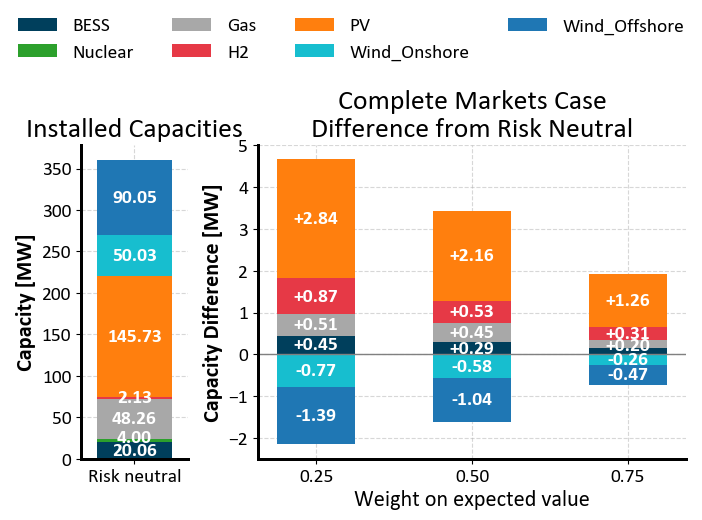

In [129]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
from matplotlib.patches import Rectangle

# === Global figure & font setup (poster-friendly) ===
rcParams['figure.dpi'] = 100           # canvas DPI (export dpi is set in savefig)
rcParams['savefig.dpi'] = 300          # export DPI (you can bump to 400)
rcParams['pdf.fonttype'] = 42          # embed TrueType in PDFs
rcParams['ps.fonttype']  = 42

# Use your poster font (with graceful fallback)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Imperial Sans', 'Calibri', 'DejaVu Sans']

# Sizes tuned for A1, 3-column, body=26 pt, caption=10 pt
TITLE_FS = 20
AXIS_LABEL_FS = 16
TICK_FS = 14
LEGEND_FS = 14
ANNOT_FS = 14

# Line/patch rendering
rcParams['patch.edgecolor'] = 'none'
rcParams['patch.linewidth'] = 0
rcParams['patch.antialiased'] = False

# === Load data ===
df_raw = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Complete_Markets\Results\risk_aversion_results.csv")
df = df_raw[df_raw["delta"] != 0]

# === Filter relevant columns ===
capacity_cols = ['PV', 'Gas', 'Wind_Onshore', 'Wind_Offshore', 'Nuclear', 'BESS_P', 'H2_P']
df = df[['delta'] + capacity_cols]

# === Split data ===
df_rn = df[df['delta'] == 1].iloc[0]
df_others = df[df['delta'] != 1].sort_values('delta')

# === Define techs, labels, and colors ===
techs  = ['BESS_P', 'Nuclear', 'Gas', 'H2_P', 'PV', 'Wind_Onshore', 'Wind_Offshore']
labels = ['BESS',   'Nuclear',  'Gas', 'H2',   'PV', 'Wind_Onshore', 'Wind_Offshore']
colors = {
    'BESS_P': '#003f5c',
    'Nuclear': '#2ca02c',
    'Gas': '#a8a8a8',
    'H2_P': '#e63946',
    'PV': '#ff7f0e',
    'Wind_Onshore': '#17becf',
    'Wind_Offshore': '#1f77b4'
}

# === Plot setup ===
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(7, 5),  # ~18×12.5 cm (single column)
    gridspec_kw={'width_ratios': [1, 4]}
)

for ax in (ax1, ax2):
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, linewidth=0.8)
    ax.xaxis.grid(True, linestyle='--', alpha=0.5, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=TICK_FS)

# === Left: Risk Neutral ===
bar_width = 0.35
bottom = 0
for tech in techs:
    value = df_rn[tech]
    ax1.bar(0.25, value, width=bar_width, bottom=bottom, color=colors[tech])
    if value > 4.5:
        ax1.text(0.25, bottom + value / 2, f'{value:.2f}',
                 ha='center', va='center', color='white',
                 fontsize=ANNOT_FS, fontweight='bold')
    elif value < 3.75:
        ax1.text(0.25, bottom + value / 2, f'{value:.2f}',
                 ha='center', va='center', color='white',
                 fontsize=ANNOT_FS, fontweight='bold')
    elif 3.75<value < 4.25:
        ax1.text(0.25, bottom + value / 0.75, f'{value:.2f}',
                 ha='center', va='center', color='white',
                 fontsize=ANNOT_FS, fontweight='bold')
    bottom += value

ax1.set_xticks([0.25], labels=['Risk neutral'], fontsize=TICK_FS)
ax1.set_xlim(0, 0.5)
ax1.set_ylabel("Capacity [MW]", fontsize=AXIS_LABEL_FS, fontweight='bold')
ax1.set_title("Installed Capacities", fontsize=TITLE_FS, fontweight='normal')

# === Right: Differences ===
deltas = df_others['delta'].unique()
x = np.arange(len(deltas))
width = 0.5
bottom_pos = np.zeros_like(x, dtype=float)
bottom_neg = np.zeros_like(x, dtype=float)

for tech in techs:
    diffs = df_others[tech].values - df_rn[tech]
    for i, diff in enumerate(diffs):
        if diff >= 0.01:
            ax2.bar(x[i], diff, width=width, bottom=bottom_pos[i], color=colors[tech])
            ytxt = bottom_pos[i] + (diff/3 if 0.04 < abs(diff) < 0.21 else diff/2)
            if diff >= 0.20:
                ax2.text(x[i], ytxt, f'+{diff:.2f}',ha='center', va='center', fontsize=ANNOT_FS,color='white', fontweight='bold')
            bottom_pos[i] += diff
        else:
            ax2.bar(x[i], diff, width=width, bottom=bottom_neg[i], color=colors[tech])
            if abs(diff) > 0.1:
                ax2.text(x[i], bottom_neg[i] + diff/2, f'{diff:.2f}',
                         ha='center', va='center', fontsize=ANNOT_FS,
                         color='white', fontweight='bold')
            bottom_neg[i] += diff

ax2.set_xticks(x, labels=[f"{d:.2f}" for d in deltas], fontsize=TICK_FS)
ax2.set_xlabel("Weight on expected value", fontsize=AXIS_LABEL_FS, fontweight='normal')
ax2.set_ylabel("Capacity Difference [MW]", fontsize=AXIS_LABEL_FS, fontweight='bold')
ax2.set_title("Complete Markets Case\nDifference from Risk Neutral",
              fontsize=TITLE_FS, fontweight='normal')
ax2.axhline(0, color='gray', linewidth=1)

# === Legend (top, full width) ===
handles = [Rectangle((0, 0), 1, 1, facecolor=colors[t], edgecolor='black') for t in techs]
fig.legend(handles, labels,
           loc='upper center',
           ncol=4,              # 4 on first row, 3 on second
           fontsize=LEGEND_FS,
           frameon=False,
           bbox_to_anchor=(0.5, 1.05))  # push legend slightly above


plt.tight_layout(rect=[0, 0, 1, 0.90])  # leave space for top legend
# plt.show()

fig.savefig("complete_poster.png", dpi=400, bbox_inches='tight')  # 300–400 dpi for print


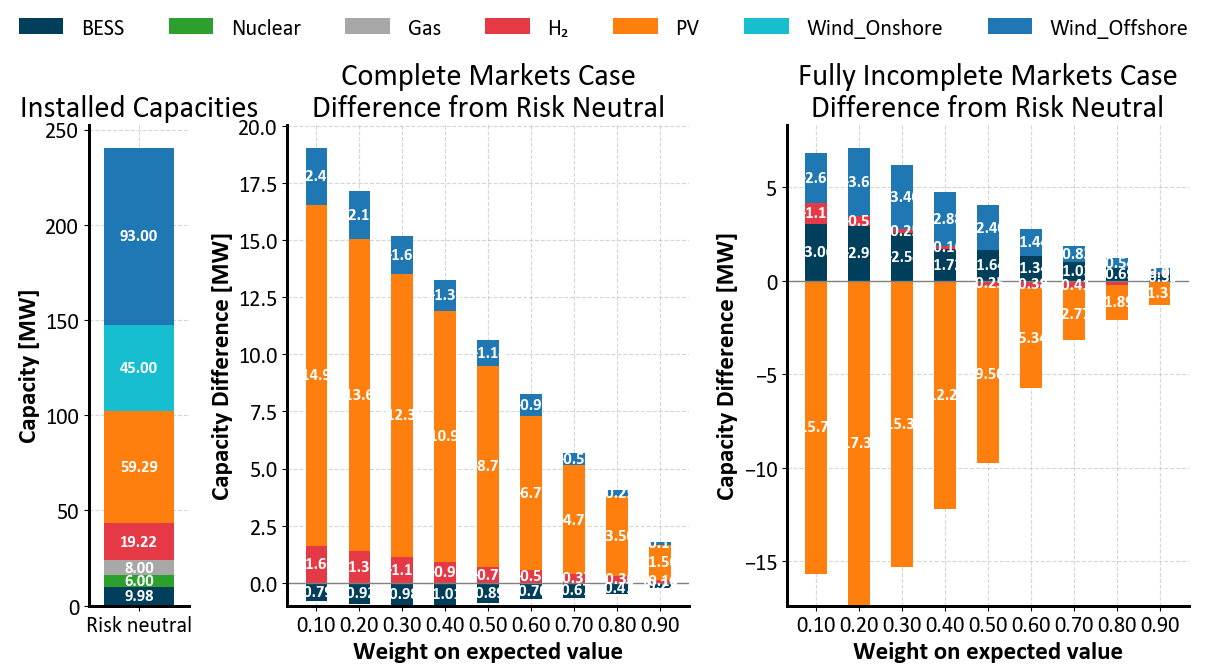

In [131]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
from matplotlib.patches import Rectangle

# === Global figure & font setup (poster-friendly) ===
rcParams['figure.dpi'] = 100           # canvas DPI (export dpi is set in savefig)
rcParams['savefig.dpi'] = 300          # export DPI (you can bump to 400)
rcParams['pdf.fonttype'] = 42          # embed TrueType in PDFs
rcParams['ps.fonttype']  = 42

# Use your poster font (with graceful fallback)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Imperial Sans', 'Calibri', 'DejaVu Sans']

# Sizes tuned for A1, 3-column, body=26 pt, caption=10 pt
TITLE_FS = 22
AXIS_LABEL_FS = 18
TICK_FS = 16
LEGEND_FS = 16
ANNOT_FS = 12

# Line/patch rendering
rcParams['patch.edgecolor'] = 'none'
rcParams['patch.linewidth'] = 0
rcParams['patch.antialiased'] = False

# === Load data ===
#dfC_raw = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\risk_aversion_results.csv")

#dfI_raw = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Fully_incomplete_markets_ADMM\RESULTS_FINAL\H2_15000_ADMM_risk_aversion_results.csv")
#dfI_raw = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Fully_incomplete_markets_ADMM\Results_final_lower_tolerance\H2_15000_ADMM_risk_aversion_results.csv")

dfC_raw = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\risk_aversion_results.csv")
dfI_raw = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Fully_incomplete_markets_ADMM\PSCC\PSCC_higher_resolution\trycodes_3_final_higher_resolution\H2_15000_ADMM_risk_aversion_results.csv")


# Keep rows with delta != 0 (as in your code)
dfC = dfC_raw[dfC_raw["delta"] != 0].copy()
dfI = dfI_raw[dfI_raw["delta"] != 0].copy()


# === Filter relevant columns ===
capacity_cols = ['PV', 'Gas', 'Wind_Onshore', 'Wind_Offshore', 'Nuclear', 'BESS_P', 'H2_P']
dfC = dfC[['delta'] + capacity_cols]
dfI = dfI[['delta'] + capacity_cols]

# === Split data ===
df_rn = dfC[dfC['delta'] == 1].iloc[0]

# Sorted deltas for plotting diffs
dfC_others = dfC[dfC['delta'] != 1].sort_values('delta')
dfI_others = dfI[dfI['delta'] != 1].sort_values('delta')

# === Define techs, labels, and colors ===
techs  = ['BESS_P', 'Nuclear', 'Gas', 'H2_P', 'PV', 'Wind_Onshore', 'Wind_Offshore']
labels = ['BESS',   'Nuclear',  'Gas', 'H₂',   'PV', 'Wind_Onshore', 'Wind_Offshore']
colors = {
    'BESS_P': '#003f5c',
    'Nuclear': '#2ca02c',
    'Gas': '#a8a8a8',
    'H2_P': '#e63946',
    'PV': '#ff7f0e',
    'Wind_Onshore': '#17becf',
    'Wind_Offshore': '#1f77b4'
}

# === Helper: stacked-diff plot on an axis ===
def plot_diffs(ax, df_other, title):
    deltas = df_other['delta'].unique()
    x = np.arange(len(deltas))
    width = 0.5
    bottom_pos = np.zeros_like(x, dtype=float)
    bottom_neg = np.zeros_like(x, dtype=float)

    for tech in techs:
        diffs = df_other[tech].values - df_rn[tech]
        for i, diff in enumerate(diffs):
            if diff >= 0.01:
                ax.bar(x[i], diff, width=width, bottom=bottom_pos[i], color=colors[tech])
                ytxt = bottom_pos[i] + (diff/2 if 0.04 < abs(diff) < 0.21 else diff/2)
                if diff >= 0.01:
                    ax.text(x[i], ytxt, f'+{diff:.2f}',
                            ha='center', va='center', fontsize=ANNOT_FS, color='white', fontweight='bold')
                bottom_pos[i] += diff
            else:
                ax.bar(x[i], diff, width=width, bottom=bottom_neg[i], color=colors[tech])
                if abs(diff) > 0.21:
                    ax.text(x[i], bottom_neg[i] + diff/2, f'{diff:.2f}',
                            ha='center', va='center', fontsize=ANNOT_FS, color='white', fontweight='bold')
                elif 0.16 < abs(diff) < 0.20:
                    ax.text(x[i], bottom_neg[i] + diff/3, f'{diff:.2f}',
                            ha='center', va='center', fontsize=ANNOT_FS, color='white', fontweight='bold')
                elif 0.09 < abs(diff) < 0.15:
                    ax.text(x[i], bottom_neg[i] + diff/1, f'{diff:.2f}',
                            ha='center', va='center', fontsize=ANNOT_FS, color='white', fontweight='bold')
                bottom_neg[i] += diff

    ax.set_xticks(x, labels=[f"{d:.2f}" for d in deltas], fontsize=TICK_FS)
    ax.set_xlabel("Weight on expected value", fontsize=AXIS_LABEL_FS)
    ax.set_ylabel("Capacity Difference [MW]", fontsize=AXIS_LABEL_FS, fontweight='bold')
    ax.set_title(title, fontsize=TITLE_FS, fontweight='normal')
    ax.axhline(0, color='gray', linewidth=1)

# === Figure with 3 subplots ===
fig, (ax1, ax2, ax3) = plt.subplots(
    1, 3, figsize=(12, 7),                 # single-column width; a bit taller to prevent overlap
    gridspec_kw={'width_ratios': [1, 4, 4]}  # RN small, two diff panels wider
)

for ax in (ax1, ax2, ax3):
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, linewidth=0.8)
    ax.xaxis.grid(True, linestyle='--', alpha=0.5, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=TICK_FS)

# === Left: Risk neutral stacked capacities ===
bar_width = 0.35
bottom = 0
for tech in techs:
    value = df_rn[tech]
    ax1.bar(0.25, value, width=bar_width, bottom=bottom, color=colors[tech])
    # annotate inside bars
    if value > 4.5:
        ax1.text(0.25, bottom + value/2, f'{value:.2f}', ha='center', va='center',
                 color='white', fontsize=ANNOT_FS, fontweight='bold')
    elif value < 3.75:
        ax1.text(0.25, bottom + value/2, f'{value:.2f}', ha='center', va='center',
                 color='white', fontsize=ANNOT_FS, fontweight='bold')
    elif 3.75 < value < 4.25:
        ax1.text(0.25, bottom + value/0.75, f'{value:.2f}', ha='center', va='center',
                 color='white', fontsize=ANNOT_FS, fontweight='bold')
    bottom += value

ax1.set_xticks([0.25], labels=['Risk neutral'], fontsize=TICK_FS)
ax1.set_xlim(0, 0.5)
ax1.set_ylabel("Capacity [MW]", fontsize=AXIS_LABEL_FS, fontweight='bold')
ax1.set_title("Installed Capacities", fontsize=TITLE_FS, fontweight='normal')

# === Middle: Complete markets – diffs ===
plot_diffs(ax2, dfC_others, "Complete Markets Case\nDifference from Risk Neutral")

# === Right: Fully incomplete markets – diffs ===
plot_diffs(ax3, dfI_others, "Fully Incomplete Markets Case\nDifference from Risk Neutral")

# === Legend (top, full width, 2 lines) ===
handles = [Rectangle((0, 0), 1, 1, facecolor=colors[t], edgecolor='black') for t in techs]
fig.legend(handles, labels,
           loc='upper center',
           ncol=7,
           fontsize=LEGEND_FS,
           frameon=False,
           bbox_to_anchor=(0.5, 0.97))

plt.tight_layout(rect=[0, 0, 1, 0.90])
#fig.savefig("complete_vs_incomplete_poster.png", dpi=400, bbox_inches='tight')
plt.savefig("complete_vs_incomplete_poster.svg", format="svg", dpi=600, bbox_inches="tight")

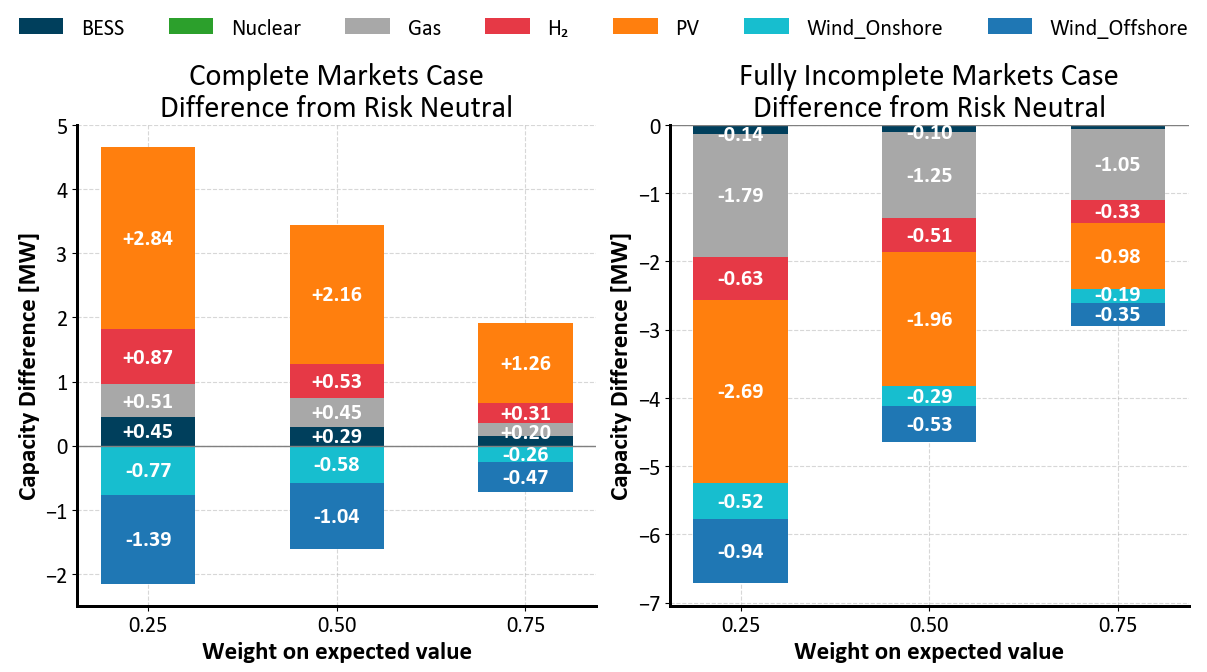

In [8]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
from matplotlib.patches import Rectangle

# === Global figure & font setup (poster-friendly) ===
rcParams['figure.dpi'] = 100           # canvas DPI (export dpi is set in savefig)
rcParams['savefig.dpi'] = 300          # export DPI (you can bump to 400)
rcParams['pdf.fonttype'] = 42          # embed TrueType in PDFs
rcParams['ps.fonttype']  = 42

# Use your poster font (with graceful fallback)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Imperial Sans', 'Calibri', 'DejaVu Sans']

# Sizes tuned for A1, 3-column, body=26 pt, caption=10 pt
TITLE_FS = 22
AXIS_LABEL_FS = 18
TICK_FS = 16
LEGEND_FS = 16
ANNOT_FS = 16

# Line/patch rendering
rcParams['patch.edgecolor'] = 'none'
rcParams['patch.linewidth'] = 0
rcParams['patch.antialiased'] = False

# === Load data ===
dfC_raw = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Complete_Markets\Results\risk_aversion_results.csv")

dfI_raw = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Fully_Incomplete\Results\H2_15000_ADMM_risk_aversion_results.csv")

# Keep rows with delta != 0 (as in your code)
dfC = dfC_raw[dfC_raw["delta"] != 0].copy()
dfI = dfI_raw[dfI_raw["delta"] != 0].copy()


# === Filter relevant columns ===
capacity_cols = ['PV', 'Gas', 'Wind_Onshore', 'Wind_Offshore', 'Nuclear', 'BESS_P', 'H2_P']
dfC = dfC[['delta'] + capacity_cols]
dfI = dfI[['delta'] + capacity_cols]

# === Split data ===
df_rn = dfC[dfC['delta'] == 1].iloc[0]

# Sorted deltas for plotting diffs
dfC_others = dfC[dfC['delta'] != 1].sort_values('delta')
dfI_others = dfI[dfI['delta'] != 1].sort_values('delta')

# === Define techs, labels, and colors ===
techs  = ['BESS_P', 'Nuclear', 'Gas', 'H2_P', 'PV', 'Wind_Onshore', 'Wind_Offshore']
labels = ['BESS',   'Nuclear',  'Gas', 'H₂',   'PV', 'Wind_Onshore', 'Wind_Offshore']
colors = {
    'BESS_P': '#003f5c',
    'Nuclear': '#2ca02c',
    'Gas': '#a8a8a8',
    'H2_P': '#e63946',
    'PV': '#ff7f0e',
    'Wind_Onshore': '#17becf',
    'Wind_Offshore': '#1f77b4'
}

# === Helper: stacked-diff plot on an axis ===
def plot_diffs(ax, df_other, title):
    deltas = df_other['delta'].unique()
    x = np.arange(len(deltas))
    width = 0.5
    bottom_pos = np.zeros_like(x, dtype=float)
    bottom_neg = np.zeros_like(x, dtype=float)

    for tech in techs:
        diffs = df_other[tech].values - df_rn[tech]
        for i, diff in enumerate(diffs):
            if diff >= 0.01:
                ax.bar(x[i], diff, width=width, bottom=bottom_pos[i], color=colors[tech])
                ytxt = bottom_pos[i] + (diff/3 if 0.04 < abs(diff) < 0.21 else diff/2)
                if diff >= 0.20:
                    ax.text(x[i], ytxt, f'+{diff:.2f}',
                            ha='center', va='center', fontsize=ANNOT_FS, color='white', fontweight='bold')
                bottom_pos[i] += diff
            else:
                ax.bar(x[i], diff, width=width, bottom=bottom_neg[i], color=colors[tech])
                if abs(diff) > 0.21:
                    ax.text(x[i], bottom_neg[i] + diff/2, f'{diff:.2f}',
                            ha='center', va='center', fontsize=ANNOT_FS, color='white', fontweight='bold')
                elif 0.16 < abs(diff) < 0.20:
                    ax.text(x[i], bottom_neg[i] + diff/3, f'{diff:.2f}',
                            ha='center', va='center', fontsize=ANNOT_FS, color='white', fontweight='bold')
                elif 0.09 < abs(diff) < 0.15:
                    ax.text(x[i], bottom_neg[i] + diff/1, f'{diff:.2f}',
                            ha='center', va='center', fontsize=ANNOT_FS, color='white', fontweight='bold')
                bottom_neg[i] += diff

    ax.set_xticks(x, labels=[f"{d:.2f}" for d in deltas], fontsize=TICK_FS)
    ax.set_xlabel("Weight on expected value", fontsize=AXIS_LABEL_FS)
    ax.set_ylabel("Capacity Difference [MW]", fontsize=AXIS_LABEL_FS, fontweight='bold')
    ax.set_title(title, fontsize=TITLE_FS, fontweight='normal')
    ax.axhline(0, color='gray', linewidth=1)

# === Figure with 3 subplots ===
fig, ( ax2, ax3) = plt.subplots(
    1, 2, figsize=(12, 7),                 # single-column width; a bit taller to prevent overlap
    gridspec_kw={'width_ratios': [4, 4]}  # RN small, two diff panels wider
)

for ax in (ax2, ax3):
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, linewidth=0.8)
    ax.xaxis.grid(True, linestyle='--', alpha=0.5, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=TICK_FS)


# === Middle: Complete markets – diffs ===
plot_diffs(ax2, dfC_others, "Complete Markets Case\nDifference from Risk Neutral")

# === Right: Fully incomplete markets – diffs ===
plot_diffs(ax3, dfI_others, "Fully Incomplete Markets Case\nDifference from Risk Neutral")

# === Legend (top, full width, 2 lines) ===
handles = [Rectangle((0, 0), 1, 1, facecolor=colors[t], edgecolor='black') for t in techs]
fig.legend(handles, labels,
           loc='upper center',
           ncol=7,
           fontsize=LEGEND_FS,
           frameon=False,
           bbox_to_anchor=(0.5, 0.97))

plt.tight_layout(rect=[0, 0, 1, 0.90])
#fig.savefig("complete_vs_incomplete_poster.png", dpi=400, bbox_inches='tight')
plt.savefig("complete_vs_incomplete_presentation.svg", format="svg", dpi=600, bbox_inches="tight")

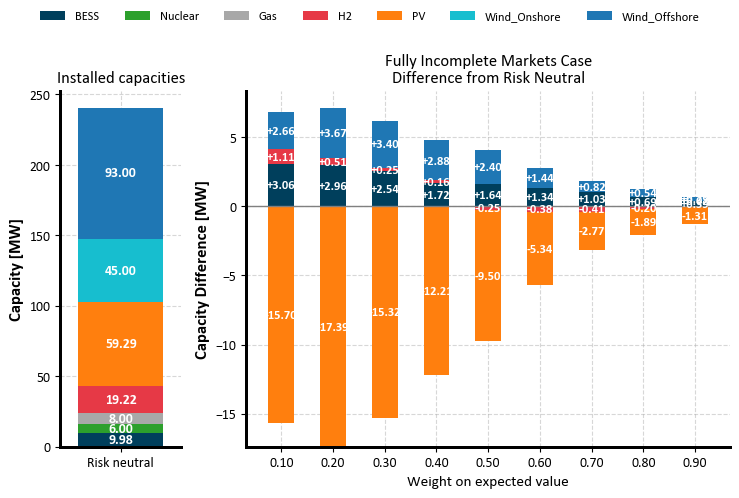

In [130]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
rcParams['patch.edgecolor'] = 'none'
rcParams['patch.linewidth'] = 0
rcParams['patch.antialiased'] = False  # optional: avoids hairline gaps on some backends


# === Global font setup ===
rcParams['font.family'] = 'Calibri'
rcParams['axes.labelweight'] = 'bold'

# === Load data ===
df_raw = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Fully_incomplete_markets_ADMM\PSCC\PSCC_higher_resolution\trycodes_3_final_higher_resolution\H2_15000_ADMM_risk_aversion_results.csv")
df = df_raw[df_raw["delta"] != 0]

# === Filter relevant columns ===
capacity_cols = ['PV', 'Gas', 'Wind_Onshore', 'Wind_Offshore', 'Nuclear', 'BESS_P', 'H2_P']
df = df[['delta'] + capacity_cols]

# === Split data ===
df_rn = df[df['delta'] == 1].iloc[0]
df_others = df[df['delta'] != 1].sort_values('delta')

# === Define techs, labels, and colors ===
techs = ['BESS_P', 'Nuclear',  'Gas', 'H2_P', 'PV', 'Wind_Onshore', 'Wind_Offshore']
labels = ['BESS', 'Nuclear',  'Gas', 'H2', 'PV', 'Wind_Onshore', 'Wind_Offshore']
#techs = ['BESS_P', 'LDES_PHS_P']
#labels = ['BESS', 'PHS']
#colors = {
#    'BESS_P': '#4e79a7',       # Blue
#    'Wind_Offshore': '#af7aa1',          # Violet
#    'Nuclear': "#73ef63",      # Gray
#    'LDES_PHS_P': '#e15759',   # Red
#    'PV': '#f28e2b',           # Orange
#    'Wind_Onshore': '#76c7c0',         # Teal
#    'Gas': "#bab0ac"
#}
colors = {
    'BESS_P': '#003f5c',         # Blue
    'Nuclear': '#2ca02c',        # Green
    'Gas': '#a8a8a8',            # Light Gray
    'H2_P': '#e63946',     # Lighter Red
    'PV': '#ff7f0e',  #ff9933           # Orange
    'Wind_Onshore': '#17becf',   # Teal-Cyan
    'Wind_Offshore': '#1f77b4'   # Slightly darker Teal-Cyan
}

# === Plot setup ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.5, 5), gridspec_kw={'width_ratios': [1, 4]}) # itan 1 4

for ax in [ax1, ax2]:
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.xaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)

# === Left: Risk Neutral ===
bar_width = 0.35
bottom = 0
for tech in techs:
    value = df_rn[tech]
    ax1.bar(0.25, value, width=bar_width, bottom=bottom, color=colors[tech])
    #ax1.bar(0, value, width=bar_width, bottom=bottom, color=colors[tech])
    if value > 1:
        ax1.text(0.25, bottom + value / 2, f'{value:.2f}', ha='center', va='center', color='white', fontsize=10, fontweight='bold')
    bottom += value
ax1.set_xticks([0.25])
ax1.set_xlim(0, 0.5)
ax1.set_xticklabels(['Risk neutral'], fontsize=10)
ax1.set_ylabel("Capacity [MW]", fontsize=12, fontweight='bold')
ax1.set_title("Ιnstalled capacities", fontsize=12, fontweight='normal')
ax1.tick_params(labelsize=10)

# === Right: Differences ===
deltas = df_others['delta'].unique()
x = np.arange(len(deltas))
width = 0.5

bottom_pos = np.zeros_like(x, dtype=float)
bottom_neg = np.zeros_like(x, dtype=float)

for tech in techs:
    diffs = df_others[tech].values - df_rn[tech]
    for i, diff in enumerate(diffs):
        if diff >= 0.01:
            #ax2.bar(x[i], diff, width=width, bottom=bottom_pos[i], color=colors[tech])
            alpha = 0.4 if tech == 'Wind_Onshore' else 0.8 if tech == 'Wind_Offshore' else 0.9 if tech == 'PV' else 0.9 if tech == 'LDES_PHS_P' else 1.0 if tech == 'BESS_P' else 0.7 if tech == 'Gas' else 1.0
            ax2.bar(x[i], diff, width=width, bottom=bottom_pos[i], color=colors[tech])
            
            if abs(diff) > 0.04 and abs(diff) < 0.1:
                ax2.text(x[i], bottom_pos[i] + diff / 20, f'+{diff:.2f}', ha='center', va='center', fontsize=9, color='white',fontweight='bold')
            else:
                ax2.text(x[i], bottom_pos[i] + diff / 2, f'+{diff:.2f}', ha='center', va='center', fontsize=9, color='white',fontweight='bold')
            #if abs(diff) < 0.9 and abs(diff) > 0.5:
            #    ax2.text(x[i], bottom_pos[i] + diff / 3.5, f'+{diff:.2f}', ha='center', va='center', fontsize=9, color='white',fontweight='bold')
            #if abs(diff) < 0.5 and abs(diff) > 0.3:
            #    ax2.text(x[i], bottom_pos[i] - diff/10 , f'+{diff:.2f}', ha='center', va='center', fontsize=9, color='white',fontweight='bold')
            bottom_pos[i] += diff
        else:
            alpha = 0.4 if tech == 'Wind_Onshore' else 0.8 if tech == 'Wind_Offshore' else 0.9 if tech == 'PV' else 0.9 if tech == 'LDES_PHS_P' else 1.0 if tech == 'BESS_P' else 0.7 if tech == 'Gas' else 1.0
            ax2.bar(x[i], diff, width=width, bottom=bottom_neg[i], color=colors[tech])
            #ax2.text(x[i], bottom_neg[i] + diff / 2, f'{diff:.2f}', ha='center', va='center', fontsize=9, color='white',fontweight='bold')
            if abs(diff) > 0.1:
                ax2.text(x[i], bottom_neg[i] + diff / 2, f'{diff:.2f}', ha='center', va='center', fontsize=9, color='white',fontweight='bold')
            bottom_neg[i] += diff

ax2.set_xticks(x)
ax2.set_xticklabels([f"{d:.2f}" for d in deltas], fontsize=10)
ax2.set_xlabel("Weight on expected value", fontsize=11, fontweight='normal')
ax2.set_ylabel("Capacity Difference [MW]", fontsize=12, fontweight='bold')
ax2.set_title("Fully Incomplete Markets Case\nDifference from Risk Neutral", fontsize=12, fontweight='normal')
ax2.axhline(0, color='gray', linewidth=1)

from matplotlib.patches import Rectangle
import matplotlib.lines as mlines

# === Legend ===
#handles = [plt.Rectangle((0, 0), 1, 1, color=colors[t]) for t in techs]
#fig.legend(handles, labels, loc='upper center', ncol=len(techs), fontsize=9, frameon=False)
handles = [Rectangle((0, 0), 1, 1, facecolor=colors[t], edgecolor='black') for t in techs]
fig.legend(handles, labels, loc='upper center', ncol=len(techs), fontsize=9, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

fig.savefig("inomplete_new.png", dpi=400, bbox_inches='tight')

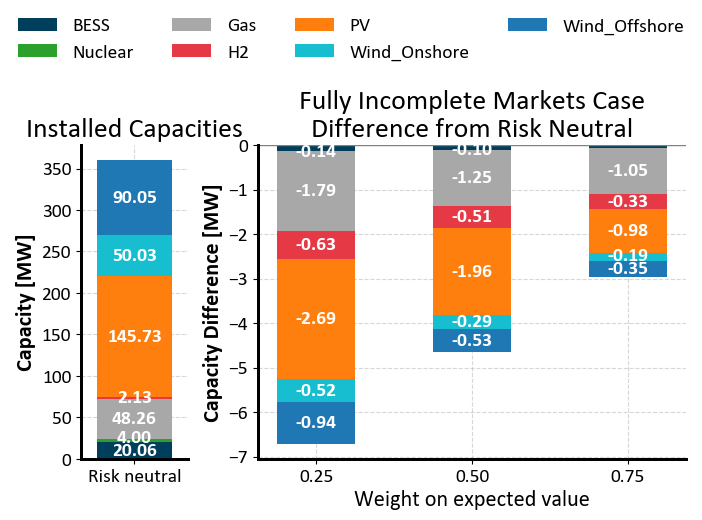

In [21]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
from matplotlib.patches import Rectangle

# === Global figure & font setup (poster-friendly) ===
rcParams['figure.dpi'] = 100           # canvas DPI (export dpi is set in savefig)
rcParams['savefig.dpi'] = 300          # export DPI (you can bump to 400)
rcParams['pdf.fonttype'] = 42          # embed TrueType in PDFs
rcParams['ps.fonttype']  = 42

# Use your poster font (with graceful fallback)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Imperial Sans', 'Calibri', 'DejaVu Sans']

# Sizes tuned for A1, 3-column, body=26 pt, caption=10 pt
TITLE_FS = 20
AXIS_LABEL_FS = 16
TICK_FS = 14
LEGEND_FS = 14
ANNOT_FS = 14

# Line/patch rendering
rcParams['patch.edgecolor'] = 'none'
rcParams['patch.linewidth'] = 0
rcParams['patch.antialiased'] = False

# === Load data ===
df_raw = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Fully_Incomplete\Results\H2_15000_ADMM_risk_aversion_results.csv")
df = df_raw[df_raw["delta"] != 0]

# === Filter relevant columns ===
capacity_cols = ['PV', 'Gas', 'Wind_Onshore', 'Wind_Offshore', 'Nuclear', 'BESS_P', 'H2_P']
df = df[['delta'] + capacity_cols]

# === Split data ===
df_rn = df[df['delta'] == 1].iloc[0]
df_others = df[df['delta'] != 1].sort_values('delta')

# === Define techs, labels, and colors ===
techs  = ['BESS_P', 'Nuclear', 'Gas', 'H2_P', 'PV', 'Wind_Onshore', 'Wind_Offshore']
labels = ['BESS',   'Nuclear',  'Gas', 'H2',   'PV', 'Wind_Onshore', 'Wind_Offshore']
colors = {
    'BESS_P': '#003f5c',
    'Nuclear': '#2ca02c',
    'Gas': '#a8a8a8',
    'H2_P': '#e63946',
    'PV': '#ff7f0e',
    'Wind_Onshore': '#17becf',
    'Wind_Offshore': '#1f77b4'
}

# === Plot setup ===
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(7, 5),  # ~18×12.5 cm (single column)
    gridspec_kw={'width_ratios': [1, 4]}
)

for ax in (ax1, ax2):
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, linewidth=0.8)
    ax.xaxis.grid(True, linestyle='--', alpha=0.5, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=TICK_FS)

# === Left: Risk Neutral ===
bar_width = 0.35
bottom = 0
for tech in techs:
    value = df_rn[tech]
    ax1.bar(0.25, value, width=bar_width, bottom=bottom, color=colors[tech])
    if value > 4.5:
        ax1.text(0.25, bottom + value / 2, f'{value:.2f}',
                 ha='center', va='center', color='white',
                 fontsize=ANNOT_FS, fontweight='bold')
    elif value < 3.75:
        ax1.text(0.25, bottom + value / 2, f'{value:.2f}',
                 ha='center', va='center', color='white',
                 fontsize=ANNOT_FS, fontweight='bold')
    elif 3.75<value < 4.25:
        ax1.text(0.25, bottom + value / 0.75, f'{value:.2f}',
                 ha='center', va='center', color='white',
                 fontsize=ANNOT_FS, fontweight='bold')
    bottom += value

ax1.set_xticks([0.25], labels=['Risk neutral'], fontsize=TICK_FS)
ax1.set_xlim(0, 0.5)
ax1.set_ylabel("Capacity [MW]", fontsize=AXIS_LABEL_FS, fontweight='bold')
ax1.set_title("Installed Capacities", fontsize=TITLE_FS, fontweight='normal')
            
# === Right: Differences ===
deltas = df_others['delta'].unique()
x = np.arange(len(deltas))
width = 0.5
bottom_pos = np.zeros_like(x, dtype=float)
bottom_neg = np.zeros_like(x, dtype=float)

for tech in techs:
    diffs = df_others[tech].values - df_rn[tech]
    for i, diff in enumerate(diffs):
        if diff >= 0.01:
            #ax2.bar(x[i], diff, width=width, bottom=bottom_pos[i], color=colors[tech])
            alpha = 0.4 if tech == 'Wind_Onshore' else 0.8 if tech == 'Wind_Offshore' else 0.9 if tech == 'PV' else 0.9 if tech == 'LDES_PHS_P' else 1.0 if tech == 'BESS_P' else 0.7 if tech == 'Gas' else 1.0
            ax2.bar(x[i], diff, width=width, bottom=bottom_pos[i], color=colors[tech])
            
            if abs(diff) > 0.04 and abs(diff) < 0.1:
                ax2.text(x[i], bottom_pos[i] + diff / 20, f'+{diff:.2f}', ha='center', va='center', fontsize=ANNOT_FS, color='white',fontweight='bold')
            else:
                ax2.text(x[i], bottom_pos[i] + diff / 2, f'+{diff:.2f}', ha='center', va='center', fontsize=ANNOT_FS, color='white',fontweight='bold')
            #if abs(diff) < 0.9 and abs(diff) > 0.5:
            #    ax2.text(x[i], bottom_pos[i] + diff / 3.5, f'+{diff:.2f}', ha='center', va='center', fontsize=9, color='white',fontweight='bold')
            #if abs(diff) < 0.5 and abs(diff) > 0.3:
            #    ax2.text(x[i], bottom_pos[i] - diff/10 , f'+{diff:.2f}', ha='center', va='center', fontsize=9, color='white',fontweight='bold')
            bottom_pos[i] += diff
        else:
            alpha = 0.4 if tech == 'Wind_Onshore' else 0.8 if tech == 'Wind_Offshore' else 0.9 if tech == 'PV' else 0.9 if tech == 'LDES_PHS_P' else 1.0 if tech == 'BESS_P' else 0.7 if tech == 'Gas' else 1.0
            ax2.bar(x[i], diff, width=width, bottom=bottom_neg[i], color=colors[tech])
            #ax2.text(x[i], bottom_neg[i] + diff / 2, f'{diff:.2f}', ha='center', va='center', fontsize=9, color='white',fontweight='bold')
            if abs(diff) > 0.21:
                ax2.text(x[i], bottom_neg[i] + diff / 2, f'{diff:.2f}', ha='center', va='center', fontsize=ANNOT_FS, color='white',fontweight='bold')
            if 0.16<abs(diff) < 0.20:
                ax2.text(x[i], bottom_neg[i] + diff / 3, f'{diff:.2f}', ha='center', va='center', fontsize=ANNOT_FS, color='white',fontweight='bold')
            if 0.09<abs(diff) < 0.15:
                ax2.text(x[i], bottom_neg[i] + diff / 1, f'{diff:.2f}', ha='center', va='center', fontsize=ANNOT_FS, color='white',fontweight='bold')
            bottom_neg[i] += diff

ax2.set_xticks(x, labels=[f"{d:.2f}" for d in deltas], fontsize=TICK_FS)
ax2.set_xlabel("Weight on expected value", fontsize=AXIS_LABEL_FS, fontweight='normal')
ax2.set_ylabel("Capacity Difference [MW]", fontsize=AXIS_LABEL_FS, fontweight='bold')
ax2.set_title("Fully Incomplete Markets Case\nDifference from Risk Neutral",
              fontsize=TITLE_FS, fontweight='normal')
ax2.axhline(0, color='gray', linewidth=1)

# === Legend (top, full width) ===
handles = [Rectangle((0, 0), 1, 1, facecolor=colors[t], edgecolor='black') for t in techs]
fig.legend(handles, labels,
           loc='upper center',
           ncol=4,              # 4 on first row, 3 on second
           fontsize=LEGEND_FS,
           frameon=False,
           bbox_to_anchor=(0.5, 1.05))  # push legend slightly above


plt.tight_layout(rect=[0, 0, 1, 0.90])  # leave space for top legend
# plt.show()

fig.savefig("incomplete_poster.png", dpi=400, bbox_inches='tight')  # 300–400 dpi for print


NameError: name 'TITLE_FS' is not defined

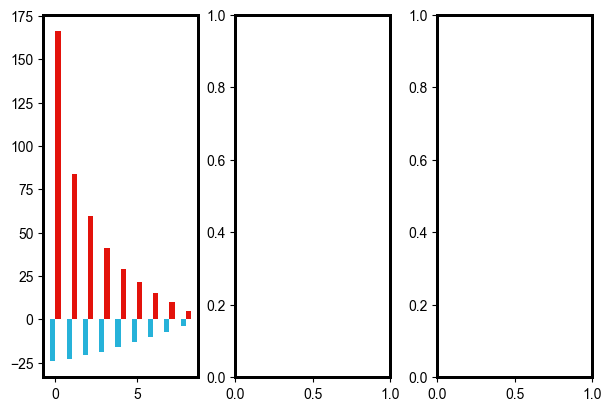

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
from matplotlib.patches import Rectangle

# === Matplotlib setup ===
rcParams['patch.edgecolor'] = 'none'
rcParams['patch.linewidth'] = 0
rcParams['patch.antialiased'] = False
rcParams['font.family'] = 'Arial'
rcParams['axes.labelweight'] = 'bold'

colors = {"complete": "#26B2D9", "incomplete":'#E3120B'}  # green / red

# x positions and labels
x = np.array([0, 1, 2,3,4,5,6,7,8])
xlabels = ["0.10", "0.20", "0.30","0.40","0.50","0.60","0.70","0.80","0.90"]
w = 0.32  # bar width

# ---- data ----
avg_price_complete   = [-23.9474,-22.744,-20.7757,-18.5932,-16.1013,-13.2938,-10.2562,-7.1246,-3.7369]
avg_price_incomplete = [166.0836,83.7993,59.3985,40.8552,29.0886,21.4612,15.2024,9.6888,4.6145]

ue_complete   = [-34.87179039,-30.66198216,-23.72818038,-17.78492171,-10.43839363,-9.282759998,-7.87949059,-4.660225476,-1.523505622]   
# Unserved energy diff (% of risk-neutral)
ue_incomplete = [217.8293848,78.38914726,53.88170779,37.91303061,32.89666195,10.85573464,6.328901556,1.898736857,0.70521638]

cs_complete   = [0.83016565,0.674117485,0.550579355,0.458250858,0.336013129,0.259820012,0.172042919,0.095319238,0.03029917]      # Consumer surplus diff (% of risk-neutral total cost)
cs_incomplete = [-5.190820461,-3.079915438,-1.467151351,-1.076438565,-0.875935069,-0.698888032,-0.4492114,-0.294853899,-0.164813762]



    
def add_labels(ax, rects, vals):
    for r, v in zip(rects, vals):
        y = r.get_height()
        xpos = r.get_x() + r.get_width()/2
        va = 'bottom' if y >= 0 else 'top'
        offset = 0.5 if y >= 0 else -0.5
        ax.text(xpos, y + offset, f"{v:g}", ha='center', va=va, fontsize=15)

fig, axes = plt.subplots(1, 3, figsize=(6, 4), constrained_layout=True)


# ---- panel 1: Average price difference ----
ax = axes[0]
r1 = ax.bar(x - w/2, avg_price_complete,   width=w, color=colors["complete"])
r2 = ax.bar(x + w/2, avg_price_incomplete, width=w, color=colors["incomplete"])
ax.set_title("Average price\n difference", fontsize=TITLE_FS)
ax.set_ylabel("Change in avg. price [$/MWh]", fontsize=AXIS_FS, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(xlabels, fontsize=TICK_FS)

ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, linewidth=0.8)
ax.xaxis.grid(True, linestyle='--', alpha=0.5, linewidth=0.8)
ax.set_axisbelow(True)

ax.tick_params(axis='y', labelsize=TICK_FS)
ax.grid(linestyle='--')
add_labels(ax, r1, avg_price_complete)
add_labels(ax, r2, avg_price_incomplete)

# ---- panel 2: Unserved energy difference ----
ax = axes[1]
r1 = ax.bar(x - w/2, ue_complete,   width=w, color=colors["complete"])
r2 = ax.bar(x + w/2, ue_incomplete, width=w, color=colors["incomplete"])
ax.set_title("Unserved energy\n difference", fontsize=TITLE_FS)
ax.set_ylabel("Change in unserved energy\n[% of risk-neutral]", fontsize=AXIS_FS, fontweight='bold')
#ax.set_xlabel("Weight on expected value", fontsize=AXIS_FS)
ax.set_xticks(x); ax.set_xticklabels(xlabels, fontsize=TICK_FS)

ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, linewidth=0.8)
ax.xaxis.grid(True, linestyle='--', alpha=0.5, linewidth=0.8)
ax.set_axisbelow(True)

ax.tick_params(axis='y', labelsize=TICK_FS)
ax.grid(linestyle='--')
add_labels(ax, r1, ue_complete)
add_labels(ax, r2, ue_incomplete)

# ---- panel 3: Consumer surplus difference ----
ax = axes[2]
r1 = ax.bar(x - w/2, cs_complete,   width=w, color=colors["complete"])
r2 = ax.bar(x + w/2, cs_incomplete, width=w, color=colors["incomplete"])
ax.set_title("Consumer surplus\n difference", fontsize=TITLE_FS)
ax.set_ylabel("Difference in social welfare\n[% of risk-neutral total cost]", fontsize=AXIS_FS, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(xlabels, fontsize=TICK_FS)

ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, linewidth=0.8)
ax.xaxis.grid(True, linestyle='--', alpha=0.5, linewidth=0.8)
ax.set_axisbelow(True)

ax.tick_params(axis='y', labelsize=TICK_FS)
ax.grid(linestyle='--')
add_labels(ax, r1, cs_complete)
add_labels(ax, r2, cs_incomplete)

fig.supxlabel("Weight on expected value", fontsize=AXIS_FS, fontweight='bold')
# ---- shared legend (2-line) ----
fig.legend(["complete", "incomplete"],
           loc="upper center", ncol=2, fontsize=LEG_FS, frameon=False,
           bbox_to_anchor=(0.5, 1.02))

# save (poster-quality)
#fig.savefig("three_panel_poster.png", dpi=400, bbox_inches="tight")
# plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_9092\3286000735.py:119: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.97])


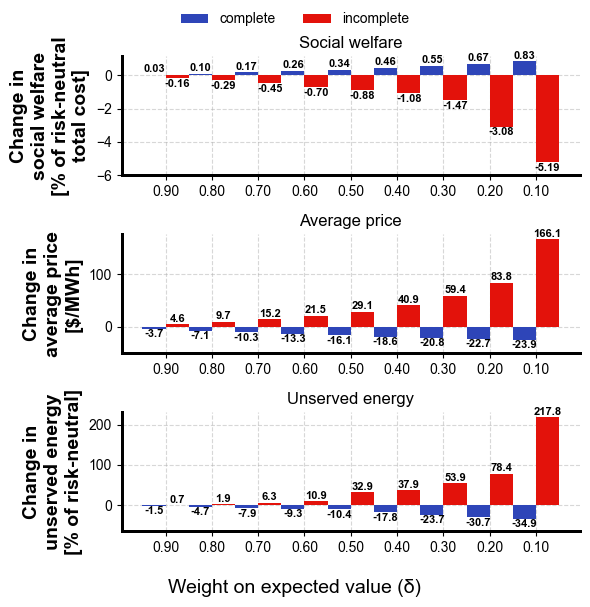

In [113]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
from matplotlib.patches import Rectangle

# === Matplotlib setup (from your second graph) ===
rcParams['patch.edgecolor'] = 'none'
rcParams['patch.linewidth'] = 0
rcParams['patch.antialiased'] = False
rcParams['font.family'] = 'Arial'
rcParams['axes.labelweight'] = 'bold'  # y/x label text weight

# ---- font sizes to mirror the second graph ----
TITLE_FS = 12
AXIS_FS  = 14
TICK_FS  = 10
LEG_FS   = 10

# === Colors ===
colors = {"complete": '#2E45B8', "incomplete": '#E3120B'}

# === Data ===
x = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8])
#xlabels = ["0.10", "0.20", "0.30", "0.40", "0.50", "0.60", "0.70", "0.80", "0.90"]
w = 0.5  # bar width
xlabels = ["0.90", "0.80", "0.70", "0.60", "0.50", "0.40", "0.30", "0.20", "0.10"]
avg_price_complete   = [-23.9474,-22.744,-20.7757,-18.5932,-16.1013,-13.2938,-10.2562,-7.1246,-3.7369]
avg_price_incomplete = [166.0836,83.7993,59.3985,40.8552,29.0886,21.4612,15.2024,9.6888,4.6145]

ue_complete   = [-34.87179039,-30.66198216,-23.72818038,-17.78492171,-10.43839363,-9.282759998,-7.87949059,-4.660225476,-1.523505622]
ue_incomplete = [217.8293848,78.38914726,53.88170779,37.91303061,32.89666195,10.85573464,6.328901556,1.898736857,0.70521638]

cs_complete   = [0.83016565,0.674117485,0.550579355,0.458250858,0.336013129,0.259820012,0.172042919,0.095319238,0.03029917]
cs_incomplete = [-5.190820461,-3.079915438,-1.467151351,-1.076438565,-0.875935069,-0.698888032,-0.4492114,-0.294853899,-0.164813762]

# Or simply reverse your original lists:
avg_price_complete   = avg_price_complete[::-1]
avg_price_incomplete = avg_price_incomplete[::-1]

ue_complete   = ue_complete[::-1]
ue_incomplete = ue_incomplete[::-1]

cs_complete   = cs_complete[::-1]
cs_incomplete = cs_incomplete[::-1]


def add_labels(ax, rects, vals):
    for r, v in zip(rects, vals):
        y = r.get_height()
        xpos = r.get_x() + r.get_width() / 2
        va = 'bottom' if y >= 0 else 'top'
        offset = 0.7 if y >= 0 else -0.7
        ax.text(xpos, y + offset, f"{v:.1f}", ha='center', va=va, fontsize=8, fontweight='bold', color='black')

def add_labels1(ax, rects, vals):
    for r, v in zip(rects, vals):
        y = r.get_height()
        xpos = r.get_x() + r.get_width() / 2
        va = 'bottom' if y >= 0 else 'top'
        offset = 0.05 if y >= 0 else -0.05
        ax.text(xpos, y + offset, f"{v:.2f}", ha='center', va=va, fontsize=8, fontweight='bold', color='black')


# === Figure (use same figure size philosophy; your second graph used (6, 4)) ===
fig, axes = plt.subplots(3, 1, figsize=(6, 6), constrained_layout=True)

# Common axis styling (from the second graph)
def style_ax(ax):
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, linewidth=0.8)
    ax.xaxis.grid(True, linestyle='--', alpha=0.5, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(axis='y', labelsize=TICK_FS)
    ax.tick_params(axis='x', labelsize=TICK_FS)

# ---- Panel 1: Average price difference ----
ax = axes[1]
r1 = ax.bar(x - w/2, avg_price_complete,   width=w, color=colors["complete"])
r2 = ax.bar(x + w/2, avg_price_incomplete, width=w, color=colors["incomplete"])
ax.set_title("Average price", fontsize=TITLE_FS, fontweight='normal')
ax.set_ylabel("Change in\naverage price\n[$/MWh]", fontsize=AXIS_FS, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(xlabels, fontsize=TICK_FS)
ax.set_ylim(-50,None)
style_ax(ax)
add_labels(ax, r1, avg_price_complete)
add_labels(ax, r2, avg_price_incomplete)

# ---- Panel 2: Unserved energy difference ----
ax = axes[2]
r1 = ax.bar(x - w/2, ue_complete,   width=w, color=colors["complete"])
r2 = ax.bar(x + w/2, ue_incomplete, width=w, color=colors["incomplete"])
ax.set_title("Unserved energy", fontsize=TITLE_FS, fontweight='normal')
ax.set_ylabel("Change in\nunserved energy\n[% of risk-neutral]", fontsize=AXIS_FS, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(xlabels, fontsize=TICK_FS)
ax.set_ylim(-65,None)
style_ax(ax)
add_labels(ax, r1, ue_complete)
add_labels(ax, r2, ue_incomplete)

# ---- Panel 3: Consumer surplus difference ----
ax = axes[0]
r1 = ax.bar(x - w/2, cs_complete,   width=w, color=colors["complete"])
r2 = ax.bar(x + w/2, cs_incomplete, width=w, color=colors["incomplete"])
ax.set_title("Social welfare", fontsize=TITLE_FS, fontweight='normal')
ax.set_ylabel("Change in\nsocial welfare\n[% of risk-neutral\ntotal cost]", fontsize=AXIS_FS, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(xlabels, fontsize=TICK_FS)
ax.set_ylim(-6,None)
style_ax(ax)
add_labels1(ax, r1, cs_complete)
add_labels1(ax, r2, cs_incomplete)

# Shared x-label (bold like your second graph's axis labels)
fig.supxlabel("Weight on expected value (δ)", fontsize=AXIS_FS, fontweight='normal')

# Shared legend (same placement/style as second graph)
fig.legend(["complete", "incomplete"],
           loc="upper center", ncol=2, fontsize=LEG_FS, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
# Save with poster-quality dpi (matching second graph)
fig.savefig("three_panel_with_settings1.png", dpi=600, bbox_inches="tight")
# plt.show()


c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


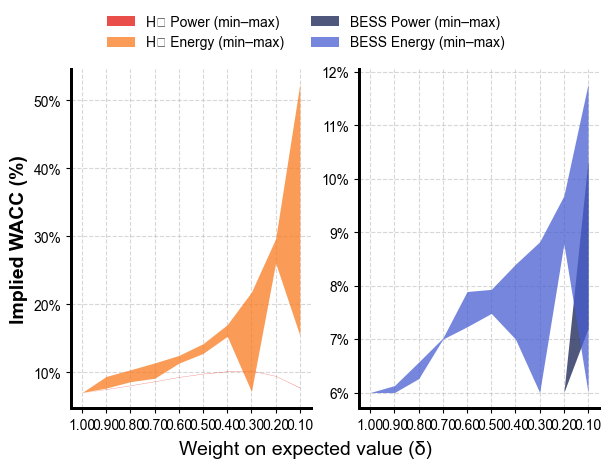

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.ticker import FuncFormatter

# === Matplotlib setup (publishable; matches your style) ===
rcParams['patch.edgecolor'] = 'none'
rcParams['patch.linewidth'] = 0
rcParams['patch.antialiased'] = False
rcParams['font.family'] = 'Arial'
rcParams['axes.labelweight'] = 'bold'

TITLE_FS = 12
AXIS_FS  = 14
TICK_FS  = 10
LEG_FS   = 10

# === X axis: δ from 1.00 -> 0.10 (left to right) ===
delta_labels = ["1.00","0.90","0.80","0.70","0.60","0.50","0.40","0.30","0.20","0.10"]
x = np.arange(len(delta_labels))

# === Data (percent values as given) ===
# Hydrogen
H2_P_max = np.array([7.00,7.53,8.09,8.68,9.32,9.81,10.16,10.27,9.47,7.76])
H2_P_min = np.array([7.00,7.49,8.05,8.64,9.28,9.77,10.11,10.23,9.43,7.70])
H2_E_max = np.array([7.00,9.37,10.35,11.36,12.46,14.19,16.99,21.79,29.65,52.41])
H2_E_min = np.array([7.00,7.66,8.60,9.10,11.32,12.76,15.27,7.15,26.07,15.42])

# BESS
BESS_P_max = np.array([6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,10.35])
BESS_P_min = np.array([6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,7.20])
BESS_E_max = np.array([6.00,6.13,6.57,7.02,7.89,7.93,8.40,8.82,9.68,11.77])
BESS_E_min = np.array([6.00,6.00,6.26,7.00,7.23,7.48,7.00,6.00,8.78,6.00])

# === Colors (distinct per component) ===
# Hydrogen
c_h2_power  = "#E3120B"  # blue
c_h2_energy = "#F97A1F"  # teal
# BESS
c_bess_power  = "#141F52"  # orange
c_bess_energy = "#475ED1"  # red

# === Figure ===
fig, axes = plt.subplots(1, 2, figsize=(6, 4), constrained_layout=True)

def style_ax(ax):
    ax.spines[['top','right']].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, linewidth=0.8)
    ax.xaxis.grid(True, linestyle='--', alpha=0.5, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.set_xticks(x)
    ax.set_xticklabels(delta_labels, fontsize=TICK_FS)
    ax.tick_params(axis='y', labelsize=TICK_FS)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:.0f}%"))

# ---- Panel 1: Hydrogen (two shaded bands) ----
ax = axes[0]
ax.fill_between(x, H2_P_min, H2_P_max, alpha=0.75, color=c_h2_power,  label="H2 Power (min–max)")
#ax.plot(x, (H2_P_min + H2_P_max)/2, color=c_h2_power, linewidth=1)

ax.fill_between(x, H2_E_min, H2_E_max, alpha=0.75, color=c_h2_energy, label="H2 Energy (min–max)")
#ax.plot(x, (H2_E_min + H2_E_max)/2, color=c_h2_energy, linewidth=1, linestyle='--')

#ax.set_title("Hydrogen implied WACC", fontsize=TITLE_FS, fontweight='normal')
ax.set_ylabel("Implied WACC (%)", fontsize=AXIS_FS, fontweight='bold')
style_ax(ax)

# ---- Panel 2: BESS (two shaded bands) ----
ax = axes[1]
ax.fill_between(x, BESS_P_min, BESS_P_max, alpha=0.75, color=c_bess_power,  label="BESS Power (min–max)")
#ax.plot(x, (BESS_P_min + BESS_P_max)/2, color=c_bess_power, linewidth=1)

ax.fill_between(x, BESS_E_min, BESS_E_max, alpha=0.75, color=c_bess_energy, label="BESS Energy (min–max)")
#ax.plot(x, (BESS_E_min + BESS_E_max)/2, color=c_bess_energy, linewidth=1, linestyle='--')

#ax.set_title("BESS implied WACC", fontsize=TITLE_FS, fontweight='normal')
style_ax(ax)

# ---- Shared x-label & legend ----
fig.supxlabel("Weight on expected value (δ)", fontsize=AXIS_FS, fontweight='normal')

# Compact two-row legend at the top
handles0, labels0 = axes[0].get_legend_handles_labels()
handles1, labels1 = axes[1].get_legend_handles_labels()
fig.legend(handles0[:2] + handles1[:2],
           ["H₂ Power (min–max)", "H₂ Energy (min–max)",
            "BESS Power (min–max)", "BESS Energy (min–max)"],
           loc="upper center", ncol=2, fontsize=LEG_FS, frameon=False,
           bbox_to_anchor=(0.5, 1.15))

# Save (poster/paper quality)
# fig.savefig("implied_wacc_shaded.png", dpi=600, bbox_inches="tight")
plt.show()


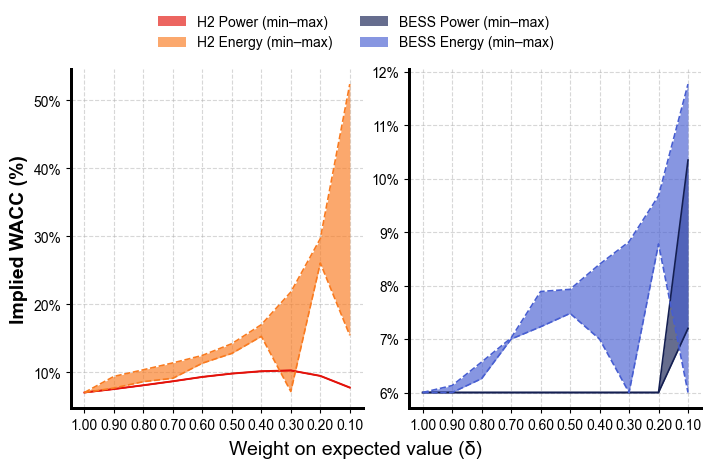

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.ticker import FuncFormatter

# === Matplotlib setup (publishable; matches your style) ===
rcParams['patch.edgecolor'] = 'none'
rcParams['patch.linewidth'] = 0
rcParams['patch.antialiased'] = False
rcParams['font.family'] = 'Arial'
rcParams['axes.labelweight'] = 'bold'

TITLE_FS = 12
AXIS_FS  = 14
TICK_FS  = 10
LEG_FS   = 10

# === X axis: δ from 1.00 -> 0.10 (left to right) ===
delta_labels = ["1.00","0.90","0.80","0.70","0.60","0.50","0.40","0.30","0.20","0.10"]
x = np.arange(len(delta_labels))

# === Data (percent values as given) ===
# Hydrogen
H2_P_max = np.array([7.00,7.53,8.09,8.68,9.32,9.81,10.16,10.27,9.47,7.76])
H2_P_min = np.array([7.00,7.49,8.05,8.64,9.28,9.77,10.11,10.23,9.43,7.70])
H2_E_max = np.array([7.00,9.37,10.35,11.36,12.46,14.19,16.99,21.79,29.65,52.41])
H2_E_min = np.array([7.00,7.66,8.60,9.10,11.32,12.76,15.27,7.15,26.07,15.42])

# BESS
BESS_P_max = np.array([6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,10.35])
BESS_P_min = np.array([6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,7.20])
BESS_E_max = np.array([6.00,6.13,6.57,7.02,7.89,7.93,8.40,8.82,9.68,11.77])
BESS_E_min = np.array([6.00,6.00,6.26,7.00,7.23,7.48,7.00,6.00,8.78,6.00])

# === Colors (distinct per component; fills) ===
c_h2_power  = "#E3120B"
c_h2_energy = "#F97A1F"
c_bess_power  = "#141F52"
c_bess_energy = "#475ED1"

# === Figure ===
fig, axes = plt.subplots(1, 2, figsize=(7, 4), constrained_layout=True)

def style_ax(ax):
    ax.spines[['top','right']].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, linewidth=0.8)
    ax.xaxis.grid(True, linestyle='--', alpha=0.5, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.set_xticks(x)
    ax.set_xticklabels(delta_labels, fontsize=TICK_FS)
    ax.tick_params(axis='y', labelsize=TICK_FS)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:.0f}%"))

# ---- Panel 1: Hydrogen (two shaded bands + boundary lines) ----
ax = axes[0]
ax.fill_between(x, H2_P_min, H2_P_max, alpha=0.65, color=c_h2_power,  label="H2 Power (min–max)")
ax.fill_between(x, H2_E_min, H2_E_max, alpha=0.65, color=c_h2_energy, label="H2 Energy (min–max)")
# Boundary lines: power solid black, energy dashed black
ax.plot(x, H2_P_min, color=c_h2_power, linewidth=1.2)
ax.plot(x, H2_P_max, color=c_h2_power, linewidth=1.2)
ax.plot(x, H2_E_min, color=c_h2_energy, linewidth=1.2, linestyle="--")
ax.plot(x, H2_E_max, color=c_h2_energy, linewidth=1.2, linestyle="--")

ax.set_ylabel("Implied WACC (%)", fontsize=AXIS_FS, fontweight='bold')
style_ax(ax)

# ---- Panel 2: BESS (two shaded bands + boundary lines) ----
ax = axes[1]
ax.fill_between(x, BESS_P_min, BESS_P_max, alpha=0.65, color=c_bess_power,  label="BESS Power (min–max)")
ax.fill_between(x, BESS_E_min, BESS_E_max, alpha=0.65, color=c_bess_energy, label="BESS Energy (min–max)")
# Boundary lines: power solid black, energy dashed black
ax.plot(x, BESS_P_min, color=c_bess_power, linewidth=1.2)
ax.plot(x, BESS_P_max, color=c_bess_power, linewidth=1.2)
ax.plot(x, BESS_E_min, color=c_bess_energy, linewidth=1.2, linestyle="--")
ax.plot(x, BESS_E_max, color=c_bess_energy, linewidth=1.2, linestyle="--")

style_ax(ax)

# ---- Shared x-label & legend ----
fig.supxlabel("Weight on expected value (δ)", fontsize=AXIS_FS, fontweight='normal')

handles0, labels0 = axes[0].get_legend_handles_labels()
handles1, labels1 = axes[1].get_legend_handles_labels()
fig.legend(handles0[:2] + handles1[:2],
           ["H2 Power (min–max)", "H2 Energy (min–max)",
            "BESS Power (min–max)", "BESS Energy (min–max)"],
           loc="upper center", ncol=2, fontsize=LEG_FS, frameon=False,
           bbox_to_anchor=(0.5, 1.15))

# Save (poster/paper quality)
# fig.savefig("implied_wacc_shaded_bounds.png", dpi=600, bbox_inches="tight")
plt.show()



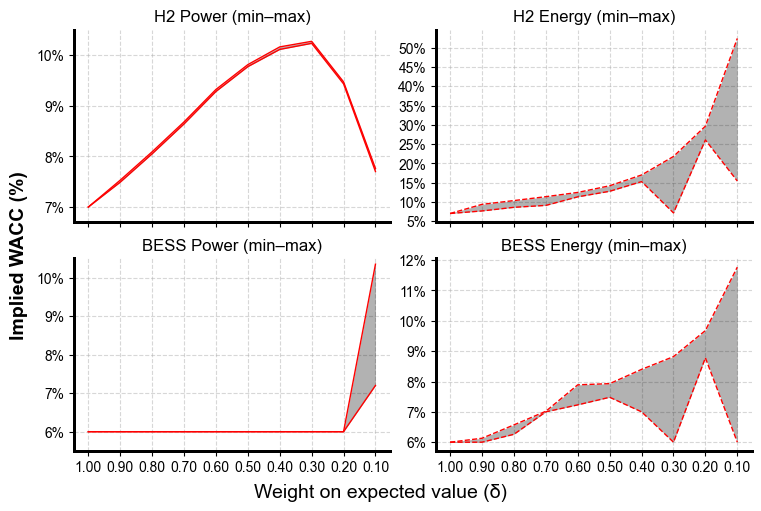

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter
from matplotlib import rcParams
from matplotlib.ticker import FuncFormatter

# === Matplotlib setup (publishable; keep your exact styling) ===
rcParams['patch.edgecolor'] = 'none'
rcParams['patch.linewidth'] = 0
rcParams['patch.antialiased'] = False
rcParams['font.family'] = 'Arial'
rcParams['axes.labelweight'] = 'bold'

TITLE_FS = 12
AXIS_FS  = 14
TICK_FS  = 10
LEG_FS   = 10  # kept for consistency (not used)

# === X axis: δ from 1.00 -> 0.10 (left to right) ===
delta_labels = ["1.00","0.90","0.80","0.70","0.60","0.50","0.40","0.30","0.20","0.10"]
x = np.arange(len(delta_labels))

# === Data (percent values as given) ===
# Hydrogen
H2_P_max = np.array([7.00,7.53,8.09,8.68,9.32,9.81,10.16,10.27,9.47,7.76])
H2_P_min = np.array([7.00,7.49,8.05,8.64,9.28,9.77,10.11,10.23,9.43,7.70])
H2_E_max = np.array([7.00,9.37,10.35,11.36,12.46,14.19,16.99,21.79,29.65,52.41])
H2_E_min = np.array([7.00,7.66,8.60,9.10,11.32,12.76,15.27,7.15,26.07,15.42])

# BESS
BESS_P_max = np.array([6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,10.35])
BESS_P_min = np.array([6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,7.20])
BESS_E_max = np.array([6.00,6.13,6.57,7.02,7.89,7.93,8.40,8.82,9.68,11.77])
BESS_E_min = np.array([6.00,6.00,6.26,7.00,7.23,7.48,7.00,6.00,8.78,6.00])

# === Colors (keep exactly as you set) ===
c_h2_power    = "#E3120B"
c_h2_energy   = "#F97A1F"
c_bess_power  = "#141F52"
c_bess_energy = "#475ED1"

c_h2_power    = "black"
c_h2_energy   = "black"
c_bess_power  = "black"
c_bess_energy = "black"

# === Figure: 2x2 subplots, share X only ===
fig, axs = plt.subplots(2, 2, figsize=(7.5, 5), constrained_layout=True, sharex=True, sharey=False)

def style_ax(ax):
    ax.spines[['top','right']].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, linewidth=0.8)
    ax.xaxis.grid(True, linestyle='--', alpha=0.5, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.set_xticks(x)
    ax.tick_params(axis='x', labelsize=TICK_FS)
    ax.tick_params(axis='y', labelsize=TICK_FS)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:.0f}%"))






# ---- H2 Power (top-left) ----
ax = axs[0,0]
ax.fill_between(x, H2_P_min, H2_P_max, alpha=0.3, color=c_h2_power)
ax.plot(x, H2_P_min, color="red", linewidth=1)
ax.plot(x, H2_P_max, color="red", linewidth=1)
ax.set_ylim(6.7, 10.5)  # optional, keeps nice range
ax.yaxis.set_major_locator(MultipleLocator(1))  # integer % ticks: 7,8,9,10,11
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:.0f}%"))
ax.set_title("H2 Power (min–max)", fontsize=TITLE_FS, fontweight='normal')
style_ax(ax)



# ---- H2 Energy (top-right) ----
ax = axs[0,1]
ax.fill_between(x, H2_E_min, H2_E_max, alpha=0.3, color=c_h2_energy)
ax.plot(x, H2_E_min, color="red", linewidth=1, linestyle="--")
ax.plot(x, H2_E_max, color="red", linewidth=1, linestyle="--")

ax.yaxis.set_major_locator(MultipleLocator(5))  # 5% step works up to ~55%
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:.0f}%"))
ax.set_title("H2 Energy (min–max)", fontsize=TITLE_FS, fontweight='normal')
style_ax(ax)

# ---- BESS Power (bottom-left) ----
ax = axs[1,0]
ax.fill_between(x, BESS_P_min, BESS_P_max, alpha=0.3, color=c_bess_power)
ax.plot(x, BESS_P_min, color="red", linewidth=1)
ax.plot(x, BESS_P_max, color="red", linewidth=1)
ax.set_title("BESS Power (min–max)", fontsize=TITLE_FS, fontweight='normal')
ax.set_ylim(5.5, 10.5)  # optional
ax.yaxis.set_major_locator(MultipleLocator(1))  # integer % ticks
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:.0f}%"))
style_ax(ax)
ax.set_xticklabels(delta_labels, fontsize=TICK_FS)  # show labels on bottom row

# ---- BESS Energy (bottom-right) ----
ax = axs[1,1]
ax.fill_between(x, BESS_E_min, BESS_E_max, alpha=0.3, color=c_bess_energy)
ax.plot(x, BESS_E_min, color="red", linewidth=1, linestyle="--")
ax.plot(x, BESS_E_max, color="red", linewidth=1, linestyle="--")
ax.set_title("BESS Energy (min–max)", fontsize=TITLE_FS, fontweight='normal')
ax.yaxis.set_major_locator(MultipleLocator(1))  # or 0.5 if you want finer ticks
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:.0f}%"))
style_ax(ax)
ax.set_xticklabels(delta_labels, fontsize=TICK_FS)  # show labels on bottom row

# ---- Shared labels (keep your font weights) ----
fig.supxlabel("Weight on expected value (δ)", fontsize=AXIS_FS, fontweight='normal')
fig.supylabel("Implied WACC (%)", fontsize=AXIS_FS, fontweight='bold')

# Save (poster/paper quality)
# fig.savefig("implied_wacc_shaded_2x2_sharex.png", dpi=600, bbox_inches="tight")
plt.show()


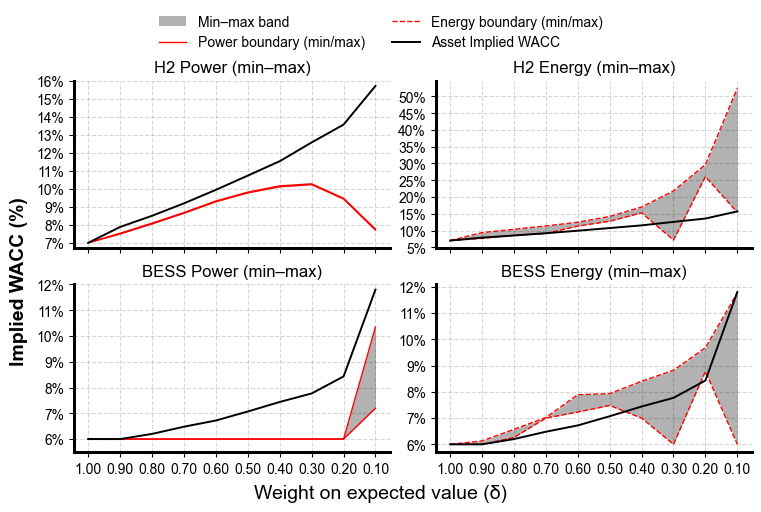

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter
from matplotlib import rcParams
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# === Matplotlib setup (publishable; keep your exact styling) ===
rcParams['patch.edgecolor'] = 'none'
rcParams['patch.linewidth'] = 0
rcParams['patch.antialiased'] = False
rcParams['font.family'] = 'Arial'
rcParams['axes.labelweight'] = 'bold'

TITLE_FS = 12
AXIS_FS  = 14
TICK_FS  = 10
LEG_FS   = 10  # legend font size

# === X axis: δ from 1.00 -> 0.10 (left to right) ===
delta_labels = ["1.00","0.90","0.80","0.70","0.60","0.50","0.40","0.30","0.20","0.10"]
x = np.arange(len(delta_labels))

# === Data (percent values as given) ===
# Hydrogen
H2_P_max = np.array([7.00,7.53,8.09,8.68,9.32,9.81,10.16,10.27,9.47,7.76])
H2_P_min = np.array([7.00,7.49,8.05,8.64,9.28,9.77,10.11,10.23,9.43,7.70])
H2_E_max = np.array([7.00,9.37,10.35,11.36,12.46,14.19,16.99,21.79,29.65,52.41])
H2_E_min = np.array([7.00,7.66,8.60,9.10,11.32,12.76,15.27,7.15,26.07,15.42])

# BESS
BESS_P_max = np.array([6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,10.35])
BESS_P_min = np.array([6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,7.20])
BESS_E_max = np.array([6.00,6.13,6.57,7.02,7.89,7.93,8.40,8.82,9.68,11.77])
BESS_E_min = np.array([6.00,6.00,6.26,7.00,7.23,7.48,7.00,6.00,8.78,6.00])

# === Extra black lines (overall WACC series you provided) ===
wacc_h2   = np.array([7.00,7.88,8.50,9.19,9.94,10.73,11.53,12.57,13.56,15.71])
wacc_bess = np.array([6.00,6.00,6.20,6.48,6.72,7.07,7.44,7.77,8.43,11.80])

# === Colors for fills (you set them to black; keep as-is) ===
c_h2_power    = "black"
c_h2_energy   = "black"
c_bess_power  = "black"
c_bess_energy = "black"

# === Figure: 2x2 subplots, share X only ===
fig, axs = plt.subplots(2, 2, figsize=(7.5, 4.5), constrained_layout=True, sharex=True, sharey=False)

def style_ax(ax):
    ax.spines[['top','right']].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, linewidth=0.8)
    ax.xaxis.grid(True, linestyle='--', alpha=0.5, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.set_xticks(x)
    ax.tick_params(axis='x', labelsize=TICK_FS)
    ax.tick_params(axis='y', labelsize=TICK_FS)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:.0f}%"))

# ---- H2 Power (top-left) ----
ax = axs[0,0]
ax.fill_between(x, H2_P_min, H2_P_max, alpha=0.3, color=c_h2_power)
ax.plot(x, H2_P_min, color="red", linewidth=1)
ax.plot(x, H2_P_max, color="red", linewidth=1)
ax.plot(x, wacc_h2, color="black", linewidth=1.4)  # overall WACC
ax.set_ylim(6.7, 16)
ax.yaxis.set_major_locator(MultipleLocator(1))
ax.set_title("H2 Power (min–max)", fontsize=TITLE_FS, fontweight='normal')
style_ax(ax)

# ---- H2 Energy (top-right) ----
ax = axs[0,1]
ax.fill_between(x, H2_E_min, H2_E_max, alpha=0.3, color=c_h2_energy)
ax.plot(x, H2_E_min, color="red", linewidth=1, linestyle="--")
ax.plot(x, H2_E_max, color="red", linewidth=1, linestyle="--")
ax.plot(x, wacc_h2, color="black", linewidth=1.4)  # overall WACC
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.set_title("H2 Energy (min–max)", fontsize=TITLE_FS, fontweight='normal')
style_ax(ax)

# ---- BESS Power (bottom-left) ----
ax = axs[1,0]
ax.fill_between(x, BESS_P_min, BESS_P_max, alpha=0.3, color=c_bess_power)
ax.plot(x, BESS_P_min, color="red", linewidth=1)
ax.plot(x, BESS_P_max, color="red", linewidth=1)
ax.plot(x, wacc_bess, color="black", linewidth=1.4)  # overall WACC
ax.set_ylim(5.5, 12)
ax.yaxis.set_major_locator(MultipleLocator(1))
ax.set_title("BESS Power (min–max)", fontsize=TITLE_FS, fontweight='normal')
style_ax(ax)
ax.set_xticklabels(delta_labels, fontsize=TICK_FS)

# ---- BESS Energy (bottom-right) ----
ax = axs[1,1]
ax.fill_between(x, BESS_E_min, BESS_E_max, alpha=0.3, color=c_bess_energy)
ax.plot(x, BESS_E_min, color="red", linewidth=1, linestyle="--")
ax.plot(x, BESS_E_max, color="red", linewidth=1, linestyle="--")
ax.plot(x, wacc_bess, color="black", linewidth=1.4)  # overall WACC
ax.yaxis.set_major_locator(MultipleLocator(1))
ax.set_title("BESS Energy (min–max)", fontsize=TITLE_FS, fontweight='normal')
style_ax(ax)
ax.set_xticklabels(delta_labels, fontsize=TICK_FS)

# ---- Shared labels ----
fig.supxlabel("Weight on expected value (δ)", fontsize=AXIS_FS, fontweight='normal')
fig.supylabel("Implied WACC (%)", fontsize=AXIS_FS, fontweight='bold')

# ---- Shared legend (concise, publishable) ----
legend_handles = [
    Patch(facecolor='black', alpha=0.3, edgecolor='none', label='Min–max band'),
    Line2D([0], [0], color='red', lw=1, label='Power boundary (min/max)'),
    Line2D([0], [0], color='red', lw=1, ls='--', label='Energy boundary (min/max)'),
    Line2D([0], [0], color='black', lw=1.4, label='Asset Implied WACC'),
]
fig.legend(legend_handles,
           [h.get_label() for h in legend_handles],
           loc='upper center', ncol=2, fontsize=LEG_FS, frameon=False,
           bbox_to_anchor=(0.5, 1.12))

# Save (poster/paper quality)
# fig.savefig("implied_wacc_shaded_2x2_sharex_with_overall_legend.png", dpi=600, bbox_inches="tight")
plt.show()


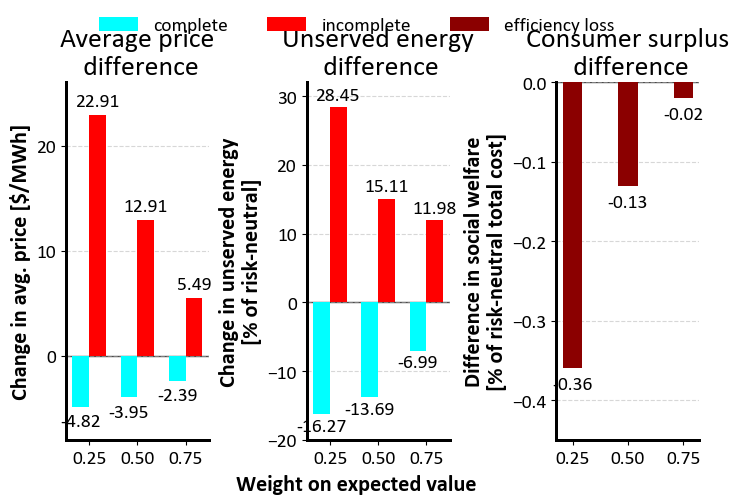

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
from matplotlib.patches import Patch
import matplotlib.ticker as ticker

# ---- poster-ish styling ----
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Imperial Sans', 'Calibri', 'DejaVu Sans']

TITLE_FS, AXIS_FS, TICK_FS, LEG_FS, ANNO_FS = 20, 16, 14, 14, 14

TITLE_FS = 20
AXIS_LABEL_FS = 16
TICK_FS = 14
LEGEND_FS = 14
ANNOT_FS = 14

colors = {"complete": "aqua", "incomplete": "red", "efficiency loss":"#8B0000"}  # green / red

# x positions and labels
x = np.array([0, 1, 2])
xlabels = ["0.25", "0.50", "0.75"]
w = 0.35  # bar width

# ---- data ----
avg_price_complete   = [-4.82, -3.95, -2.39]
avg_price_incomplete = [ 22.91, 12.91,  5.49]

ue_complete   = [-16.27, -13.69, -6.99]
ue_incomplete = [ 28.45,  15.11,  11.98]


sw = [-0.36, -0.13, -0.02]

def add_labels(ax, rects, vals):
    for r, v in zip(rects, vals):
        y = r.get_height()
        xpos = r.get_x() + r.get_width()/2
        va = 'bottom' if y >= 0 else 'top'
        offset = 0.6 if y >= 0 else -0.6
        ax.text(xpos, y + offset, f"{v:g}", ha='center', va=va, fontsize=ANNO_FS)

def stylize(ax):
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', labelsize=TICK_FS)
    ax.axhline(0, color='black', linewidth=1, alpha=0.7, zorder=0)  # zero line

fig, axes = plt.subplots(1, 3, figsize=(7, 4.75), constrained_layout=True)

# === panel 1: Average price ===
ax = axes[0]
r1 = ax.bar(x - w/2, avg_price_complete,   width=w, color=colors["complete"])
r2 = ax.bar(x + w/2, avg_price_incomplete, width=w, color=colors["incomplete"])
ax.set_title("Average price\n difference", fontsize=TITLE_FS)
ax.set_ylabel("Change in avg. price [$/MWh]", fontsize=AXIS_FS, fontweight='bold')
#ax.set_xlabel("Weight on expected value", fontsize=AXIS_FS)
ax.set_xticks(x); ax.set_xticklabels(xlabels)
ax.set_ylim(-8, 26)
ax.set_box_aspect(2.5)
ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
stylize(ax)
add_labels(ax, r1, avg_price_complete)
add_labels(ax, r2, avg_price_incomplete)

# === panel 2: Unserved energy ===
ax = axes[1]
r1 = ax.bar(x - w/2, ue_complete,   width=w, color=colors["complete"])
r2 = ax.bar(x + w/2, ue_incomplete, width=w, color=colors["incomplete"])
ax.set_title("Unserved energy\n difference", fontsize=TITLE_FS)
ax.set_ylabel("Change in unserved energy\n[% of risk-neutral]", fontsize=AXIS_FS, fontweight='bold')
#ax.set_xlabel("Weight on expected value", fontsize=AXIS_FS)
ax.set_xticks(x); ax.set_xticklabels(xlabels)
ax.set_ylim(-20, 32)
ax.set_box_aspect(2.5)
ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
stylize(ax)
add_labels(ax, r1, ue_complete)
add_labels(ax, r2, ue_incomplete)

# === panel 3: Consumer surplus ===
def add_labels1(ax, rects, vals):
    for r, v in zip(rects, vals):
        y = r.get_height()
        xpos = r.get_x() + 0.35/2
        va = 'bottom' if y >= 0 else 'top'
        offset = 0.01 if y >= 0 else -0.01
        ax.text(xpos, y + offset, f"{v:g}", ha='center', va=va, fontsize=ANNO_FS)



ax = axes[2]
#r1 = ax.bar(x - w/2, cs_complete,   width=w, color=colors["complete"])
r2 = ax.bar(x, sw, width=w, color=colors["efficiency loss"])
ax.set_title("Consumer surplus\n difference", fontsize=TITLE_FS)
ax.set_ylabel("Difference in social welfare\n[% of risk-neutral total cost]", fontsize=AXIS_FS, fontweight='bold')
#ax.set_xlabel("Weight on expected value", fontsize=AXIS_FS)
ax.set_xticks(x); ax.set_xticklabels(xlabels)
ax.set_ylim(-0.45, 0)
ax.set_box_aspect(2.5)
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
stylize(ax)
#add_labels(ax, r1, cs_complete)
add_labels1(ax, r2, sw)

fig.supxlabel("Weight on expected value", fontsize=AXIS_FS, fontweight='bold')

# === legend (above plots, 2 columns) ===
handles = [Patch(facecolor=colors['complete']), Patch(facecolor=colors['incomplete']), Patch(facecolor=colors['efficiency loss'])]
labels  = ["complete", "incomplete","efficiency loss"]
fig.legend(handles, labels, loc='upper center', ncol=3, fontsize=LEG_FS, frameon=False,
           bbox_to_anchor=(0.5, 1.05))

# save
fig.savefig("three_panel_poster.png", dpi=400, bbox_inches="tight")
plt.show()

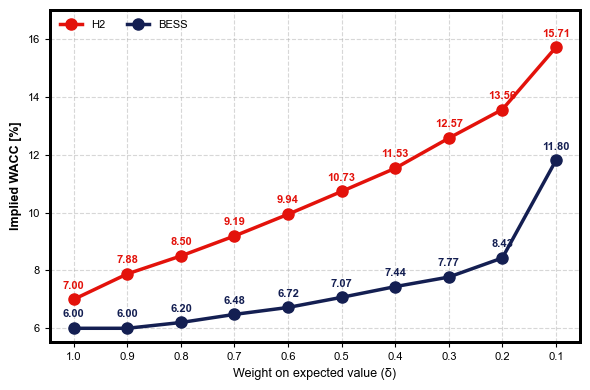

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# === Matplotlib setup (from your style) ===
rcParams['patch.edgecolor']   = 'none'
rcParams['patch.linewidth']   = 0
rcParams['patch.antialiased'] = False
rcParams['font.family']       = 'Arial'
rcParams['axes.labelweight']  = 'bold'

TITLE_FS = 20
AXIS_LABEL_FS = 9
TICK_FS = 8
LEGEND_FS = 8
ANNOT_FS = 8

# ---- Data ----
# Fully Incomplete WACC (percent), aligned to these deltas:
deltas = [1,0.90, 0.80, 0.70, 0.60, 0.50, 0.40, 0.30, 0.20, 0.10]

wacc = {
    "H2":   [7.00,7.88,8.50,9.19,9.94,10.73,11.53,12.57,13.56,15.71],
    "BESS": [6.00,6.00,6.20,6.48,6.72,7.07,7.44,7.77,8.43,11.80],
}


colors = {
    "H2":   '#E3120B',   # red
    "BESS": '#141F52',
}


# Define styles: Power = circle + solid, Energy = triangle + dashed
styles = {
    "H2":   {"marker": "o", "linestyle": "-"},
    "BESS": {"marker": "o", "linestyle": "-"},
}

# ---- Plot ----
fig, ax = plt.subplots(figsize=(6,4))

for tech, values in wacc.items():
    ax.plot(deltas, values,
            marker=styles[tech]["marker"],
            linestyle=styles[tech]["linestyle"],
            label=tech,
            linewidth=2.5, markersize=8,
            color=colors[tech])
    
    # Annotate each point
    for x, y in zip(deltas, values):
        # Skip duplicate labels at δ=1.0
        if x == 1.00 and ("Energy" in tech):
            continue
        
        # Energy labels above, Power labels below
        offset = 0.2 if "Energy" in tech else +0.65
        va = "bottom" if "Energy" in tech else "top"
        
        if tech.startswith("H₂") and np.isclose(x, 0.25):
            offset, va = -offset, ("top" if va == "bottom" else "bottom")
        
        ax.text(x, y+offset, f"{y:.2f}",
                ha="center", va=va,
                fontsize=ANNOT_FS, color=colors[tech], fontweight="bold")

# ---- Axes formatting ----
ax.set_xlabel("Weight on expected value (δ)", fontsize=AXIS_LABEL_FS, fontweight='normal')
ax.set_ylabel("Implied WACC [%]", fontsize=AXIS_LABEL_FS, fontweight='bold')
ax.tick_params(axis='both', labelsize=TICK_FS)
ax.set_xticks(deltas)
ax.invert_xaxis()  # so δ=1 (risk neutral) is left
ax.set_ylim(None, 17)

# ---- Legend ----
ax.legend(fontsize=LEGEND_FS, ncol=2, loc="upper left", frameon=False)

# ---- Grid ----
ax.grid(True, linestyle="--", alpha=0.5)

# ---- Save ----
plt.tight_layout()
#plt.savefig("wacc_line_poster.png", dpi=400, bbox_inches="tight")
#plt.savefig("wacc_line_poster.svg", format="svg", dpi=600, bbox_inches="tight")
plt.show()


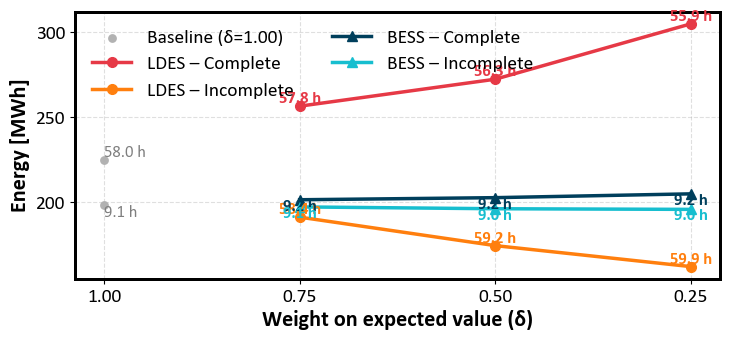

In [28]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ---- poster-ish styling ----
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Imperial Sans', 'Calibri', 'DejaVu Sans']

TITLE_FS = 20
AXIS_LABEL_FS = 16
TICK_FS = 14
LEGEND_FS = 14
ANNOT_FS = 12

# ---- X ----
deltas_main = [0.75, 0.50, 0.25]   # the cases you compare
delta_baseline = 1.00               # optional reference

# ---- Data (from your table) ----
# Baseline (risk neutral, δ=1.00)
ldes_E_base, ldes_H_base = 224.70, 58.03
bess_E_base, bess_H_base = 198.52, 9.10

# Complete
ldes_E_comp = [256.37, 272.20, 304.71]
ldes_H_comp = [57.79, 56.28, 55.86]
bess_E_comp = [201.40, 202.63, 204.87]
bess_H_comp = [ 9.17,   9.16,   9.19]

# Incomplete
ldes_E_incomp = [191.19, 174.46, 162.14]
ldes_H_incomp = [58.42,  59.23,  59.85]
bess_E_incomp = [197.20, 196.12, 195.75]
bess_H_incomp = [ 9.07,   9.04,   9.04]

# ---- Colors consistent with your other figure ----
COL_LDES_C   = "#e63946"  # red
COL_LDES_I   = "#ff7f0e"  # orange
COL_BESS_C   = "#003f5c"  # dark blue
COL_BESS_I   = "#17becf"  # teal
COL_BASE     = "#7f7f7f"  # gray (reference)

# ---- Plot ----
fig, ax = plt.subplots(figsize=(7.4, 3.5))

# Optional faint baseline reference markers at δ=1.00
ax.scatter([delta_baseline, delta_baseline], [ldes_E_base, bess_E_base],
           s=40, color=COL_BASE, alpha=0.6, label="Baseline (δ=1.00)")
ax.text(delta_baseline, ldes_E_base, "58.0 h", ha="left", va="bottom",
        fontsize=ANNOT_FS, color=COL_BASE)
ax.text(delta_baseline, bess_E_base,  "9.1 h", ha="left", va="top",
        fontsize=ANNOT_FS, color=COL_BASE)

# Lines: Energy vs δ
def plot_series(x, y, h, color, label, marker):
    ax.plot(x, y, marker=marker, linestyle="-", linewidth=2.5,
            markersize=7, color=color, label=label)
    # annotate each point with Duration [h]
    for xi, yi, hi in zip(x, y, h):
        ax.text(xi, yi, f"{hi:.1f} h", fontsize=ANNOT_FS,
                ha="center", va=("bottom" if "LDES" in label else "top"),
                color=color, fontweight="bold")

plot_series(deltas_main, ldes_E_comp,   ldes_H_comp,   COL_LDES_C, "LDES – Complete",   "o")
plot_series(deltas_main, ldes_E_incomp, ldes_H_incomp, COL_LDES_I, "LDES – Incomplete", "o")
plot_series(deltas_main, bess_E_comp,   bess_H_comp,   COL_BESS_C, "BESS – Complete",   "^")
plot_series(deltas_main, bess_E_incomp, bess_H_incomp, COL_BESS_I, "BESS – Incomplete", "^")

# ---- Axes & layout ----
ax.set_xlabel("Weight on expected value (δ)", fontsize=AXIS_LABEL_FS, fontweight="bold")
ax.set_ylabel("Energy [MWh]", fontsize=AXIS_LABEL_FS, fontweight="bold")
ax.set_xticks([1.00, 0.75, 0.50, 0.25])
ax.invert_xaxis()  # put δ=1.00 at left (to match your style)
ax.tick_params(axis='both', labelsize=TICK_FS)
ax.grid(True, linestyle="--", alpha=0.4)

# Legend: compact
ax.legend(fontsize=LEGEND_FS, ncol=2, frameon=False, loc="upper left")

plt.tight_layout()
#plt.savefig("energy_lines_with_duration.svg", format="svg", dpi=600, bbox_inches="tight")
# plt.savefig("energy_lines_with_duration.tiff", dpi=600, bbox_inches="tight")
plt.show()



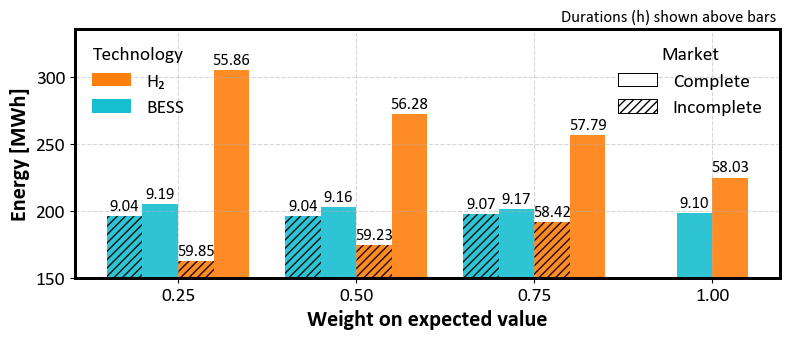

In [80]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib import rcParams

# ---- Poster styling (matches your other figure) ----
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Imperial Sans', 'Calibri', 'DejaVu Sans']

AXIS_LABEL_FS = 16
TICK_FS = 14
LEGEND_FS = 14
ANNOT_FS = 12

# ---- Data ----
deltas = [1.00, 0.75, 0.50, 0.25]
x = np.arange(len(deltas))

# Baseline (δ=1.00)
ldes_E_base, ldes_H_base = 224.70, 58.03
bess_E_base, bess_H_base = 198.52, 9.10

# Complete
ldes_E_c = [256.37, 272.20, 304.71]
ldes_H_c = [57.79, 56.28, 55.86]
bess_E_c = [201.40, 202.63, 204.87]
bess_H_c = [ 9.17,   9.16,   9.19]

# Incomplete
ldes_E_i = [191.19, 174.46, 162.14]
ldes_H_i = [58.42,  59.23,  59.85]
bess_E_i = [197.20, 196.12, 195.75]
bess_H_i = [ 9.07,   9.04,   9.04]

# ---- Colors ----
COL_LDES = "#ff7f0e"   # orange
COL_BESS = "#17becf"   # teal

# ---- Layout params ----
width = 0.20     # bar width
YMIN  = 150      # start y-axis here (set to 100 if you prefer)
Y_PAD = 2      # vertical pad for duration labels

# ---- Plot ----
fig, ax = plt.subplots(figsize=(8.0, 3.5))

# --- δ = 1.00 (center exactly two bars) ---
pos_ldes_base = x[0] - width/2
pos_bess_base = x[0] + width/2

ax.bar(pos_ldes_base, ldes_E_base, width,
       color=COL_LDES, edgecolor="black", alpha=0.9)
ax.text(pos_ldes_base, ldes_E_base + Y_PAD, f"{ldes_H_base:.2f}",
        ha="center", va="bottom", fontsize=ANNOT_FS, fontweight="normal")

ax.bar(pos_bess_base, bess_E_base, width,
       color=COL_BESS, edgecolor="black", alpha=0.9)
ax.text(pos_bess_base, bess_E_base + Y_PAD, f"{bess_H_base:.2f}",
        ha="center", va="bottom", fontsize=ANNOT_FS, fontweight="normal")

# --- δ = 0.75, 0.50, 0.25 (grouped with hatch for Incomplete) ---
shifts = {
    "LDES Complete":   -1.5*width,
    "LDES Incomplete": -0.5*width,
    "BESS Complete":    0.5*width,
    "BESS Incomplete":  1.5*width,
}

def plot_group(values_E, values_H, color, hatch, label_key):
    # positions for δ = 0.75..0.25 (skip index 0 which is δ=1.00)
    pos = x[1:] + shifts[label_key]
    bars = ax.bar(pos, values_E, width,
                  color=COL_LDES if "LDES" in label_key else COL_BESS,
                  edgecolor="black", hatch=hatch, alpha=0.9)
    for xi, yi, hi in zip(pos, values_E, values_H):
        ax.text(xi, yi + Y_PAD, f"{hi:.2f}",
                ha="center", va="bottom", fontsize=ANNOT_FS, fontweight="normal")
    return bars

plot_group(ldes_E_c, ldes_H_c, COL_LDES, "",    "LDES Complete")
plot_group(ldes_E_i, ldes_H_i, COL_LDES, "////",  "LDES Incomplete")
plot_group(bess_E_c, bess_H_c, COL_BESS, "",    "BESS Complete")
plot_group(bess_E_i, bess_H_i, COL_BESS, "////",  "BESS Incomplete")

# ---- Axes & ticks ----
ax.set_xlabel("Weight on expected value", fontsize=AXIS_LABEL_FS, fontweight="bold")
ax.set_ylabel("Energy [MWh]", fontsize=AXIS_LABEL_FS, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([f"{d:.2f}" for d in deltas], fontsize=TICK_FS)
ax.tick_params(axis='y', labelsize=TICK_FS)

# y-limit: start at YMIN, top = 1.1×max energy
max_E = max([ldes_E_base, bess_E_base,
             *ldes_E_c, *ldes_E_i, *bess_E_c, *bess_E_i])
ax.set_ylim(YMIN, max_E*1.10)

# Optional: keep δ=1 at the left (consistent with your other plots)
ax.invert_xaxis()

# ---- Grid ----
ax.grid(True,  linestyle="--", alpha=0.5)

# ---- Compact legend explaining color (tech) and hatch (market) ----
legend_colors = [
    Patch(facecolor=COL_LDES, edgecolor='black',  label='H₂'),
    Patch(facecolor=COL_BESS, edgecolor='black', label='BESS'),
]
legend_hatches = [
    Patch(facecolor='white', edgecolor='black',linewidth=0.5, hatch='',   label='Complete'),
    Patch(facecolor='white', edgecolor='black', linewidth=0.5, hatch='////', label='Incomplete'),
]


leg1 = ax.legend(handles=legend_colors, loc="upper left", frameon=False, fontsize=LEGEND_FS, title="Technology", title_fontsize=LEGEND_FS)
ax.add_artist(leg1)
ax.legend(handles=legend_hatches, loc="upper right", frameon=False, fontsize=LEGEND_FS, title="Market", title_fontsize=LEGEND_FS)
ax.text(0.995, 1.02, "Durations (h) shown above bars",
        transform=ax.transAxes, ha="right", va="bottom",
        fontsize=ANNOT_FS)
plt.tight_layout()
plt.savefig("storage_energy_bars_baseline_centered.svg", format="svg", dpi=600, bbox_inches="tight")
# plt.savefig("storage_energy_bars_baseline_centered.tiff", dpi=600, bbox_inches="tight")
plt.show()


| Metric         | Based on          | What it Tells You                                                                            |
| -------------- | ----------------- | -------------------------------------------------------------------------------------------- |
| `total_demand` | `weighted_demand` | Total energy consumed over the year (in MWh), accounting for weights (e.g., time fractions). |
| `max_load`     | `load`            | Highest instantaneous demand (e.g., peak in MW).                                             |
| `min_load`     | `load`            | Lowest observed demand.                                                                      |
| `mean_load`    | `load`            | Average demand across all time steps.                                                        |
| `median_load`  | `load`            | The "middle" value — half the values are above, half below.                                  |
| `std_load`     | `load`            | Standard deviation — how much demand fluctuates around the mean.                             |
| `range_load`   | `load`            | Difference between max and min — indicates spread.                                           |
| `p10_load`     | `load`            | 10th percentile — 10% of values are below this.                                              |
| `p90_load`     | `load`            | 90th percentile — 90% of values are below this.                                              |


In [10]:

import pandas as pd
import numpy as np

# Weighted std function
def weighted_std(values, weights):
    average = np.average(values, weights=weights)
    variance = np.average((values - average) ** 2, weights=weights)
    return np.sqrt(variance)

# Weighted quantile function
def weighted_quantile(values, weights, quantile):
    values = np.array(values)
    weights = np.array(weights)
    
    sorter = np.argsort(values)
    values = values[sorter]
    weights = weights[sorter]
    
    cumulative_weight = np.cumsum(weights)
    total_weight = cumulative_weight[-1]
    
    return values[np.searchsorted(cumulative_weight, quantile * total_weight)]


# Load the uploaded data
load_df = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Comparison_central_planner_ADMM\data\concatenated_load_profiles_672_30yr_new.csv")
weights_df = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Comparison_central_planner_ADMM\data\concatenated_weights_672_30yr_new.csv")

total_scenarios = [19, 12, 7, 11, 23, 8, 30, 24, 1, 26, 29, 13, 4, 22, 27]

# Keep only the total scenarios
load_df   = load_df[load_df["O"].isin(total_scenarios)].copy()
weights_df = weights_df[weights_df["O"].isin(total_scenarios)].copy()
# Merge load and weight data
merged_df = pd.merge(load_df, weights_df, on=["T", "O"], how="inner")

# Compute weighted demand per timestep
merged_df["weighted_demand"] = merged_df["load"] * merged_df["weight"]

# Now build demand_stats with weighted metrics
demand_stats = (
    merged_df.groupby("O")
    .apply(lambda group: pd.Series({
        "total_demand": group["weighted_demand"].sum(),
        "total_weight": group["weight"].sum(),
        "average_load": group["weighted_demand"].sum() / group["weight"].sum(),
        "max_load": group["load"].max(),
        "min_load": group["load"].min(),
        #"mean_load": np.average(group["load"], weights=group["weight"]),
        "std_load": weighted_std(group["load"], group["weight"]),
        "range_load": group["load"].max() - group["load"].min(),
        "p10_load": weighted_quantile(group["load"], group["weight"], 0.10),
        "p90_load": weighted_quantile(group["load"], group["weight"], 0.90),
    }))
    .reset_index()
)

print(demand_stats)
#demand_stats.to_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Comparison_central_planner_ADMM\demand_stats.csv", index=False)
# Define the tail scenarios
tail_scenarios = [11,12,19,23,24,30,7,8]

# First, calculate total demand per scenario
total_demand_per_scenario = (
    merged_df.groupby("O", as_index=False)["weighted_demand"]
    .sum()
    .rename(columns={"weighted_demand": "total_demand"})
)
#print(total_demand_per_scenario)
# Split the scenarios
tail_df = total_demand_per_scenario[total_demand_per_scenario["O"].isin(tail_scenarios)]
non_tail_df = total_demand_per_scenario[~total_demand_per_scenario["O"].isin(tail_scenarios)]

# Calculate average total demand for each group
average_tail_demand = tail_df["total_demand"].mean()
average_non_tail_demand = non_tail_df["total_demand"].mean()

print("Average total demand (tail scenarios):", average_tail_demand)
print("Average total demand (non-tail scenarios):", average_non_tail_demand)


     O  total_demand  total_weight  average_load  max_load  min_load  \
0    1   5795.866199        8760.0      0.661629  0.935079  0.426762   
1    4   5815.532696        8760.0      0.663874  0.925387  0.444527   
2    7   5723.973734        8760.0      0.653422  0.927324  0.439406   
3    8   5764.580473        8760.0      0.658057  0.935021  0.446177   
4   11   5723.973734        8760.0      0.653422  0.938159  0.449913   
5   12   5723.973734        8760.0      0.653422  0.943096  0.440099   
6   13   5815.532695        8760.0      0.663874  0.928620  0.475884   
7   19   5694.585717        8760.0      0.650067  0.932159  0.436218   
8   22   5930.466593        8760.0      0.676994  0.963595  0.451964   
9   23   5764.580474        8760.0      0.658057  0.936346  0.444398   
10  24   5764.580473        8760.0      0.658057  0.931397  0.457066   
11  26   5795.866199        8760.0      0.661629  0.932977  0.439965   
12  27   5930.466593        8760.0      0.676994  0.965735  0.44

C:\Users\user\AppData\Local\Temp\ipykernel_20620\2855034433.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: pd.Series({


In [21]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np

# --- Hardcode your scenario stats ---
data = [
    # O, total_demand, total_weight, average_load, max_load, min_load, std_load, range_load, p10_load, p90_load
    [1, 5795.866199, 8760.0, 0.661629, 0.932878, 0.458467, 0.104739, 0.474411, 0.535403, 0.821755],
    [2, 5723.973734, 8760.0, 0.653422, 0.923169, 0.433915, 0.105071, 0.489254, 0.522066, 0.806970],
    [3, 5694.585717, 8760.0, 0.650067, 0.939843, 0.466063, 0.098640, 0.473780, 0.525525, 0.785159],
    [4, 5675.112836, 8760.0, 0.647844, 0.930429, 0.448082, 0.101178, 0.482346, 0.521243, 0.771556],
    [5, 5723.973734, 8760.0, 0.653422, 0.927663, 0.449913, 0.104041, 0.477749, 0.520086, 0.800243],
    [6, 5542.032481, 8760.0, 0.632652, 0.917140, 0.419452, 0.096474, 0.497688, 0.510443, 0.767059],
    [7, 5694.585716, 8760.0, 0.650067, 0.929405, 0.440961, 0.097901, 0.488444, 0.530163, 0.783175],
    [8, 5694.585716, 8760.0, 0.650067, 0.926317, 0.421205, 0.098421, 0.505112, 0.528396, 0.777096],
    [9, 5795.866199, 8760.0, 0.661629, 0.927464, 0.468599, 0.104281, 0.458865, 0.532726, 0.815228],
    [10, 5764.580473, 8760.0, 0.658057, 0.929485, 0.457709, 0.102358, 0.471777, 0.536946, 0.804371],
    [11, 5574.951459, 8760.0, 0.636410, 0.923942, 0.413076, 0.106655, 0.510866, 0.502659, 0.791300],
    [12, 5495.396293, 8760.0, 0.627328, 0.960954, 0.416723, 0.100468, 0.544231, 0.503691, 0.769163],
    [13, 5574.951458, 8760.0, 0.636410, 0.906249, 0.435218, 0.106041, 0.471031, 0.499667, 0.796482],
    [14, 5795.866199, 8760.0, 0.661629, 0.932603, 0.461126, 0.104033, 0.471477, 0.532351, 0.820417],
    [15, 5930.466593, 8760.0, 0.676994, 0.958186, 0.433979, 0.110293, 0.524208, 0.543544, 0.848919],
    [16, 5693.382130, 8760.0, 0.649929, 0.945602, 0.432418, 0.105453, 0.513184, 0.525585, 0.796056],
    [17, 5815.532696, 8760.0, 0.663874, 0.923782, 0.460364, 0.099485, 0.463418, 0.540595, 0.813992],
    [18, 5542.032481, 8760.0, 0.632652, 0.898855, 0.448474, 0.097714, 0.450381, 0.509195, 0.760992],
    [19, 5542.032481, 8760.0, 0.632652, 0.895536, 0.448383, 0.098095, 0.447153, 0.510280, 0.772265],
    [20, 5495.396294, 8760.0, 0.627328, 0.929788, 0.442223, 0.101147, 0.487565, 0.507626, 0.776838],
    [21, 5815.532695, 8760.0, 0.663874, 0.916220, 0.455815, 0.101171, 0.460405, 0.540593, 0.818152],
    [22, 5626.716457, 8760.0, 0.642319, 0.929636, 0.453562, 0.110810, 0.476073, 0.507727, 0.810511],
    [23, 5574.951459, 8760.0, 0.636410, 0.923526, 0.442632, 0.106752, 0.480894, 0.506600, 0.791470],
    [24, 5815.532695, 8760.0, 0.663874, 0.912746, 0.470564, 0.099018, 0.442181, 0.539839, 0.803846],
    [25, 5495.396293, 8760.0, 0.627328, 0.945904, 0.413950, 0.100513, 0.531953, 0.502593, 0.768994],
    [26, 5675.112836, 8760.0, 0.647844, 0.922131, 0.432313, 0.101059, 0.489818, 0.523255, 0.794201],
    [27, 5764.580473, 8760.0, 0.658057, 0.931397, 0.466468, 0.102472, 0.464928, 0.534069, 0.804322],
    [28, 5764.580473, 8760.0, 0.658057, 0.937641, 0.469366, 0.101850, 0.468275, 0.531459, 0.798807],
    [29, 5694.585717, 8760.0, 0.650067, 0.940968, 0.466723, 0.097520, 0.474245, 0.527792, 0.784811],
    [30, 5626.716457, 8760.0, 0.642319, 0.943564, 0.418918, 0.113234, 0.524645, 0.506819, 0.815595],
]

columns = ["O","total_demand","total_weight","average_load","max_load","min_load",
           "std_load","range_load","p10_load","p90_load"]

df = pd.DataFrame(data, columns=columns)

# --- Cluster selection ---
features = ["average_load","max_load","min_load","std_load","range_load","p10_load","p90_load"]

X = df[features].values
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=15, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

df["cluster"] = labels

# Pick representative scenario closest to centroid in each cluster
selected_indices = []
for cluster_id in range(15):
    cluster_points = np.where(labels == cluster_id)[0]
    centroid = kmeans.cluster_centers_[cluster_id]
    distances = np.linalg.norm(X_scaled[cluster_points] - centroid, axis=1)
    rep_idx = cluster_points[np.argmin(distances)]
    selected_indices.append(rep_idx)

selected = df.loc[selected_indices].sort_values("O")

print("Selected representative scenarios:")
print(selected[["O","average_load","range_load","std_load","min_load","max_load"]])

# save
#selected.to_csv("selected_representative_scenarios.csv", index=False)


Selected representative scenarios:
     O  average_load  range_load  std_load  min_load  max_load
2    3      0.650067    0.473780  0.098640  0.466063  0.939843
4    5      0.653422    0.477749  0.104041  0.449913  0.927663
5    6      0.632652    0.497688  0.096474  0.419452  0.917140
6    7      0.650067    0.488444  0.097901  0.440961  0.929405
10  11      0.636410    0.510866  0.106655  0.413076  0.923942
12  13      0.636410    0.471031  0.106041  0.435218  0.906249
14  15      0.676994    0.524208  0.110293  0.433979  0.958186
15  16      0.649929    0.513184  0.105453  0.432418  0.945602
16  17      0.663874    0.463418  0.099485  0.460364  0.923782
18  19      0.632652    0.447153  0.098095  0.448383  0.895536
19  20      0.627328    0.487565  0.101147  0.442223  0.929788
21  22      0.642319    0.476073  0.110810  0.453562  0.929636
24  25      0.627328    0.531953  0.100513  0.413950  0.945904
26  27      0.658057    0.464928  0.102472  0.466468  0.931397
29  30      0.642319

c:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [ ]:

import pandas as pd
import numpy as np

# Weighted std function
def weighted_std(values, weights):
    average = np.average(values, weights=weights)
    variance = np.average((values - average) ** 2, weights=weights)
    return np.sqrt(variance)

# Weighted quantile function
def weighted_quantile(values, weights, quantile):
    values = np.array(values)
    weights = np.array(weights)
    
    sorter = np.argsort(values)
    values = values[sorter]
    weights = weights[sorter]
    
    cumulative_weight = np.cumsum(weights)
    total_weight = cumulative_weight[-1]
    
    return values[np.searchsorted(cumulative_weight, quantile * total_weight)]


# Load the uploaded data
load_df = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Comparison_central_planner_ADMM\data\concatenated_load_profiles_672_30yr_new.csv")
weights_df = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Comparison_central_planner_ADMM\data\concatenated_weights_672_30yr_new.csv")

nontail = [1, 26, 29, 13, 4, 22, 27]
load_df_n   = load_df[load_df["O"].isin(nontail)].copy()
weights_df_n = weights_df[weights_df["O"].isin(nontail)].copy()
merged_df_n = pd.merge(load_df_n, weights_df_n, on=["T", "O"], how="inner")
merged_df_n["weighted_demand"] = merged_df_n["load"] * merged_df_n["weight"]


tail_scenarios = [11,12,19,23,24,30,7,8]
load_df_t   = load_df[load_df["O"].isin(tail_scenarios)].copy()
weights_df_t = weights_df[weights_df["O"].isin(tail_scenarios)].copy()
# Merge load and weight data
merged_df_t = pd.merge(load_df_t, weights_df_t, on=["T", "O"], how="inner")
merged_df_t["weighted_demand"] = merged_df_t["load"] * merged_df_t["weight"]

# Now build demand_stats with weighted metrics
demand_statstail = (
    merged_df_t.groupby("O")
    .apply(lambda group: pd.Series({
        "total_demand": group["weighted_demand"].sum(),
    }))
    .reset_index()
)

demand_statsnontail = (
    merged_df_n.groupby("O")
    .apply(lambda group: pd.Series({
        "total_demand": group["weighted_demand"].sum(),
    }))
    .reset_index()
)
print(demand_statsnontail)
print(demand_statstail)



    O  total_demand
0   1   5795.866199
1   4   5815.532696
2  13   5815.532695
3  22   5930.466593
4  26   5795.866199
5  27   5930.466593
6  29   5795.866199
    O  total_demand
0   7   5723.973734
1   8   5764.580473
2  11   5723.973734
3  12   5723.973734
4  19   5694.585717
5  23   5764.580474
6  24   5764.580473
7  30   5764.580473


C:\Users\user\AppData\Local\Temp\ipykernel_24256\82883834.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: pd.Series({
C:\Users\user\AppData\Local\Temp\ipykernel_24256\82883834.py:54: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: pd.Series({


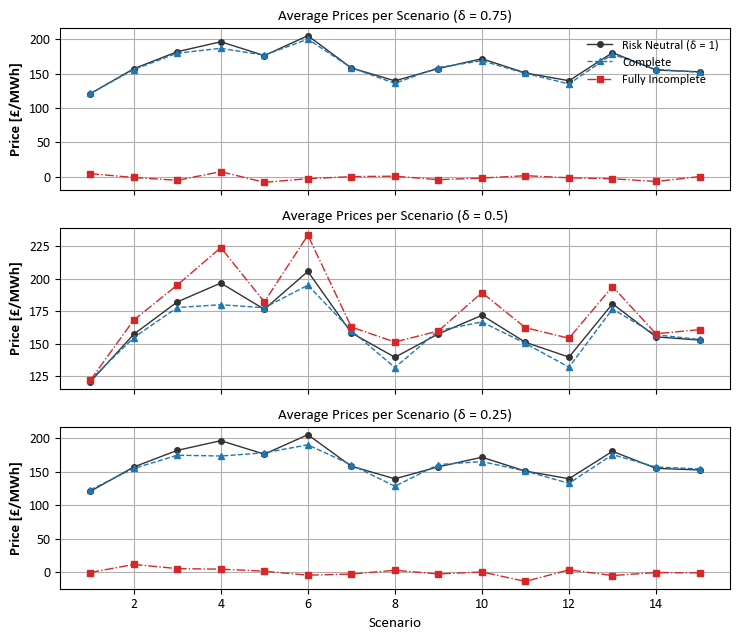

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# === Global font setup ===
rcParams['font.family'] = 'Calibri'
rcParams['axes.labelweight'] = 'bold'

scenarios = np.arange(1, 16)  # 1 to 30

# === Dummy Data (replace with actual) ===
price_risk_neutral = [
    120.8855,  # Scenario 1
    157.3509,  # Scenario 4
    182.1469,  # Scenario 7
    196.5904,  # Scenario 8
    176.4971,  # Scenario 11
    205.4936,  # Scenario 12
    158.4395,  # Scenario 13
    139.7145,  # Scenario 19
    157.6293,  # Scenario 22
    171.8752,  # Scenario 23
    151.2024,  # Scenario 24
    139.8418,  # Scenario 26
    180.7323,  # Scenario 27
    155.3469,  # Scenario 29
    152.9040   # Scenario 30
]
price_complete_075 = [
    121.3414,  # Scenario 1
    156.0683,  # Scenario 4
    180.0571,  # Scenario 7
    187.0488,  # Scenario 8
    177.0477,  # Scenario 11
    200.4178,  # Scenario 12
    158.6189,  # Scenario 13
    136.0942,  # Scenario 19
    159.1142,  # Scenario 22
    169.0297,  # Scenario 23
    150.6668,  # Scenario 24
    135.1878,  # Scenario 26
    178.4729,  # Scenario 27
    156.4974,  # Scenario 29
    152.0604   # Scenario 30
]
price_incomplete_075 = np.random.normal(0, 5, 15)
price_complete_050 = [
    122.2688,  # Scenario 1
    154.8055,  # Scenario 4
    177.8473,  # Scenario 7
    179.9779,  # Scenario 8
    177.7166,  # Scenario 11
    194.9383,  # Scenario 12
    160.1560,  # Scenario 13
    131.8733,  # Scenario 19
    160.1837,  # Scenario 22
    166.8051,  # Scenario 23
    150.3419,  # Scenario 24
    132.1367,  # Scenario 26
    176.7039,  # Scenario 27
    156.8883,  # Scenario 29
    153.3610   # Scenario 30
]
price_incomplete_050 = [
    122.0735,  # Scenario 1
    168.2576,  # Scenario 4
    195.0704,  # Scenario 7
    223.7529,  # Scenario 8
    182.1576,  # Scenario 11
    233.2616,  # Scenario 12
    162.8601,  # Scenario 13
    151.4084,  # Scenario 19
    159.887,  # Scenario 22
    189.293,  # Scenario 23
    162.3917,  # Scenario 24
    154.3101,  # Scenario 26
    193.9301,  # Scenario 27
    157.7401,  # Scenario 29
    160.9143   # Scenario 30
]
price_complete_025 = [
    123.2041,  # Scenario 1
    155.2124,  # Scenario 4
    174.8955,  # Scenario 7
    173.7197,  # Scenario 8
    178.4617,  # Scenario 11
    190.4364,  # Scenario 12
    160.4389,  # Scenario 13
    128.6188,  # Scenario 19
    160.9868,  # Scenario 22
    165.4314,  # Scenario 23
    151.2388,  # Scenario 24
    132.9228,  # Scenario 26
    175.8153,  # Scenario 27
    157.2953,  # Scenario 29
    154.4357   # Scenario 30
]
price_incomplete_025 = np.random.normal(0, 5, 15)
# === Setup ===
fig, axs = plt.subplots(3, 1, figsize=(7.5, 6.5), sharex=True)

# Common styling
line_styles = {
    'Risk Neutral': '-',
    'Complete': '--',
    'Fully Incomplete': '-.'
}
markers = {
    'Risk Neutral': {'marker': 'o', 'label': 'Risk Neutral (δ = 1)'},
    'Complete': {'marker': '^', 'label': 'Complete'},
    'Fully Incomplete': {'marker': 's', 'label': 'Fully Incomplete'}
}
colors = {
    'Risk Neutral': '#333333',
    'Complete': '#1f77b4',   
    'Fully Incomplete': '#d62728'  
}

def plot_lines(ax, delta, comp, incomp):
    ax.plot(scenarios, price_risk_neutral,
            linewidth=1,
            linestyle=line_styles['Risk Neutral'],
            color=colors['Risk Neutral'],
            marker=markers['Risk Neutral']['marker'],
            markersize=4,
            label=markers['Risk Neutral']['label'])

    ax.plot(scenarios, comp,
            linewidth=1,
            linestyle=line_styles['Complete'],
            color=colors['Complete'],
            marker=markers['Complete']['marker'],
            markersize=4,
            label=markers['Complete']['label'])

    ax.plot(scenarios, incomp,
            linewidth=1,
            linestyle=line_styles['Fully Incomplete'],
            color=colors['Fully Incomplete'],
            marker=markers['Fully Incomplete']['marker'],
            markersize=4,
            label=markers['Fully Incomplete']['label'])
    ax.set_ylabel("Price [$/MWh]", fontsize=11, fontweight='bold')
    ax.set_title(f"Average Prices per Scenario (δ = {delta})", fontsize=11, fontweight='normal')
    ax.grid(True)

# Plot each subplot
plot_lines(axs[0], 0.75, price_complete_075, price_incomplete_075)
plot_lines(axs[1], 0.50, price_complete_050, price_incomplete_050)
plot_lines(axs[2], 0.25, price_complete_025, price_incomplete_025)
axs[2].set_xlabel("Scenario", fontsize=11, fontweight='normal')

# Legend only on top subplot
axs[0].legend(loc='upper right', ncol=1, frameon=False, fontsize=9)

plt.tight_layout()
plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_17040\2218279380.py:258: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 1])


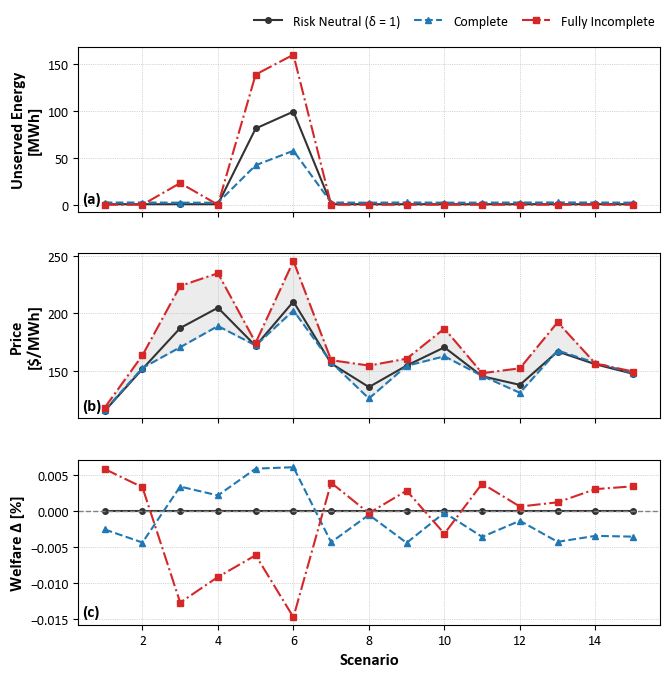

'\n# === Legend only at top subplot ===\n#axs[0].legend( loc=\'upper right\',frameon=True, ncol=1, prop=font_legend)\naxs[0].legend( frameon=True, ncol=1, prop=font_legend)\n\n# === Final Layout ===\nplt.tight_layout()\n\n# === Optional: Save as High-Res PDF ===\n# plt.savefig("market_comparison.pdf", dpi=300, bbox_inches=\'tight\')\n\nplt.show()\n'

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
from matplotlib.font_manager import FontProperties
from matplotlib import gridspec

# === Global font setup ===
rcParams['font.family'] = 'Calibri'
rcParams['text.usetex'] = False
rcParams['axes.labelweight'] = 'bold'

# === Font Settings ===
font_label = {'fontsize': 12, 'fontweight': 'bold'}
font_tick = {'labelsize': 10}
font_legend = FontProperties(size=10)


scenarios = np.arange(1, 16)  # 1 to 30

# === Dummy Data (replace with actual) ===
price_risk_neutral = [
    115.3241,  # scenario 1
    151.7462,  # scenario 4
    187.3067,  # scenario 7
    204.9442,  # scenario 8
    171.7689,  # scenario 11
    210.3167,  # scenario 12
    156.5636,  # scenario 13
    136.0773,  # scenario 19
    154.7260,  # scenario 22
    170.5634,  # scenario 23
    145.4769,  # scenario 24
    137.9820,  # scenario 26
    166.9231,  # scenario 27
    155.8754,  # scenario 29
    147.5805   # scenario 30
]

price_complete_050 = [
    115.8506,  # scenario 1
    152.6653,  # scenario 4
    170.6475,  # scenario 7
    189.0635,  # scenario 8
    172.1956,  # scenario 11
    202.5322,  # scenario 12
    157.5566,  # scenario 13
    126.1553,  # scenario 19
    154.5459,  # scenario 22
    162.7749,  # scenario 23
    145.8053,  # scenario 24
    131.0895,  # scenario 26
    167.8068,  # scenario 27
    157.1579,  # scenario 29
    148.08     # scenario 30
]
price_incomplete_050 = [
    118.1738,  # scenario 1
    163.6717,  # scenario 4
    223.8874,  # scenario 7
    234.8632,  # scenario 8
    174.5603,  # scenario 11
    245.5406,  # scenario 12
    159.4418,  # scenario 13
    154.743,   # scenario 19
    160.7276,  # scenario 22
    186.8861,  # scenario 23
    148.138,   # scenario 24
    152.3618,  # scenario 26
    192.3764,  # scenario 27
    156.4972,  # scenario 29
    149.5468   # scenario 30
]

UE_risk_neutral = [
    0.5495750120661356,   # scenario 1
    0.5515055328447573,   # scenario 4
    0.5425976507169707,   # scenario 7
    0.5465379667337231,   # scenario 8
    81.40770473902606,    # scenario 11
    99.44011849837761,    # scenario 12
    0.5515074199625261,   # scenario 13
    0.5396920458501455,   # scenario 19
    0.5627324277737245,   # scenario 22
    0.5465401655659434,   # scenario 23
    0.546528231928356,    # scenario 24
    0.5495814375533499,   # scenario 26
    0.5627359621193122,   # scenario 27
    0.5495855298005097,   # scenario 29
    0.5465286090229355    # scenario 30
]
UE_complete_050 = [
    2.3538994426442343,   # scenario 1
    2.362282707439469,    # scenario 4
    2.179644811802099,    # scenario 7
    2.195133012438042,    # scenario 8
    42.155166863047725,   # scenario 11
    57.62237286160468,    # scenario 12
    2.3623481904485786,   # scenario 13
    2.167926950225862,    # scenario 19
    2.406230993015221,    # scenario 22
    2.19521898292723,     # scenario 23
    2.2327417514534744,   # scenario 24
    2.354278135366151,    # scenario 26
    2.4065610837190334,   # scenario 27
    2.354793851685642,    # scenario 29
    2.195418238878716     # scenario 30
]
UE_incomplete_050 = [
    2.5140701893633377e-6,  # scenario 1
    2.526949060666084e-6,   # scenario 4
    23.11892352454175,      # scenario 7
    2.5481313201680678e-6,  # scenario 8
    139.0226085774598,      # scenario 11
    160.1552041559521,      # scenario 12
    2.5252026816247053e-6,  # scenario 13
    2.543327958903774e-6,   # scenario 19
    2.5264029801519428e-6,  # scenario 22
    2.5653959241367374e-6,  # scenario 23
    2.522138828453535e-6,   # scenario 24
    2.5258215643475523e-6,  # scenario 26
    2.534588851688113e-6,   # scenario 27
    2.5234215215164113e-6,  # scenario 29
    2.5222242143740914e-6   # scenario 30
]
W_risk_neutral = [
    4.7433049169437e9,  # scenario 1
    4.7533189484796e9,  # scenario 4
    4.6756672412517e9,  # scenario 7
    4.7062108885156e9,  # scenario 8
    4.6774341507972e9,  # scenario 11
    4.6747515898190e9,  # scenario 12
    4.7522744792195e9,  # scenario 13
    4.6567231724057e9,  # scenario 19
    4.8475017365362e9,  # scenario 22
    4.7085406602343e9,  # scenario 23
    4.7120681272609e9,  # scenario 24
    4.7407212405125e9,  # scenario 26
    4.8436706145161e9,  # scenario 27
    4.7366893390453e9,  # scenario 29
    4.7114255793990e9   # scenario 30
]
W_complete_050 = [
    4.7431837883927e9,  # scenario 1
    4.7531112893712e9,  # scenario 4
    4.6758266787400e9,  # scenario 7
    4.7063135485125e9,  # scenario 8
    4.6777104038835e9,  # scenario 11
    4.6750367776409e9,  # scenario 12
    4.7520687257248e9,  # scenario 13
    4.6566993705621e9,  # scenario 19
    4.8472879424445e9,  # scenario 22
    4.7085305462037e9,  # scenario 23
    4.7118994202132e9,  # scenario 24
    4.7406575764312e9,  # scenario 26
    4.8434636664610e9,  # scenario 27
    4.7365262365139e9,  # scenario 29
    4.7112583164472e9   # scenario 30
]
W_incomplete_050 = [
    4.7435822470965e9,  # scenario 1
    4.7534763697912e9,  # scenario 4
    4.6750726151701e9,  # scenario 7
    4.7057797839759e9,  # scenario 8
    4.6771472203094e9,  # scenario 11
    4.6740619137557e9,  # scenario 12
    4.7524616245611e9,  # scenario 13
    4.6567099215696e9,  # scenario 19
    4.8476395604354e9,  # scenario 22
    4.7083926791498e9,  # scenario 23
    4.7122485206851e9,  # scenario 24
    4.7407511877631e9,  # scenario 26
    4.8437298795538e9,  # scenario 27
    4.7368339258108e9,  # scenario 29
    4.711588018414e9    # scenario 30
]

# === Styling Definitions ===
line_styles = {
    'Risk Neutral': '-',
    'Complete': '--',
    'Fully Incomplete': '-.'
}
markers = {
    'Risk Neutral': {'marker': 'o'},
    'Complete': {'marker': '^'},
    'Fully Incomplete': {'marker': 's'}
}
colors = {
    'Risk Neutral': '#333333',
    'Complete': '#1f77b4',
    'Fully Incomplete': '#d62728'
}



# === Setup ===
fig, axs = plt.subplots(3, 1, figsize=(7.5, 7.5), sharex=True, gridspec_kw={'hspace': 0.25})


# === Plot Functions ===
def plot_ue(ax):
    ax.plot(scenarios, UE_risk_neutral, label='Risk Neutral (δ = 1)', **markers['Risk Neutral'], color=colors['Risk Neutral'], linestyle=line_styles['Risk Neutral'], linewidth=1.5, markersize=4)
    ax.plot(scenarios, UE_complete_050, label='Complete', **markers['Complete'], color=colors['Complete'], linestyle=line_styles['Complete'], linewidth=1.5, markersize=4)
    ax.plot(scenarios, UE_incomplete_050, label='Fully Incomplete', **markers['Fully Incomplete'], color=colors['Fully Incomplete'], linestyle=line_styles['Fully Incomplete'], linewidth=1.5, markersize=4)
    #ax.set_yscale('log')
    #ax.set_ylim(1e-6, 1e3)
    ax.set_ylabel("Unserved Energy\n[MWh]", **font_label)
    ax.tick_params(axis='both', **font_tick)
    ax.grid(True, which='both', linestyle=':', linewidth=0.5)

def plot_price_with_band(ax):
    ax.plot(scenarios, price_risk_neutral, label='Risk Neutral (δ = 1)', **markers['Risk Neutral'], color=colors['Risk Neutral'], linestyle=line_styles['Risk Neutral'], linewidth=1.5, markersize=4)
    ax.plot(scenarios, price_complete_050, label='Complete', **markers['Complete'], color=colors['Complete'], linestyle=line_styles['Complete'], linewidth=1.5, markersize=4)
    ax.plot(scenarios, price_incomplete_050, label='Fully Incomplete', **markers['Fully Incomplete'], color=colors['Fully Incomplete'], linestyle=line_styles['Fully Incomplete'], linewidth=1.5, markersize=4)
    lower = np.minimum(price_complete_050, price_incomplete_050)
    upper = np.maximum(price_complete_050, price_incomplete_050)
    ax.fill_between(scenarios, lower, upper, color='gray', alpha=0.15)
    ax.set_ylabel("Price\n[$/MWh]", **font_label)
    ax.tick_params(axis='both', **font_tick)
    ax.grid(True, linestyle=':', linewidth=0.5)

def plot_welfare_diff(ax):
    diff_risk = (np.array(W_risk_neutral) - np.array(W_risk_neutral)) / np.array(W_risk_neutral) * 100
    diff_complete = (np.array(W_complete_050) - np.array(W_risk_neutral)) / np.array(W_risk_neutral) * 100
    diff_incomplete = (np.array(W_incomplete_050) - np.array(W_risk_neutral)) / np.array(W_risk_neutral) * 100

    ax.plot(scenarios, diff_risk, label='Risk Neutral (δ = 1)', **markers['Risk Neutral'], color=colors['Risk Neutral'], linestyle=line_styles['Risk Neutral'], linewidth=1.5, markersize=4)
    ax.plot(scenarios, diff_complete, label='Complete', **markers['Complete'], color=colors['Complete'], linestyle=line_styles['Complete'], linewidth=1.5, markersize=4)
    ax.plot(scenarios, diff_incomplete, label='Fully Incomplete', **markers['Fully Incomplete'], color=colors['Fully Incomplete'], linestyle=line_styles['Fully Incomplete'], linewidth=1.5, markersize=4)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_ylabel("Welfare Δ [%]", **font_label)
    ax.set_xlabel("Scenario", **font_label)
    ax.tick_params(axis='both', **font_tick)
    ax.grid(True, linestyle=':', linewidth=0.5)

# === Plot Data ===
plot_ue(axs[0])
plot_price_with_band(axs[1])
plot_welfare_diff(axs[2])

# === Add Subplot Labels (a), (b), (c) ===
labels = ['(a)', '(b)', '(c)']
for i, ax in enumerate(axs):
    ax.text(0.007, 0.12, labels[i], transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')

# === Collect Unique Legend Items ===
lines_labels = [ax.get_legend_handles_labels() for ax in axs]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
unique = dict(zip(labels, lines))  # Remove duplicates

# === Add Legend at Top-Right in 3 Columns ===
fig.legend(unique.values(), unique.keys(),
           loc='upper right', bbox_to_anchor=(0.91, 0.94),
           frameon=False, prop=font_legend, ncol=3, columnspacing=1.0)

# === Tight layout without extra margin at top ===
plt.tight_layout(rect=[0, 0, 1, 1])
# plt.savefig("market_comparison_with_legend_outside.pdf", dpi=300, bbox_inches='tight')
plt.savefig("market_comparison.png", dpi=400, bbox_inches='tight')
plt.show()


"""
# === Legend only at top subplot ===
#axs[0].legend( loc='upper right',frameon=True, ncol=1, prop=font_legend)
axs[0].legend( frameon=True, ncol=1, prop=font_legend)

# === Final Layout ===
plt.tight_layout()

# === Optional: Save as High-Res PDF ===
# plt.savefig("market_comparison.pdf", dpi=300, bbox_inches='tight')

plt.show()
"""

C:\Users\user\AppData\Local\Temp\ipykernel_33092\3270032379.py:258: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 1])


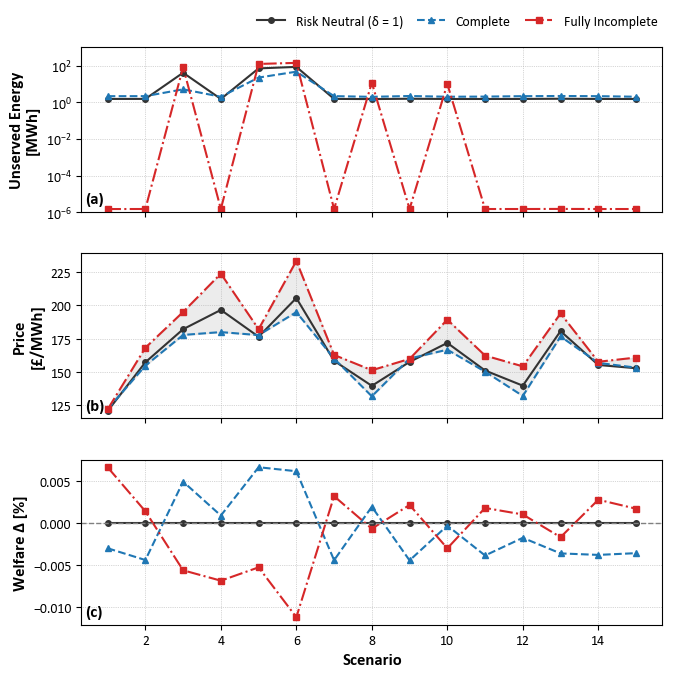

'\n# === Legend only at top subplot ===\n#axs[0].legend( loc=\'upper right\',frameon=True, ncol=1, prop=font_legend)\naxs[0].legend( frameon=True, ncol=1, prop=font_legend)\n\n# === Final Layout ===\nplt.tight_layout()\n\n# === Optional: Save as High-Res PDF ===\n# plt.savefig("market_comparison.pdf", dpi=300, bbox_inches=\'tight\')\n\nplt.show()\n'

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
from matplotlib.font_manager import FontProperties
from matplotlib import gridspec

# === Global font setup ===
rcParams['font.family'] = 'Calibri'
rcParams['text.usetex'] = False
rcParams['axes.labelweight'] = 'bold'

# === Font Settings ===
font_label = {'fontsize': 12, 'fontweight': 'bold'}
font_tick = {'labelsize': 10}
font_legend = FontProperties(size=10)


scenarios = np.arange(1, 16)  # 1 to 30

# === Dummy Data (replace with actual) ===
price_risk_neutral = [
]

price_complete_050 = [
]
price_incomplete_050 = [
]

UE_risk_neutral = [
]
UE_complete_050 = [
]
UE_incomplete_050 = [
]
W_risk_neutral = [
]
W_complete_050 = [
]
W_incomplete_050 = [
]

# === Styling Definitions ===
line_styles = {
    'Risk Neutral': '-',
    'Complete': '--',
    'Fully Incomplete': '-.'
}
markers = {
    'Risk Neutral': {'marker': 'o'},
    'Complete': {'marker': '^'},
    'Fully Incomplete': {'marker': 's'}
}
colors = {
    'Risk Neutral': '#333333',
    'Complete': '#1f77b4',
    'Fully Incomplete': '#d62728'
}



# === Setup ===
fig, axs = plt.subplots(3, 1, figsize=(7.5, 7.5), sharex=True, gridspec_kw={'hspace': 0.25})


# === Plot Functions ===
def plot_ue(ax):
    ax.plot(scenarios, UE_risk_neutral, label='Risk Neutral (δ = 1)', **markers['Risk Neutral'], color=colors['Risk Neutral'], linestyle=line_styles['Risk Neutral'], linewidth=1.5, markersize=4)
    ax.plot(scenarios, UE_complete_050, label='Complete', **markers['Complete'], color=colors['Complete'], linestyle=line_styles['Complete'], linewidth=1.5, markersize=4)
    ax.plot(scenarios, UE_incomplete_050, label='Fully Incomplete', **markers['Fully Incomplete'], color=colors['Fully Incomplete'], linestyle=line_styles['Fully Incomplete'], linewidth=1.5, markersize=4)
    ax.set_yscale('log')
    ax.set_ylim(1e-6, 1e3)
    ax.set_ylabel("Unserved Energy\n[MWh]", **font_label)
    ax.tick_params(axis='both', **font_tick)
    ax.grid(True, which='both', linestyle=':', linewidth=0.5)

def plot_price_with_band(ax):
    ax.plot(scenarios, price_risk_neutral, label='Risk Neutral (δ = 1)', **markers['Risk Neutral'], color=colors['Risk Neutral'], linestyle=line_styles['Risk Neutral'], linewidth=1.5, markersize=4)
    ax.plot(scenarios, price_complete_050, label='Complete', **markers['Complete'], color=colors['Complete'], linestyle=line_styles['Complete'], linewidth=1.5, markersize=4)
    ax.plot(scenarios, price_incomplete_050, label='Fully Incomplete', **markers['Fully Incomplete'], color=colors['Fully Incomplete'], linestyle=line_styles['Fully Incomplete'], linewidth=1.5, markersize=4)
    lower = np.minimum(price_complete_050, price_incomplete_050)
    upper = np.maximum(price_complete_050, price_incomplete_050)
    ax.fill_between(scenarios, lower, upper, color='gray', alpha=0.15)
    ax.set_ylabel("Price\n[$/MWh]", **font_label)
    ax.tick_params(axis='both', **font_tick)
    ax.grid(True, linestyle=':', linewidth=0.5)

def plot_welfare_diff(ax):
    diff_risk = (np.array(W_risk_neutral) - np.array(W_risk_neutral)) / np.array(W_risk_neutral) * 100
    diff_complete = (np.array(W_complete_050) - np.array(W_risk_neutral)) / np.array(W_risk_neutral) * 100
    diff_incomplete = (np.array(W_incomplete_050) - np.array(W_risk_neutral)) / np.array(W_risk_neutral) * 100

    ax.plot(scenarios, diff_risk, label='Risk Neutral (δ = 1)', **markers['Risk Neutral'], color=colors['Risk Neutral'], linestyle=line_styles['Risk Neutral'], linewidth=1.5, markersize=4)
    ax.plot(scenarios, diff_complete, label='Complete', **markers['Complete'], color=colors['Complete'], linestyle=line_styles['Complete'], linewidth=1.5, markersize=4)
    ax.plot(scenarios, diff_incomplete, label='Fully Incomplete', **markers['Fully Incomplete'], color=colors['Fully Incomplete'], linestyle=line_styles['Fully Incomplete'], linewidth=1.5, markersize=4)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_ylabel("Welfare Δ [%]", **font_label)
    ax.set_xlabel("Scenario", **font_label)
    ax.tick_params(axis='both', **font_tick)
    ax.grid(True, linestyle=':', linewidth=0.5)

# === Plot Data ===
plot_ue(axs[0])
plot_price_with_band(axs[1])
plot_welfare_diff(axs[2])

# === Add Subplot Labels (a), (b), (c) ===
labels = ['(a)', '(b)', '(c)']
for i, ax in enumerate(axs):
    ax.text(0.007, 0.12, labels[i], transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')

# === Collect Unique Legend Items ===
lines_labels = [ax.get_legend_handles_labels() for ax in axs]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
unique = dict(zip(labels, lines))  # Remove duplicates

# === Add Legend at Top-Right in 3 Columns ===
fig.legend(unique.values(), unique.keys(),
           loc='upper right', bbox_to_anchor=(0.91, 0.94),
           frameon=False, prop=font_legend, ncol=3, columnspacing=1.0)

# === Tight layout without extra margin at top ===
plt.tight_layout(rect=[0, 0, 1, 1])
# plt.savefig("market_comparison_with_legend_outside.pdf", dpi=300, bbox_inches='tight')
plt.savefig("market_comparison.png", dpi=400, bbox_inches='tight')
plt.show()


"""
# === Legend only at top subplot ===
#axs[0].legend( loc='upper right',frameon=True, ncol=1, prop=font_legend)
axs[0].legend( frameon=True, ncol=1, prop=font_legend)

# === Final Layout ===
plt.tight_layout()

# === Optional: Save as High-Res PDF ===
# plt.savefig("market_comparison.pdf", dpi=400, bbox_inches='tight')

plt.show()
"""

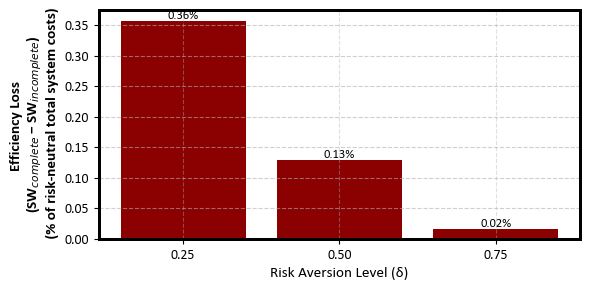

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
from matplotlib.ticker import PercentFormatter

# === Global font setup ===
rcParams['font.family'] = 'Calibri'
rcParams['axes.labelweight'] = 'bold'

# === Replace these with your actual values ===
deltas = [0.25, 0.5, 0.75]
riskneutral_sw = 4.729353512329049e9
sw_complete = [4.699031359803693e9, 4.709140350445262e9, 4.71923429212195e9]       # example social welfare values
sw_incomplete = [4.698587852200662e9, 4.708974276447182e9,4.719302206668786e9 ]      # example values

#like adam's paper (risk adjusted welfare complete - risk adjusted welfare complete incomplete)/total costs
riskneutral_sw = 87911701.85#/2.5
sw_complete = [4.699031359803693e9,   4.709140350445262e9, 4.71923429212195e9]       # example social welfare values
sw_incomplete = [4.698717192323164e9, 4.709027016274159e9,4.7192202206668786e9 ] 


eff_loss_abs = np.array(sw_complete) - np.array(sw_incomplete)

eff_loss_pct = (eff_loss_abs / riskneutral_sw) * 100.0 


# === Plotting ===
fig, ax = plt.subplots(figsize=(6, 3))

bars = ax.bar(deltas, eff_loss_pct, width=0.2, color='#8B0000', edgecolor='black')

# Labels and grid
ax.set_ylabel("Efficiency Loss \n(SW$_{complete}$ − SW$_{incomplete}$)\n (% of risk-neutral total system costs)", fontsize=11, fontweight='bold')
ax.set_xlabel("Risk Aversion Level (δ)", fontsize=11, fontweight='normal')
ax.set_xticks(deltas)
ax.set_xticklabels([f"{d:.2f}" for d in deltas])
#ax.set_title("Social Welfare (SW) vs risk-aversion", fontsize=11)
#ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))

# Gridlines on both axes
ax.grid(True, axis='y', linestyle='--', alpha=0.6)
ax.grid(True, axis='x', linestyle='--', alpha=0.4)

# Bar labels (e.g., 0.003%)
for rect, val in zip(bars, eff_loss_pct):
    y = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, y,
            f"{val:.2f}%", ha='center', va='bottom', fontsize=9)
    
plt.tight_layout()
plt.savefig("socialwelfare_new.png", dpi=400, bbox_inches='tight')
plt.show()


In [92]:
import pandas as pd

# === Load your actual files ===
cf = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\data_final\f672\concatenated_capacity_factors_672_30yr_new_lf.csv")
demand = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\data_final\f672\concatenated_load_profiles_672_30yr_new.csv")
weights = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\data_final\f672\concatenated_weights_672_30yr_new.csv")

total_scenarios = [19, 12, 7, 11, 23, 8, 30, 24, 1, 26, 29, 13, 4, 22, 27]

# Keep only the total scenarios
cf   = cf[cf["O"].isin(total_scenarios)].copy()
demand = demand[demand["O"].isin(total_scenarios)].copy()
wt = weights[weights["O"].isin(total_scenarios)].copy()

# Pivot CF to wide: columns become PV, Wind_Onshore, Wind_Offshore
cfw = cf.pivot_table(index=["O","T"], columns="G", values="value").reset_index()

# Merge weights
wt = wt.rename(columns={"value":"weight"})
df = cfw.merge(wt, on=["O","T"], how="inner")
demand =demand.rename(columns={"value":"demand"})

techs = [c for c in ["PV", "Wind_Onshore", "Wind_Offshore"] if c in df.columns]
X1=0.77
X2=1.1
X3=1.45
# --- Apply multipliers with cap at 1.0 ---
mult = pd.Series({"PV": X1, "Wind_Onshore": X2, "Wind_Offshore": X3})
df[techs] = df[techs].mul(mult, axis=1).clip(upper=1.0)

# --- Time-weighted CF per scenario, then overall (equiprobable) ---
num = df[techs].mul(df["weight"], axis=0).groupby(df["O"]).sum()
den = df.groupby("O")["weight"].sum()
per_scn_cf = num.div(den, axis=0)          # CF_{G,o} = sum_t w*cf / sum_t w
overall_cf = per_scn_cf.mean()             # simple average across scenarios

print("Overall average capacity factors (after multipliers, capped at 1.0):")
for tech, val in overall_cf.items():
    print(f"  {tech}: {val:.4f}")
    

# === Compute weighted metrics per scenario ===
#scenario_stats = []

#for scenario in cfw["O"].unique():
#    df_s = cfw[cfw["O"] == scenario]
#    weight_sum = df_s["weight"].sum()

#    windon_weighted = ((df_s["Wind_Onshore"]) * df_s["weight"]).sum() / weight_sum
#    windoff_weighted = ((df_s["Wind_Offshore"]) * df_s["weight"]).sum() / weight_sum
#    pv_weighted = (df_s["PV"] * df_s["weight"]).sum() / weight_sum
#    demand_weighted = (df_s["demand"] * df_s["weight"]).sum()

#    scenario_stats.append({
#        "scenario": scenario,
#        "windon_weighted": windon_weighted,
#        "windoff_weighted": windoff_weighted,
#        "pv_weighted": pv_weighted,
#        "demand_weighted": demand_weighted
#    })

#stats_df = pd.DataFrame(scenario_stats)
#print(stats_df)
#stats_df.to_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Comparison_central_planner_ADMM\stats_for_scenario.csv", index=False)



Overall average capacity factors (after multipliers, capped at 1.0):
  PV: 0.0836
  Wind_Onshore: 0.3204
  Wind_Offshore: 0.5296


                Mean  Median    Min    Max  Std. dev.
PV             0.167   0.168  0.161  0.174      0.004
Wind_Onshore   0.147   0.147  0.119  0.169      0.013
Wind_Offshore  0.338   0.339  0.281  0.380      0.024


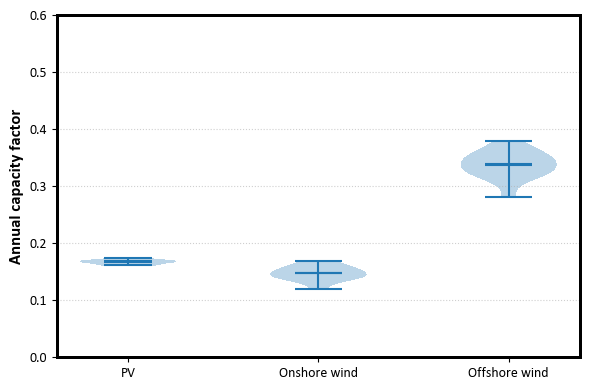

In [179]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# === Global font setup ===
rcParams['font.family'] = 'Calibri'
rcParams['axes.labelweight'] = 'bold'

# === Load files (adjust paths if needed) ===
cf = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\data_final\ffff672\concatenated_capacity_factors_40yr_lf.csv")
demand = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\data_final\ffff672\concatenated_load_profiles_40yr.csv")
weights = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\data_final\ffff672\concatenated_weights_40yr.csv")

# Use your chosen scenarios
total_scenarios = [13, 38, 19, 6, 7, 15, 22, 23, 1, 30, 40, 29, 31, 2, 16]

# Filter
cf = cf[cf["O"].isin(total_scenarios)].copy()
weights = weights[weights["O"].isin(total_scenarios)].copy()

# Pivot CF to wide [PV, Wind_Onshore, Wind_Offshore]
cf_wide = cf.pivot_table(index=["O","T"], columns="G", values="value").reset_index()

# Merge weights (rename for clarity)
wt = weights.rename(columns={"value":"weight"})
df = cf_wide.merge(wt, on=["O","T"], how="inner")

# Keep only the technologies present
techs = [c for c in ["PV", "Wind_Onshore", "Wind_Offshore"] if c in df.columns]

# Optional multipliers + cap at 1.0
X1, X2, X3 = 1.0, 1.0, 1.0
mult = pd.Series({"PV": X1, "Wind_Onshore": X2, "Wind_Offshore": X3})
for col in techs:
    if col in mult.index:
        df[col] = (df[col] * mult[col]).clip(upper=1.0)

#print(df.columns)

# === Time-weighted annual CF per scenario ===
# CF_{G,o} = sum_t w_t * cf_{G,t,o} / sum_t w_t
w_sum = df.groupby("O")["weight"].sum()
num   = df[techs].mul(df["weight"], axis=0).groupby(df["O"]).sum()
per_scn_cf = num.div(w_sum, axis=0).reset_index().rename(columns={"O":"scenario"})

# === Summary stats table (for thesis / appendix) ===
summary = per_scn_cf[techs].agg(["mean","median","min","max","std"]).T
summary = summary.rename(columns={
    "mean":"Mean", "median":"Median", "min":"Min", "max":"Max", "std":"Std. dev."
})
summary_rounded = summary.round(3)
print(summary_rounded)

# Save if useful
#summary_rounded.to_csv(r"C:\Users\user\Desktop\per_scenario_CF_summary.csv")
#with open(r"C:\Users\user\Desktop\per_scenario_CF_summary.tex", "w") as f:
#    f.write(summary_rounded.to_latex(escape=False))

# === Violin plot (matplotlib only; no custom colors) ===
data_list = [per_scn_cf[t].values for t in techs]

fig, ax = plt.subplots(figsize=(6,4))
ax.violinplot(dataset=data_list, showmeans=True, showmedians=True, showextrema=True)

# X ticks / labels
ax.set_xticks(range(1, len(techs)+1))
# Nicer labels for wind
pretty = {"PV":"PV", "Wind_Onshore":"Onshore wind", "Wind_Offshore":"Offshore wind"}
ax.set_xticklabels([pretty.get(t, t) for t in techs])

# Labels (as you requested)
ax.set_xlabel("", fontsize=11, fontweight='normal')
ax.set_ylabel("Annual capacity factor", fontsize=12, fontweight='bold')

# Make limits sensible for CFs (0–1). Adjust if you prefer tighter bounds.
ax.set_ylim(0.0, 0.6)

# Clean look
ax.grid(True, axis='y', linestyle=':', linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()



=== Time-weighted annual CF per (G,O) ===
            G  O       CF
           PV  1 0.110740
           PV  4 0.106423
           PV  7 0.109617
           PV  8 0.108155
           PV 11 0.105158
           PV 12 0.108785
           PV 13 0.104965
           PV 19 0.108576
           PV 22 0.109539
           PV 23 0.105687
           PV 24 0.110822
           PV 26 0.110522
           PV 27 0.109830
           PV 29 0.110390
           PV 30 0.110095
Wind_Offshore  1 0.429739
Wind_Offshore  4 0.383781
Wind_Offshore  7 0.377780
Wind_Offshore  8 0.358068
Wind_Offshore 11 0.390586
Wind_Offshore 12 0.366994
Wind_Offshore 13 0.383099
Wind_Offshore 19 0.411622
Wind_Offshore 22 0.387050
Wind_Offshore 23 0.366802
Wind_Offshore 24 0.381923
Wind_Offshore 26 0.406412
Wind_Offshore 27 0.357038
Wind_Offshore 29 0.358492
Wind_Offshore 30 0.362297
 Wind_Onshore  1 0.343871
 Wind_Onshore  4 0.297074
 Wind_Onshore  7 0.287300
 Wind_Onshore  8 0.275733
 Wind_Onshore 11 0.288654
 Wind_Onshore 12 0.26

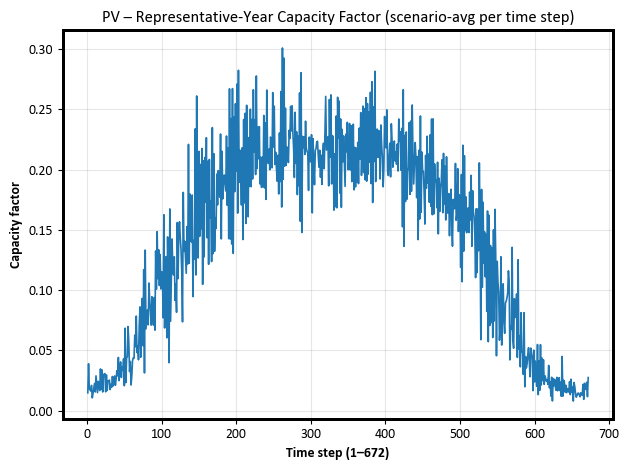

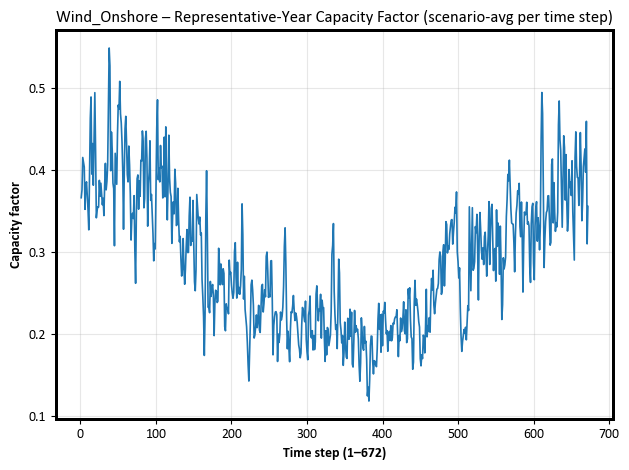

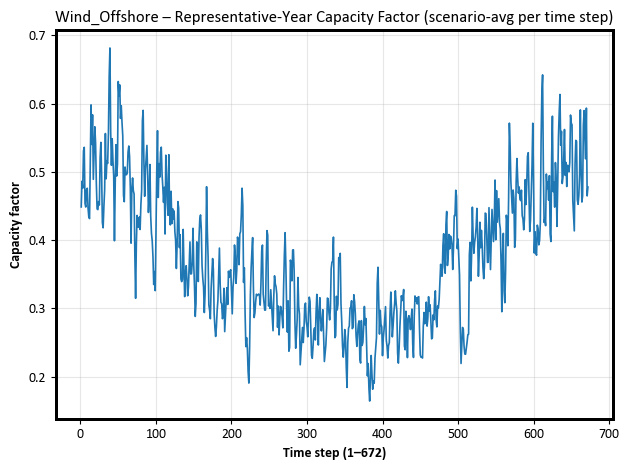

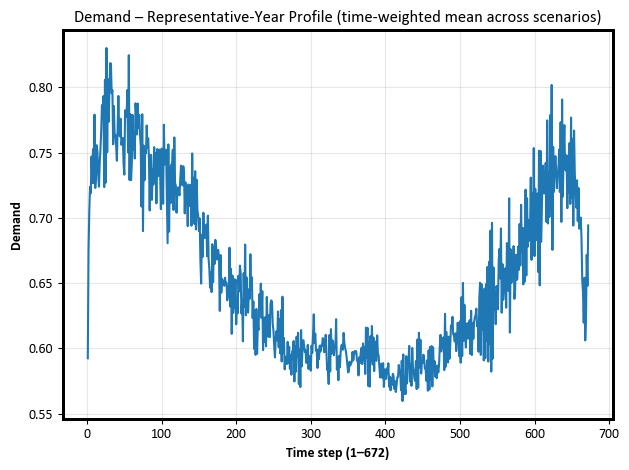

In [12]:
import numpy as np
import pandas as pd
from pathlib import Path

# --- File paths (as provided) ---
path_cf = Path(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\data_final\f672\concatenated_capacity_factors_672_30yr_new_lf.csv")
path_wt = Path(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\data_final\f672\concatenated_weights_672_30yr_new.csv")
path_demand = Path(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\data_final\f672\concatenated_load_profiles_672_30yr_new.csv") 

# --- Scenario sets ---
SCENARIOS_ALL  = [11,12,13,19,1,22,23,24,26,27,29,30,4,7,8]
SCENARIOS_TAIL = [11,12,19,23,24,30,7,8]

# --- Read data ---
cf = pd.read_csv(path_cf)  # expects columns: O, T, G, value
wt = pd.read_csv(path_wt)  # expects columns: O, T, value
demand = pd.read_csv(path_demand)

# Standardize column names we use below
cf = cf.rename(columns={'value': 'cf'})
wt = wt.rename(columns={'value': 'w'})
demand = demand.rename(columns={'value': 'd'})


# --- Filter to your scenario set ---
cf = cf[cf['O'].isin(SCENARIOS_ALL)].copy()
wt = wt[wt['O'].isin(SCENARIOS_ALL)].copy()
demand = demand[demand['O'].isin(SCENARIOS_ALL)].copy()

# --- Merge on (O,T) to bring time weights alongside capacity factors ---
df = cf.merge(wt, on=['O', 'T'], how='inner')

# --- Compute time-weighted annual CF per technology & scenario ---
# Create product and sum by (G,O): CF_{G,o} = sum_t w * cf / sum_t w
df['wcf'] = df['w'] * df['cf']
agg = df.groupby(['G','O'], as_index=False).agg(num=('wcf', 'sum'), den=('w', 'sum'))
agg['CF'] = agg['num'] / agg['den']
cf_go = agg[['G','O','CF']].copy()

# --- Helper: summarize distribution across scenarios for each technology ---
def summarize_cf(cv_df: pd.DataFrame, scenarios: list[int], label: str) -> pd.DataFrame:
    d = cv_df[cv_df['O'].isin(scenarios)].copy()

    def pctl(x, q):
        return float(np.percentile(x, q))

    rows = []
    for g, sub in d.groupby('G'):
        x = sub['CF'].to_numpy()
        mean = float(np.mean(x))
        std  = float(np.std(x, ddof=1)) if len(x) > 1 else 0.0
        cv   = std / mean if mean != 0 else np.nan
        p25  = pctl(x, 25)
        p50  = pctl(x, 50)  # median
        p75  = pctl(x, 75)
        # Downside mean (worst 50%): average of values <= median
        downside_mean = float(np.mean(x[x <= p50]))
        downside_mean_ratio = downside_mean / mean if mean != 0 else np.nan

        rows.append({
            'set': label, 'G': g, 'N': len(x),
            'mean': mean, 'std': std, 'cv': cv,
            'p25': p25, 'p50_median': p50, 'p75': p75,
            'downside_mean': downside_mean,
            'downside_mean_ratio': downside_mean_ratio,
            'min': float(np.min(x)), 'max': float(np.max(x))
        })
    cols = ['set','G','N','mean','std','cv','p25','p50_median','p75',
            'downside_mean','downside_mean_ratio','min','max']
    return pd.DataFrame(rows)[cols].sort_values(['G'])

summary_all  = summarize_cf(cf_go, SCENARIOS_ALL,  label='ALL')
summary_tail = summarize_cf(cf_go, SCENARIOS_TAIL, label='TAIL')

# --- Output results ---
print("\n=== Time-weighted annual CF per (G,O) ===")
print(cf_go.sort_values(['G','O']).to_string(index=False))

print("\n=== Summary across ALL scenarios (CVaR-50 aligned) ===")
print(summary_all.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

print("\n=== Summary across TAIL scenarios (CVaR-50 aligned) ===")
print(summary_tail.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

# --- Optional saves ---
# out_dir = path_cf.parent
# cf_go.to_csv(out_dir / "cf_weighted_by_scenario.csv", index=False)
# summary_all.to_csv(out_dir / "cf_summary_ALL_cvar50.csv", index=False)
# summary_tail.to_csv(out_dir / "cf_summary_TAIL_cvar50.csv", index=False)

# --- Optional: quick interpretation printouts (aligned with CVaR-50) ---
for g in cf_go['G'].unique():
    m_all  = summary_all.loc[summary_all['G']==g, 'mean'].item()
    med    = summary_all.loc[summary_all['G']==g, 'p50_median'].item()
    dmr    = summary_all.loc[summary_all['G']==g, 'downside_mean_ratio'].item()
    cv     = summary_all.loc[summary_all['G']==g, 'cv'].item()
    print(f"\n{g}: mean={m_all:.4f}, median(p50)={med:.4f}, downside-mean/mean={dmr:.3f}, CV={cv:.3%}")
    
    
    
    
# --- Representative year (mean CF across scenarios for each time step) ---
TECHS = ["PV", "Wind_Onshore", "Wind_Offshore"]

# Average CF across scenarios for each (T, G)
rep_ts = (
    df.groupby(['T', 'G'], as_index=False)
      .agg(cf_mean=('cf', 'mean'))
)

# Pivot to have one column per technology; ensure time steps are ordered
rep_pivot = (
    rep_ts.pivot(index='T', columns='G', values='cf_mean')
          .sort_index()
)

# Representative weights per time step: average across scenarios (from the original wt table)
w_rep = wt.groupby('T', as_index=False).agg(w=('w', 'mean'))

# --- Print time-weighted annual CF for each target tech (optional but handy) ---
print("\n=== Representative-year annual CF (time-weighted across T) ===")
for tech in TECHS:
    if tech not in rep_pivot.columns:
        print(f"{tech}: not found in G")
        continue
    tmp = rep_pivot[[tech]].reset_index().merge(w_rep, on='T', how='inner')
    cf_annual = (tmp['w'] * tmp[tech]).sum() / tmp['w'].sum()
    print(f"{tech}: {cf_annual:.4f}")

# --- Plots: one figure per technology, 672 points each (no specified colors) ---
import matplotlib.pyplot as plt

for tech in TECHS:
    if tech not in rep_pivot.columns:
        continue
    s = rep_pivot[tech].dropna()

    plt.figure()
    plt.plot(s.index.values, s.values, linewidth=1.2)
    plt.title(f"{tech} – Representative-Year Capacity Factor (scenario-avg per time step)")
    plt.xlabel("Time step (1–672)")
    plt.ylabel("Capacity factor")
    #plt.ylim(0, 1)             # CFs are 0–1; remove if you prefer autoscale
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    
# === DEMAND PROFILES PLOT (672 timesteps) ====================================
# Merge to bring weights
dem_w = demand.merge(wt, on=['O', 'T'], how='inner')

# Weighted average demand per T
dem_w['wd'] = dem_w['w'] * dem_w['d']
rep_dem = (
    dem_w.groupby('T', as_index=False)
          .agg(wd_sum=('wd','sum'), w_sum=('w','sum'))
)
rep_dem['d_avg_w'] = rep_dem['wd_sum'] / rep_dem['w_sum']

# --- Plot representative-year demand profile ---
import matplotlib.pyplot as plt

plt.figure()
plt.plot(rep_dem['T'].values, rep_dem['d_avg_w'].values, linewidth=1.5)
plt.title("Demand – Representative-Year Profile (time-weighted mean across scenarios)")
plt.xlabel("Time step (1–672)")
plt.ylabel("Demand")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==============================================================================

Gas Utilisation

In [ ]:
import pandas as pd
import numpy as np

# Load the dispatch and time weight files
dispatch_df = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Complete_markets_risk_averse_central_planner\FINAL_BEFORE_1REVIEW\dispatch_delta_1.0.csv")
time_weight_df = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Complete_markets_risk_averse_central_planner\data_final\f672\concatenated_weights_672_30yr_new.csv")

totalsc = [19, 12, 7, 11, 23, 8, 30, 24, 1, 26, 29, 13, 4, 22, 27]
# Keep only the total scenarios
dispatch_df   = dispatch_df[dispatch_df["Scenario"].isin(totalsc)].copy()
time_weight_df = time_weight_df[time_weight_df["O"].isin(totalsc)].copy()

# Prepare tail scenario set
tail_scenarios = [11,12,19,23,24,7,8,30]

# Merge time weights into dispatch data
time_weight_df = time_weight_df.rename(columns={"T": "Time", "O": "Scenario", "value": "TimeWeight"})
print(dispatch_df.columns)
# Filter for gas generator safely
gas_dispatch_df = dispatch_df.loc[dispatch_df["Generator"].str.lower() == "pv"].copy()

# Ensure correct data type for Scenario
gas_dispatch_df["Scenario"] = gas_dispatch_df["Scenario"].astype(int)

# Merge with time weights
merged_df = gas_dispatch_df.merge(time_weight_df, on=["Time", "Scenario"], how="left")


merged_df["IsTail"] = merged_df["Scenario"].isin(tail_scenarios)

# Compute weighted dispatch
merged_df["WeightedDispatch"] = merged_df["Dispatch"] * merged_df["TimeWeight"]

# Aggregates and gas capacity
tail_dispatch = merged_df.loc[merged_df["IsTail"], "WeightedDispatch"].sum()
non_tail_dispatch = merged_df.loc[~merged_df["IsTail"], "WeightedDispatch"].sum()

total_hours_tail = merged_df.loc[merged_df["IsTail"], "TimeWeight"].sum()
total_hours_non_tail = merged_df.loc[~merged_df["IsTail"], "TimeWeight"].sum()

gas_capacity_mw = 145.73
avg_mw_tail = tail_dispatch / total_hours_tail
avg_mw_non_tail = non_tail_dispatch / total_hours_non_tail
utilization_tail = avg_mw_tail / gas_capacity_mw
utilization_non_tail = avg_mw_non_tail / gas_capacity_mw

print({
    "Tail Dispatch (MWh)": tail_dispatch,
    "Non-Tail Dispatch (MWh)": non_tail_dispatch,
    "Avg MW Tail": avg_mw_tail,
    "Avg MW Non-Tail": avg_mw_non_tail,
    "Utilization Tail (%)": utilization_tail * 100,
    "Utilization Non-Tail (%)": utilization_non_tail * 100
})


Index(['Time', 'Scenario', 'Generator', 'Dispatch'], dtype='object')
{'Tail Dispatch (MWh)': 933428.1874463744, 'Non-Tail Dispatch (MWh)': 826278.1041574932, 'Avg MW Tail': 13.319466145068128, 'Avg MW Non-Tail': 13.474854927552075, 'Utilization Tail (%)': 9.13982443221583, 'Utilization Non-Tail (%)': 9.246452293660932}


In [ ]:
import pandas as pd
import numpy as np

# Load the dispatch and time weight files
df = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\my_hpc_project_riskaverseCON_CPLEX\prices_delta_0.5.csv")
# Group by scenario and compute stats
stats = df.groupby("O")["price"].agg(
    avg_price="mean",
    std_price="std",
    min_price="min",
    max_price="max"
).reset_index()

# Save to a new CSV (optional)
stats.to_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\my_hpc_project_riskaverseCON_CPLEX\scenario_price_stats.csv", index=False)
# Display result
print(stats)

     O   avg_price   std_price    min_price    max_price
0    1  -92.415409  301.631163 -5506.241616     0.002468
1    2  -83.741818   87.115456 -1538.747856     0.000326
2    3 -130.693111  558.311685 -7174.356202     0.001287
3    4  -87.415104   65.158790  -471.985478    -0.000727
4    5  -83.292809  203.042581 -4998.012318     0.000290
5    6  -74.593552   67.137158  -381.861325     0.001177
6    7 -100.731669  373.831197 -8998.617740     0.005556
7    8  109.940133  230.367473     0.001100  2951.112739
8    9   74.022911   67.476439    -0.001404   364.001419
9   10   86.636250  213.793968    -0.000791  5335.802815
10  11   97.956290  304.861787     0.000355  7802.504080
11  12  107.904334  319.004073    -0.002740  5904.166880
12  13   96.568151  148.690778     0.001793  2903.997916
13  14  105.662751  329.077378    -0.001289  7000.894498
14  15  103.087852  349.178257    -0.000272  8284.161060
15  16   93.930756  181.975261     0.001851  4504.922401
16  17   87.523139  201.144475 

C:\Users\user\AppData\Local\Temp\ipykernel_17040\80581793.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
C:\Users\user\AppData\Local\Temp\ipykernel_17040\80581793.py:47: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  ax = sns.violinplot(
C:\Users\user\AppData\Local\Temp\ipykernel_17040\80581793.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['a) $H_{2}$', 'b) Wind Offshore'], fontsize=11)


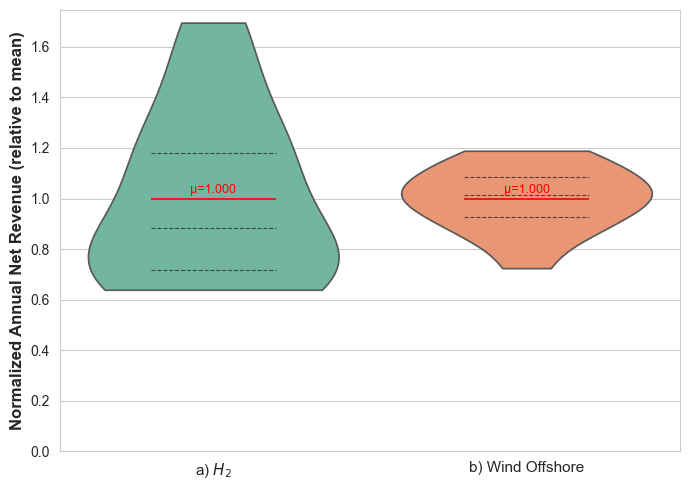

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams

# === Global font setup ===
rcParams['font.family'] = 'Calibri'
rcParams['axes.labelweight'] = 'bold'
sns.set_style("whitegrid")

# === Revenue data ===
ldes_revenue = [
    1161488.501, 1501133.276, 618722.9102, 1119871.887, 655255.6104,
    671269.4626, 1120988.811, 686365.2323, 992130.1527, 854546.4378,
    705607.2075, 723114.2518, 751057.2526, 1641761.313, 1316768.364
]

wind_offshore_revenue = [
    22606753.61, 31285180.89, 27071072.22, 23182890.61, 19351075.09,
    29580673.88, 28451056.3, 25418342, 24119230.21, 31753236.87,
    26276421.33, 26005490.88, 27474021.54, 27974040.29, 30002949.57
]

# === Installed capacity (MW) ===
ldes_capacity_mw = 1.51
wind_capacity_mw = 89.50

# === Normalize revenue per MW ===
ldes_revenue_per_mw = [r / ldes_capacity_mw for r in ldes_revenue]
wind_revenue_per_mw = [r * 1.475859063 / wind_capacity_mw for r in wind_offshore_revenue]

# === Normalize EACH tech by its own total revenue ===
ldes_mean = np.mean(ldes_revenue_per_mw)
wind_mean = np.mean(wind_revenue_per_mw)

ldes_normalized = [r / ldes_mean for r in ldes_revenue_per_mw]
wind_normalized = [r / wind_mean for r in wind_revenue_per_mw]

# === Combine ===
data = pd.DataFrame({
    'Technology': ['H₂'] * 15 + ['Wind Offshore'] * 15,
    'Normalized Revenue': ldes_normalized + wind_normalized
})

# === Plot ===
plt.figure(figsize=(7, 5))
ax = sns.violinplot(
    data=data,
    x="Technology",
    y="Normalized Revenue",
    palette=sns.color_palette("Set2"),
    inner=None,
    cut=0
)

# --- Add stats per tech ---
for i, tech in enumerate(['H₂', 'Wind Offshore']):
    values = data[data['Technology'] == tech]['Normalized Revenue']
    mean = values.mean()
    q25 = values.quantile(0.25)
    q50 = values.median()
    q75 = values.quantile(0.75)

    # Plot lines
    for y in [q25, q50, q75]:
        ax.hlines(y, i - 0.2, i + 0.2, colors='black', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.hlines(mean, i - 0.2, i + 0.2, colors='red', linestyle='-', linewidth=1.2)

    # Mean label
    ax.text(i, mean + 0.01, f"μ={mean:.3f}", ha='center', va='bottom', fontsize=9, color='red')

# === Style ===
ax.set_ylabel("Normalized Annual Net Revenue (relative to mean)", fontsize=12, fontweight='bold')
ax.set_xlabel("")
#ax.set_title("Normalized Net Revenue Distribution by Technology", fontsize=13, weight='bold')
ax.set_xticklabels(['a) $H_{2}$', 'b) Wind Offshore'], fontsize=11)
plt.ylim(0, max(data["Normalized Revenue"]) + 0.05)
plt.tight_layout()
plt.show()

# === Save (optional) ===
# plt.savefig("per_tech_normalized_violin.png", dpi=400, bbox_inches='tight')


C:\Users\user\AppData\Local\Temp\ipykernel_24096\1546393924.py:144: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\user\AppData\Local\Temp\ipykernel_24096\1546393924.py:188: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['a) $H_{2}$', 'b) Wind Offshore', 'c) Wind Onshore', 'd) PV', 'e) Gas', 'f) BESS'], fontsize=11)


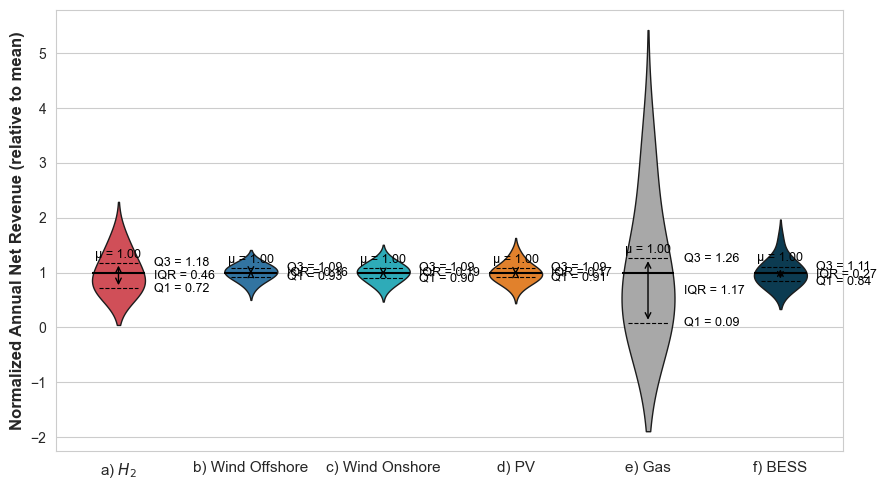

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# === Global font setup ===
rcParams['font.family'] = 'Calibri'
rcParams['axes.labelweight'] = 'bold'
sns.set_style("whitegrid")

# === Revenue data ===
ldes_revenue = [
    1161488.501, 1501133.276, 618722.9102, 1119871.887, 655255.6104,
    671269.4626, 1120988.811, 686365.2323, 992130.1527, 854546.4378,
    705607.2075, 723114.2518, 751057.2526, 1641761.313, 1316768.364
]

wind_offshore_revenue = [
    22606753.61, 31285180.89, 27071072.22, 23182890.61, 19351075.09,
    29580673.88, 28451056.3, 25418342, 24119230.21, 31753236.87,
    26276421.33, 26005490.88, 27474021.54, 27974040.29, 30002949.57
]
wind_onshore_revenue = [
    10158434.57,
    13259977.37,
    11414165.4,
    9767929.437,
    8579439.071,
    12400236.33,
    12287555.29,
    11245713.21,
    10062037.81,
    13715447.77,
    11839543.77,
    11936352.92,
    12562424.15,
    14892888.45,
    13767944.98
]
pv_revenue = [
    17187237.39,
    19876915.26,
    14725351.11,
    13025697.66,
    11439488.64,
    16189238.84,
    17257135.69,
    14682651.7,
    14247039.93,
    17354311.39,
    15701459.31,
    13673750.99,
    15084893.9,
    15689206.77,
    21389868.1
]

gas_revenue = [
    1.5911400586624794e7,
    4.027167001648055e7,
    1.1372735611777306e6,
    1.2900932211750947e7,
    731478.7816373184,
    1.5677495195902176e6,
    1.3302888402892396e7,
    764369.0440078154,
    9.131226842962597e6,
    9.701774160717532e6,
    652432.398808226,
    911422.0936854631,
    4.763277474064108e6,
    3.3087464462166585e7,
    2.9026609797722273e7
]

bess_revenue = [
    5.553270057998465e6,
    5.841978707730084e6,
    4.1205131667567464e6,
    4.841816557309693e6,
    4.205918516463605e6,
    3.507748517927688e6,
    5.280191461208627e6,
    3.8381634870530716e6,
    5.264652075614263e6,
    4.877843936378861e6,
    4.063884898891248e6,
    4.372118064339865e6,
    3.9901711526757064e6,
    7.725518133621426e6,
    5.675414536429983e6
]


# === Installed capacity (MW) ===
ldes_capacity_mw = 1.51
wind_capacity_mw = 89.50
wind_on = 49.73
pvcap = 143.86
gascap = 47.52
besscap = 19.92

# === Normalize revenue per MW ===
ldes_revenue_per_mw = [r / ldes_capacity_mw for r in ldes_revenue]
wind_revenue_per_mw = [r  / wind_capacity_mw for r in wind_offshore_revenue] #* 1.475859063
wind_on_revenue_per_mw = [r / wind_on for r in wind_onshore_revenue]
pv_revenue_per_mw = [r / pvcap for r in pv_revenue]
gas_revenue_per_mw = [r / gascap for r in gas_revenue]
bess_revenue_per_mw = [r / besscap for r in bess_revenue]

# === Normalize each tech by its own mean ===
ldes_mean = np.mean(ldes_revenue_per_mw)
wind_mean = np.mean(wind_revenue_per_mw)
wind_on_mean = np.mean(wind_on_revenue_per_mw)
pv_mean = np.mean(pv_revenue_per_mw)
gas_mean = np.mean(gas_revenue_per_mw)
bess_mean = np.mean(bess_revenue_per_mw)

ldes_normalized = [r / ldes_mean for r in ldes_revenue_per_mw]
wind_normalized = [r / wind_mean for r in wind_revenue_per_mw]
wind_on_normalized = [r / wind_on_mean for r in wind_on_revenue_per_mw]
pv_normalized = [r / pv_mean for r in pv_revenue_per_mw]
gas_normalized = [r / gas_mean for r in gas_revenue_per_mw]
bess_normalized = [r / bess_mean for r in bess_revenue_per_mw]

# === Combine ===
data = pd.DataFrame({
    'Technology': ['$H_{2}$'] * 15 + ['Wind Offshore'] * 15 + ['Wind Onshore']*15 + ['PV']*15 + ['Gas']*15 + ['BESS']*15,
    'Normalized Revenue': ldes_normalized + wind_normalized + wind_on_normalized + pv_normalized + gas_normalized + bess_normalized
})

# === Plot ===
palette = {
    '$H_{2}$': '#e63946',         # greenish
    'Wind Offshore': '#1f77b4',   # orange
    'Wind Onshore': '#17becf',    # blue
    'PV': '#ff7f0e',               # pink
    'Gas': '#a8a8a8',
    'BESS': '#003f5c'
}

fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(
    data=data,
    x="Technology",
    y="Normalized Revenue",
    palette=palette,
    inner=None,
    cut=2,
    width=0.4,
    linewidth=1,
    bw_adjust=1.5, #smoothing parameter (lower = more details)
    ax=ax
)

# --- Add clean stats ---
for i, tech in enumerate(['$H_{2}$', 'Wind Offshore','Wind Onshore','PV', 'Gas', 'BESS']):
    values = data[data['Technology'] == tech]['Normalized Revenue']
    mean = values.mean()
    q25 = values.quantile(0.25)
    median = values.median()
    q75 = values.quantile(0.75)

    # Lines
    ax.hlines(mean, i - 0.2, i + 0.2, colors='black', linewidth=1.5)
    ax.hlines([q25, q75], i - 0.15, i + 0.15, colors='black', linestyle='--', linewidth=0.8)

    # IQR arrow
    ax.annotate(
        '', xy=(i, q75), xytext=(i, q25),
        arrowprops=dict(arrowstyle='<->', color='black', lw=1),
        annotation_clip=False
    )

    # === Adjusted label positions ===
    offset = 0.27  # space to the right of violin
    ax.text(i + offset, q25, f"Q1 = {q25:.2f}", fontsize=9, va='center', ha='left', color='black')
    ax.text(i + offset, q75, f"Q3 = {q75:.2f}", fontsize=9, va='center', ha='left', color='black')
    ax.text(i, q75+0.04, f"μ = {mean:.2f}", fontsize=9, va='bottom', ha='center', color='black')
    ax.text(i + offset, (q25 + q75) / 2, f"IQR = {q75 - q25:.2f}",
            fontsize=9, va='center', ha='left', color='black')


# === Labels and formatting ===
ax.set_ylabel("Normalized Annual Net Revenue (relative to mean)", fontsize=12, fontweight='bold')
ax.set_xlabel("")
ax.set_xticklabels(['a) $H_{2}$', 'b) Wind Offshore', 'c) Wind Onshore', 'd) PV', 'e) Gas', 'f) BESS'], fontsize=11)
#plt.ylim(0.6, 1.7)
plt.tight_layout()

# === Show / Save ===
plt.show()
# fig.savefig("clean_violin_final.png", dpi=400, bbox_inches='tight')


        O    T  value
0      10    1     12
1      10    2     11
2      10    3     10
3      10    4     19
4      10    5     19
...    ..  ...    ...
20155   9  668     30
20156   9  669     14
20157   9  670     28
20158   9  671     11
20159   9  672     23

[20160 rows x 3 columns]
✅ No NaN values in merged dataframe.

📦 Analyzing Storage Asset: H2

=== Frequency of Binding Constraints (|dual| > 1e-06) ===
Dual_discharge:
  Unweighted: 10080 binding steps (100.00%)
  Weighted:   131400.00 of total weight (100.00%)
Dual_charge:
  Unweighted: 10080 binding steps (100.00%)
  Weighted:   131400.00 of total weight (100.00%)
Dual_energy:
  Unweighted: 298 binding steps (2.96%)
  Weighted:   3975.00 of total weight (3.03%)


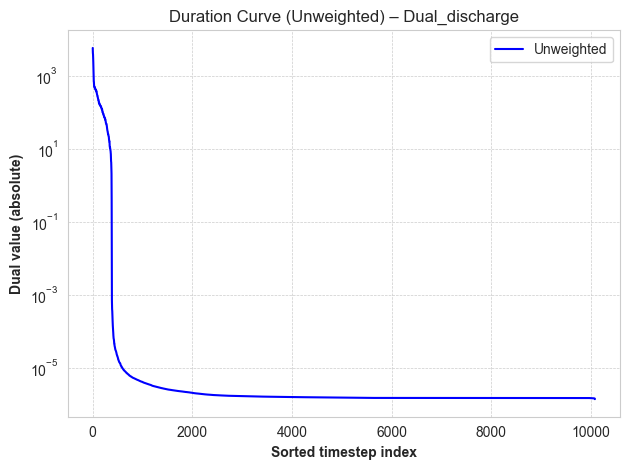

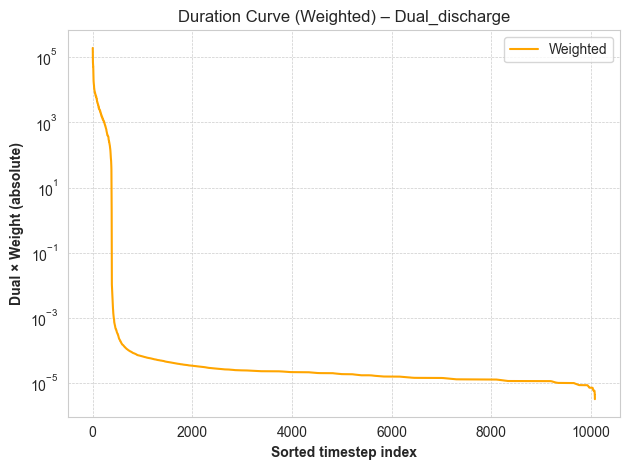

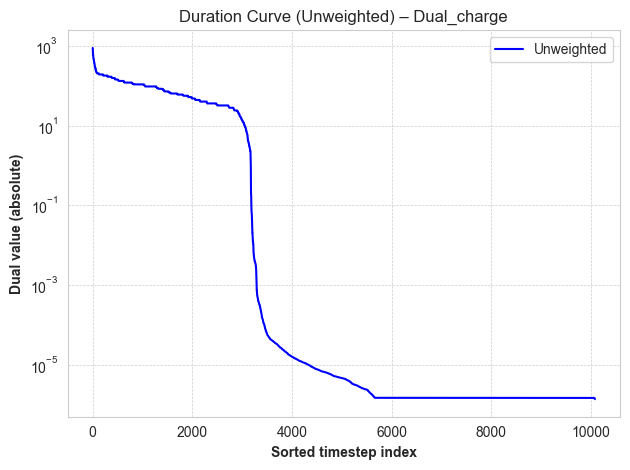

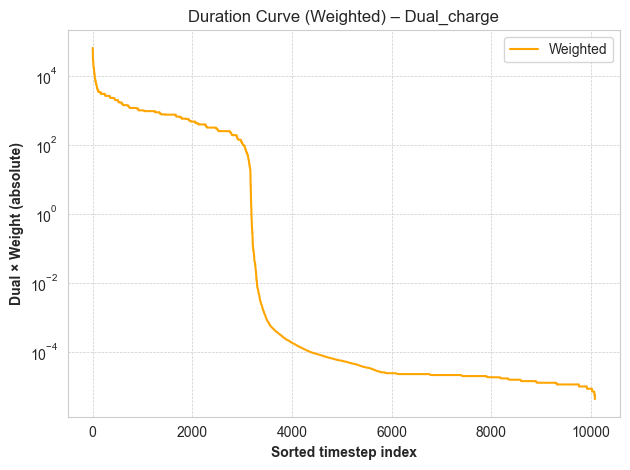

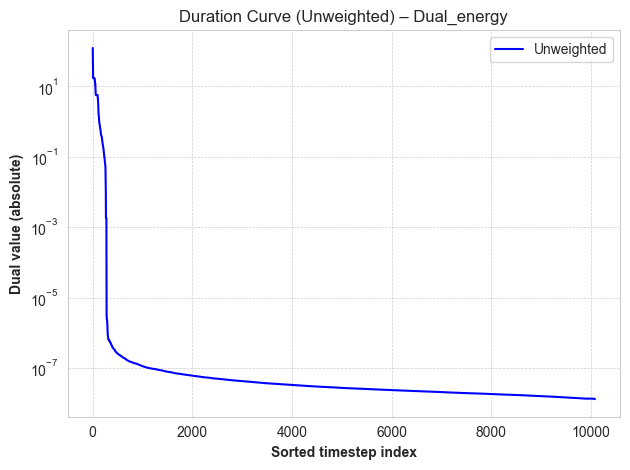

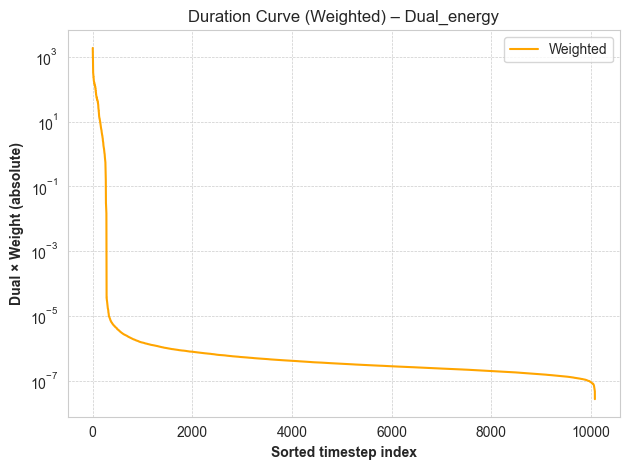

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_duration_curves_absolute(df, dual, weight_col='Weight'):
    abs_dual = df[dual].abs()
    weights = df[weight_col]

    # Sort values
    sorted_abs_dual = abs_dual.sort_values(ascending=False).reset_index(drop=True)
    sorted_weighted_dual = (abs_dual * weights).sort_values(ascending=False).reset_index(drop=True)

    # Plot 1: Unweighted
    plt.figure()
    plt.plot(sorted_abs_dual, label='Unweighted', color='blue')
    plt.yscale('log')
    plt.title(f"Duration Curve (Unweighted) – {dual}")
    plt.xlabel("Sorted timestep index")
    plt.ylabel("Dual value (absolute)")
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.legend()

    # Plot 2: Weighted
    plt.figure()
    plt.plot(sorted_weighted_dual, label='Weighted', color='orange')
    plt.yscale('log')
    plt.title(f"Duration Curve (Weighted) – {dual}")
    plt.xlabel("Sorted timestep index")
    plt.ylabel("Dual × Weight (absolute)")
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.legend()


def report_dual_activity(df, duals, threshold=1e-6, weight_col='Weight'):
    print(f"\n=== Frequency of Binding Constraints (|dual| > {threshold:.0e}) ===")
    
    total_timesteps = df.shape[0]
    total_weight = df[weight_col].sum()

    for dual in duals:
        abs_dual = df[dual].abs()
        is_binding = abs_dual > threshold

        # Unweighted frequency
        count_binding = is_binding.sum()
        percent_binding = 100 * count_binding / total_timesteps

        # Weighted frequency
        weight_binding = df.loc[is_binding, weight_col].sum()
        weight_percent = 100 * weight_binding / total_weight

        print(f"{dual}:")
        print(f"  Unweighted: {count_binding} binding steps ({percent_binding:.2f}%)")
        print(f"  Weighted:   {weight_binding:.2f} of total weight ({weight_percent:.2f}%)")


selected_storage = "H2"  # Change to "BESS" to analyze BESS
# Paths to the CSV files
duals_path = r"C:\Users\user\Downloads\trycodes_3\scarcity_rent_delta_0.5.csv"
weights_path = r"C:\Users\user\Downloads\trycodes_3\data_final\f672\concatenated_weights_672_30yr_new.csv"

# Filter for relevant scenarios and storage types
scenarios = [19, 12, 7, 11, 23, 8, 30, 24, 1, 26, 29, 13, 4, 22, 27]
storages = ["H2", "BESS"]
# Duals of interest
duals = ["Dual_discharge", "Dual_charge", "Dual_energy"]
threshold = 1e-6


# Load data
duals_df = pd.read_csv(duals_path)
weights_df = pd.read_csv(weights_path)
print(weights_df)
# Rename columns for clarity
weights_df.columns = ['Scenario', 'Time', 'Weight']


duals_df = duals_df[duals_df["Scenario"].isin(scenarios)]
duals_df = duals_df[duals_df["Storage"] == selected_storage]
weights_df = weights_df[weights_df["Scenario"].isin(scenarios)]
# Merge weights into duals dataframe
merged_df = pd.merge(duals_df, weights_df, how='left', on=['Scenario', 'Time'])

# Check for any NaNs in merged dataframe
if merged_df.isna().any().any():
    print("⚠️ Warning: There are missing (NaN) values in the merged dataframe.")
    print(merged_df.isna().sum())
    # Optional: stop execution if NaNs are critical
    # raise ValueError("Missing values found in merged dataframe. Check weights and merge keys.")
else:
    print("✅ No NaN values in merged dataframe.")



# === CONVERT DUALS TO ABSOLUTE VALUES ===
for dual in duals:
    merged_df[dual] = merged_df[dual].abs()
    

# === ANALYSIS ===
print(f"\n📦 Analyzing Storage Asset: {selected_storage}")    
report_dual_activity(merged_df, duals, threshold=threshold)

for dual in duals:
    plot_duration_curves_absolute(merged_df, dual)

plt.show()

✅ No NaN values in merged dataframe.

1. Energy level at end of each month:
 month  energy_level energy_percent
     1     97.614767         60.06%
     2     86.466840         53.20%
     3     72.722590         44.75%
     4     67.699578         41.66%
     5     98.640617         60.69%
     6     84.481630         51.98%
     7     77.694112         47.81%
     8     63.592872         39.13%
     9     75.646849         46.55%
    10    106.505437         65.53%
    11     83.937095         51.65%
    12    146.930520         90.41%

2. Average weighted charging hours per scenario (>1e-06 MW): 4600.60 hours
   Average weighted discharging hours per scenario (>1e-06 MW): 5199.00 hours

3. Average energy charged per scenario (>1e-06 MW): 6136.46 MWh
   Average energy discharged per scenario (>1e-06 MW): 2362.23 MWh


C:\Users\user\AppData\Local\Temp\ipykernel_17040\4048777906.py:104: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged_df.groupby("SOC Bin (%)")["time_weight"]


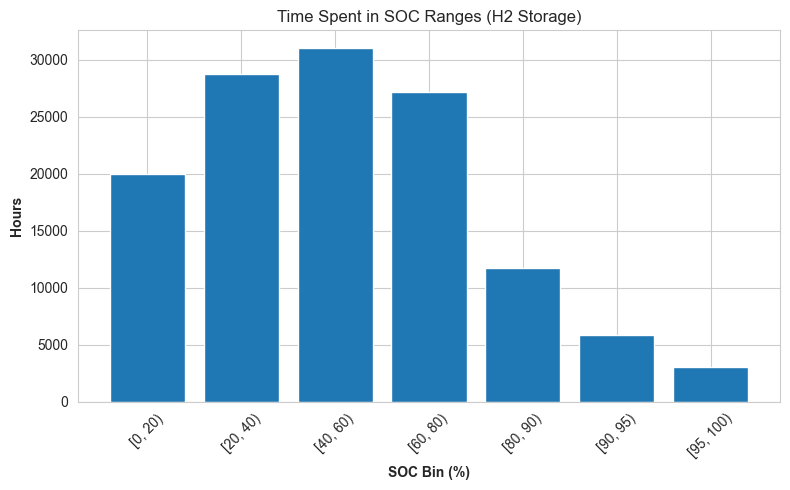

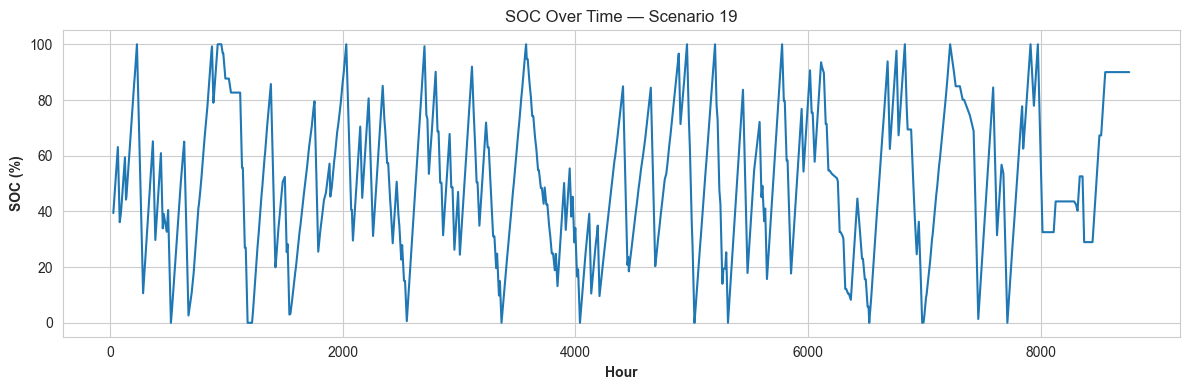


 Total time at or near FULL (≥ 99%): 3946.00 hours
 Total time at or near EMPTY (≤ 1%): 4000.00 hours

 Total H₂ charged into storage: 92046.86 MWh
 Total H₂ discharged from storage: 35433.50 MWh


C:\Users\user\AppData\Local\Temp\ipykernel_17040\4048777906.py:194: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discharge_cycles.groupby("Depth Bin (%)")["Weighted Hours"]


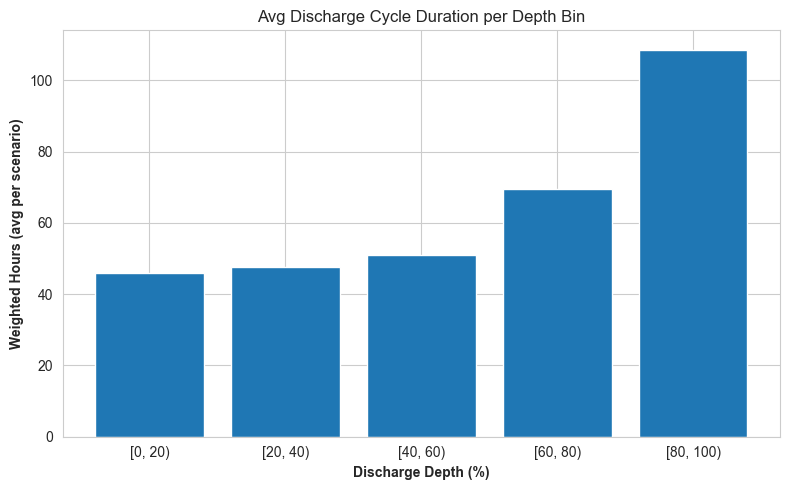

In [ ]:
import pandas as pd

# Constants
selected_storage = "H2"
scenarios = [19, 12, 7, 11, 23, 8, 30, 24, 1, 26, 29, 13, 4, 22, 27]
ENERGY_CAPACITY = 162.522716388603  # MWh

# File paths
energy_data_path = r"C:\Users\user\Downloads\trycodes_3\energy_charge_discharge_delta_0.5.csv"
weights_path = r"C:\Users\user\Downloads\trycodes_3\data_final\f672\concatenated_weights_672_30yr_new.csv"

# Load CSVs
energy_df = pd.read_csv(energy_data_path)
weights_df = pd.read_csv(weights_path)

# Rename columns for clarity
weights_df = weights_df.rename(columns={"O": "Scenario", "T": "Time", "value": "time_weight"})

# Apply filtering
energy_df = energy_df[energy_df["Scenario"].isin(scenarios)]
energy_df = energy_df[energy_df["Storage"] == selected_storage]
weights_df = weights_df[weights_df["Scenario"].isin(scenarios)]

# Merge both dataframes on Scenario and Time
merged_df = pd.merge(energy_df, weights_df, on=["Scenario", "Time"], how="left")

# Check for NaNs
if merged_df.isna().any().any():
    print("⚠️ Warning: There are missing (NaN) values in the merged dataframe.")
    print(merged_df.isna().sum())
    # Optional: stop execution if NaNs are critical
    # raise ValueError("Missing values found in merged dataframe. Check weights and merge keys.")
else:
    print("✅ No NaN values in merged dataframe.")

# Calculate cumulative time (hours) for each scenario
merged_df["cumulative_hour"] = merged_df.groupby("Scenario")["time_weight"].cumsum()
merged_df["hour_rounded"] = merged_df["cumulative_hour"].round().astype(int)

# Assign month based on rounded hour (730 hours/month)
#merged_df["month"] = ((merged_df["hour_rounded"] - 1) // 730 + 1).clip(upper=12)
merged_df["month"] = ((merged_df["hour_rounded"] - 1) // 730 + 1)

# 1. Energy Level at End of Each Month
monthly_energy = (
    merged_df.sort_values(["Scenario", "cumulative_hour"])
    .groupby(["Scenario", "month"])
    .tail(1)
    .groupby("month")["energy_level"]
    .mean()
    .reset_index()
)
monthly_energy["energy_percent"] = 100 * monthly_energy["energy_level"] / ENERGY_CAPACITY

print("\n1. Energy level at end of each month:")
print(monthly_energy.to_string(index=False, formatters={"energy_percent": "{:.2f}%".format}))



# Threshold for meaningful charge/discharge (in MW)
CHARGE_DISCHARGE_THRESHOLD = 1e-6 # Adjust as needed

# Filter based on threshold
charging_mask = merged_df["Charge"] > CHARGE_DISCHARGE_THRESHOLD
discharging_mask = merged_df["Discharge"] > CHARGE_DISCHARGE_THRESHOLD

# 2. Charging/discharging hours per scenario (with threshold)
charging_by_scenario = merged_df[charging_mask].groupby("Scenario")["time_weight"].sum()
discharging_by_scenario = merged_df[discharging_mask].groupby("Scenario")["time_weight"].sum()

charging_hours_avg = charging_by_scenario.mean()
discharging_hours_avg = discharging_by_scenario.mean()

print(f"\n2. Average weighted charging hours per scenario (>{CHARGE_DISCHARGE_THRESHOLD} MW): {charging_hours_avg:.2f} hours")
print(f"   Average weighted discharging hours per scenario (>{CHARGE_DISCHARGE_THRESHOLD} MW): {discharging_hours_avg:.2f} hours")

# 3. Total energy charged/discharged per scenario (with threshold)
merged_df["charged_energy_MWh"] = merged_df["Charge"] * merged_df["time_weight"]
merged_df["discharged_energy_MWh"] = merged_df["Discharge"] * merged_df["time_weight"]

energy_by_scenario = merged_df[charging_mask | discharging_mask].groupby("Scenario")[["charged_energy_MWh", "discharged_energy_MWh"]].sum()

avg_charged_energy = energy_by_scenario["charged_energy_MWh"].mean()
avg_discharged_energy = energy_by_scenario["discharged_energy_MWh"].mean()

print(f"\n3. Average energy charged per scenario (>{CHARGE_DISCHARGE_THRESHOLD} MW): {avg_charged_energy:.2f} MWh")
print(f"   Average energy discharged per scenario (>{CHARGE_DISCHARGE_THRESHOLD} MW): {avg_discharged_energy:.2f} MWh")

#!pip install fatpack
!pip install rainflow
#rainflow algorithm
import numpy as np
import pandas as pd
#from fatpack import find_peaks, rainflow_cycles
import rainflow
# --- Compute SOC (%)
merged_df["SOC"] = 100 * merged_df["energy_level"] / ENERGY_CAPACITY

# === 1. Histogram: Time spent in each SOC range (recommended bins for H₂)
soc_bins = [0, 20, 40, 60, 80, 90, 95, 100]
merged_df["SOC Bin (%)"] = pd.cut(merged_df["SOC"], bins=soc_bins, right=False)

soc_time = (
    merged_df.groupby("SOC Bin (%)")["time_weight"]
    .sum()
    .reset_index(name="Total Hours")
)

# Plot
plt.figure(figsize=(8, 5))
plt.bar(soc_time["SOC Bin (%)"].astype(str), soc_time["Total Hours"])
plt.title("Time Spent in SOC Ranges (H2 Storage)")
plt.ylabel("Hours")
plt.xlabel("SOC Bin (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# === 2. Plot: SOC over time (pick one scenario)
example_scenario = scenarios[0]
scenario_df = merged_df[merged_df["Scenario"] == example_scenario].sort_values("cumulative_hour")

plt.figure(figsize=(12, 4))
plt.plot(scenario_df["cumulative_hour"], scenario_df["SOC"], label=f"Scenario {example_scenario}")
plt.title(f"SOC Over Time — Scenario {example_scenario}")
plt.xlabel("Hour")
plt.ylabel("SOC (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

# === 3. Time spent at full / empty
SOC_FULL_THRESH = 99  # can adjust
SOC_EMPTY_THRESH = 1

full_time = merged_df.loc[merged_df["SOC"] >= SOC_FULL_THRESH, "time_weight"].sum()
empty_time = merged_df.loc[merged_df["SOC"] <= SOC_EMPTY_THRESH, "time_weight"].sum()

print(f"\n Total time at or near FULL (≥ {SOC_FULL_THRESH}%): {full_time:.2f} hours")
print(f" Total time at or near EMPTY (≤ {SOC_EMPTY_THRESH}%): {empty_time:.2f} hours")

# === 4. Throughput calculation (total H2 in/out)
THRESH = 1e-6  # MW, to filter out noise

charge_energy = (
    merged_df.loc[merged_df["Charge"] > THRESH, "Charge"] *
    merged_df.loc[merged_df["Charge"] > THRESH, "time_weight"]
).sum()

discharge_energy = (
    merged_df.loc[merged_df["Discharge"] > THRESH, "Discharge"] *
    merged_df.loc[merged_df["Discharge"] > THRESH, "time_weight"]
).sum()

print(f"\n Total H₂ charged into storage: {charge_energy:.2f} MWh")
print(f" Total H₂ discharged from storage: {discharge_energy:.2f} MWh")

# === 5. Rainflow: Cycle frequency and depth
def compute_discharge_cycles(df, scenario_id):
    df_scen = df[df["Scenario"] == scenario_id].sort_values("cumulative_hour").reset_index(drop=True)
    soc_series = df_scen["SOC"].values
    time_weights = df_scen["time_weight"].values
    cycles = rainflow.extract_cycles(soc_series)

    cycle_data = []
    for amp, mean, count, idx_start, idx_end in cycles:
        if idx_end >= len(time_weights):
            continue
        if soc_series[idx_end] < soc_series[idx_start]:  # Only discharging
            cycle_depth = 2 * amp
            cycle_duration = time_weights[idx_start:idx_end + 1].sum()
            weighted_hours = count * cycle_duration
            cycle_data.append({
                "Discharge Depth (%)": cycle_depth,
                "Count": count,
                "Weighted Hours": weighted_hours,
                "Scenario": scenario_id
            })
    return pd.DataFrame(cycle_data)

# Apply to all scenarios
discharge_cycles = pd.concat(
    [compute_discharge_cycles(merged_df, s) for s in scenarios],
    ignore_index=True
)

# Bin by discharge depth (recommended for H2: broader)
depth_bins = [0, 20, 40, 60, 80, 100]
discharge_cycles["Depth Bin (%)"] = pd.cut(discharge_cycles["Discharge Depth (%)"], bins=depth_bins, right=False)

# Summarize
depth_summary = (
    discharge_cycles.groupby("Depth Bin (%)")["Weighted Hours"]
    .mean()
    .reset_index(name="Avg Cycle Hours")
)

# Plot
plt.figure(figsize=(8, 5))
plt.bar(depth_summary["Depth Bin (%)"].astype(str), depth_summary["Avg Cycle Hours"])
plt.title("Avg Discharge Cycle Duration per Depth Bin")
plt.xlabel("Discharge Depth (%)")
plt.ylabel("Weighted Hours (avg per scenario)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [94]:
import pandas as pd

# ----------------------------
# Config
# ----------------------------
FILE = r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Fully_incomplete_markets_ADMM\data_final\data_VRE_30.csv"
OUT_FILE = r"C:\Users\user\Desktop\pv_night_percentage_by_hour.csv"

scenarios = [19, 12, 7, 11, 23, 8, 30, 24, 1, 26, 29, 13, 4, 22, 27]

# ----------------------------
# Load and filter
# ----------------------------
df = pd.read_csv(FILE)

# Keep only selected scenarios
pv = df[df["Y"].isin(scenarios)].copy()

# ----------------------------
# Classify night
# ----------------------------
pv["is_night"] = (pv["PV"] == 0)

# ----------------------------
# Compute % night per timestep
# ----------------------------
totals = pv.groupby("T")["Y"].count()       # number of scenarios per timestep
nights = pv.groupby("T")["is_night"].sum()  # number of scenarios with PV=0

pct_night = 100 * nights / totals

# ----------------------------
# Final dataframe
# ----------------------------
out = pd.DataFrame({
    "T": pct_night.index,
    "pct_night": pct_night.values
}).sort_values("T").reset_index(drop=True)

# Save
out.to_csv(OUT_FILE, index=False)

print(f"Saved: {OUT_FILE}")



Saved: C:\Users\user\Desktop\pv_night_percentage_by_hour.csv



=== Time-weighted annual CF per (G,O) ===
            G  O       CF
           PV  1 0.110740
           PV  4 0.106423
           PV  7 0.109617
           PV  8 0.108155
           PV 11 0.105158
           PV 12 0.108785
           PV 13 0.104965
           PV 19 0.108576
           PV 22 0.109539
           PV 23 0.105687
           PV 24 0.110822
           PV 26 0.110522
           PV 27 0.109830
           PV 29 0.110390
           PV 30 0.110095
Wind_Offshore  1 0.429739
Wind_Offshore  4 0.383781
Wind_Offshore  7 0.377780
Wind_Offshore  8 0.358068
Wind_Offshore 11 0.390586
Wind_Offshore 12 0.366994
Wind_Offshore 13 0.383099
Wind_Offshore 19 0.411622
Wind_Offshore 22 0.387050
Wind_Offshore 23 0.366802
Wind_Offshore 24 0.381923
Wind_Offshore 26 0.406412
Wind_Offshore 27 0.357038
Wind_Offshore 29 0.358492
Wind_Offshore 30 0.362297
 Wind_Onshore  1 0.343871
 Wind_Onshore  4 0.297074
 Wind_Onshore  7 0.287300
 Wind_Onshore  8 0.275733
 Wind_Onshore 11 0.288654
 Wind_Onshore 12 0.26

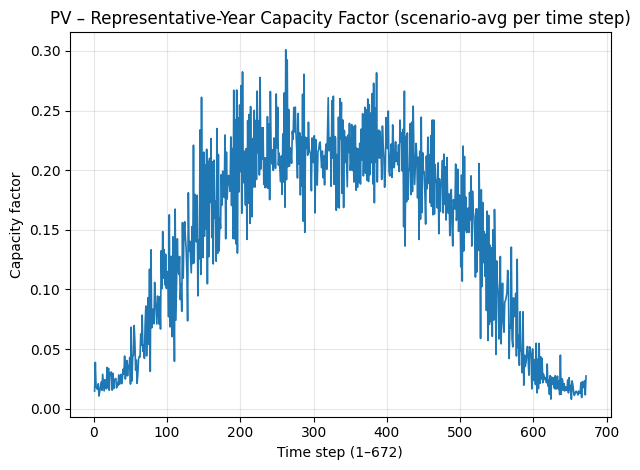

In [11]:
import numpy as np
import pandas as pd
from pathlib import Path

# --- File paths (as provided) ---
path_cf = Path(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\data_final\f672\concatenated_capacity_factors_672_30yr_new_lf.csv")
path_wt = Path(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\data_final\f672\concatenated_weights_672_30yr_new.csv")
path_demand = Path(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\data_final\f672\concatenated_load_profiles_672_30yr_new.csv") 

# --- Scenario sets ---
SCENARIOS_ALL  = [11,12,13,19,1,22,23,24,26,27,29,30,4,7,8]
SCENARIOS_TAIL = [11,12,19,23,24,30,7,8]

# --- Read data ---
cf = pd.read_csv(path_cf)  # expects columns: O, T, G, value
wt = pd.read_csv(path_wt)  # expects columns: O, T, value
demand = pd.read_csv(path_demand)

# Standardize column names we use below
cf = cf.rename(columns={'value': 'cf'})
wt = wt.rename(columns={'value': 'w'})
demand = demand.rename(columns={'value': 'd'})


# --- Filter to your scenario set ---
cf = cf[cf['O'].isin(SCENARIOS_ALL)].copy()
wt = wt[wt['O'].isin(SCENARIOS_ALL)].copy()
demand = demand[demand['O'].isin(SCENARIOS_ALL)].copy()

# --- Merge on (O,T) to bring time weights alongside capacity factors ---
df = cf.merge(wt, on=['O', 'T'], how='inner')

# --- Compute time-weighted annual CF per technology & scenario ---
# Create product and sum by (G,O): CF_{G,o} = sum_t w * cf / sum_t w
df['wcf'] = df['w'] * df['cf']
agg = df.groupby(['G','O'], as_index=False).agg(num=('wcf', 'sum'), den=('w', 'sum'))
agg['CF'] = agg['num'] / agg['den']
cf_go = agg[['G','O','CF']].copy()

# --- Helper: summarize distribution across scenarios for each technology ---
def summarize_cf(cv_df: pd.DataFrame, scenarios: list[int], label: str) -> pd.DataFrame:
    d = cv_df[cv_df['O'].isin(scenarios)].copy()

    def pctl(x, q):
        return float(np.percentile(x, q))

    rows = []
    for g, sub in d.groupby('G'):
        x = sub['CF'].to_numpy()
        mean = float(np.mean(x))
        std  = float(np.std(x, ddof=1)) if len(x) > 1 else 0.0
        cv   = std / mean if mean != 0 else np.nan
        p25  = pctl(x, 25)
        p50  = pctl(x, 50)  # median
        p75  = pctl(x, 75)
        # Downside mean (worst 50%): average of values <= median
        downside_mean = float(np.mean(x[x <= p50]))
        downside_mean_ratio = downside_mean / mean if mean != 0 else np.nan

        rows.append({
            'set': label, 'G': g, 'N': len(x),
            'mean': mean, 'std': std, 'cv': cv,
            'p25': p25, 'p50_median': p50, 'p75': p75,
            'downside_mean': downside_mean,
            'downside_mean_ratio': downside_mean_ratio,
            'min': float(np.min(x)), 'max': float(np.max(x))
        })
    cols = ['set','G','N','mean','std','cv','p25','p50_median','p75',
            'downside_mean','downside_mean_ratio','min','max']
    return pd.DataFrame(rows)[cols].sort_values(['G'])

summary_all  = summarize_cf(cf_go, SCENARIOS_ALL,  label='ALL')
summary_tail = summarize_cf(cf_go, SCENARIOS_TAIL, label='TAIL')

# --- Output results ---
print("\n=== Time-weighted annual CF per (G,O) ===")
print(cf_go.sort_values(['G','O']).to_string(index=False))

print("\n=== Summary across ALL scenarios (CVaR-50 aligned) ===")
print(summary_all.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

print("\n=== Summary across TAIL scenarios (CVaR-50 aligned) ===")
print(summary_tail.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

# --- Optional saves ---
# out_dir = path_cf.parent
# cf_go.to_csv(out_dir / "cf_weighted_by_scenario.csv", index=False)
# summary_all.to_csv(out_dir / "cf_summary_ALL_cvar50.csv", index=False)
# summary_tail.to_csv(out_dir / "cf_summary_TAIL_cvar50.csv", index=False)

# --- Optional: quick interpretation printouts (aligned with CVaR-50) ---
for g in cf_go['G'].unique():
    m_all  = summary_all.loc[summary_all['G']==g, 'mean'].item()
    med    = summary_all.loc[summary_all['G']==g, 'p50_median'].item()
    dmr    = summary_all.loc[summary_all['G']==g, 'downside_mean_ratio'].item()
    cv     = summary_all.loc[summary_all['G']==g, 'cv'].item()
    print(f"\n{g}: mean={m_all:.4f}, median(p50)={med:.4f}, downside-mean/mean={dmr:.3f}, CV={cv:.3%}")
    
    
    
    
# --- Representative year (mean CF across scenarios for each time step) ---
TECHS = ["PV"]

# Average CF across scenarios for each (T, G)
rep_ts = (
    df.groupby(['T', 'G'], as_index=False)
      .agg(cf_mean=('cf', 'mean'))
)

# Pivot to have one column per technology; ensure time steps are ordered
rep_pivot = (
    rep_ts.pivot(index='T', columns='G', values='cf_mean')
          .sort_index()
)

# Representative weights per time step: average across scenarios (from the original wt table)
w_rep = wt.groupby('T', as_index=False).agg(w=('w', 'mean'))

# --- Print time-weighted annual CF for each target tech (optional but handy) ---
print("\n=== Representative-year annual CF (time-weighted across T) ===")
for tech in TECHS:
    if tech not in rep_pivot.columns:
        print(f"{tech}: not found in G")
        continue
    tmp = rep_pivot[[tech]].reset_index().merge(w_rep, on='T', how='inner')
    cf_annual = (tmp['w'] * tmp[tech]).sum() / tmp['w'].sum()
    print(f"{tech}: {cf_annual:.4f}")

# --- Plots: one figure per technology, 672 points each (no specified colors) ---
import matplotlib.pyplot as plt

for tech in TECHS:
    if tech not in rep_pivot.columns:
        continue
    s = rep_pivot[tech].dropna()

    plt.figure()
    plt.plot(s.index.values, s.values, linewidth=1.2)
    plt.title(f"{tech} – Representative-Year Capacity Factor (scenario-avg per time step)")
    plt.xlabel("Time step (1–672)")
    plt.ylabel("Capacity factor")
    #plt.ylim(0, 1)             # CFs are 0–1; remove if you prefer autoscale
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [8]:
import pandas as pd

# --- read data (first sheet by default) ---
gen = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\data_final\data_preparation_new\data_preparation_CF_cluster_fix\concatenated_capacity_factors_40yr.csv")
w   = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\data_final\data_preparation_new\data_preparation_CF_cluster_fix\concatenated_weights_40yr.csv")

# --- divide by factors ---
gen = gen.copy()
gen["PV"] /= 1.55
gen["Wind_Onshore"] /= 0.5
gen["Wind_Offshore"] /= 0.87

# cap CFs at 1 (do not change values <= 1)
cols = ["PV", "Wind_Onshore", "Wind_Offshore"]
gen[cols] = gen[cols].clip(upper=1)


gen.to_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\data_final\data_preparation_new\data_preparation_CF_cluster_fix\concatenated_capacity_factors_40yr_undo_scaling.csv", index=False)

# --- merge on (Y, T) ---
df = pd.merge(gen, w, on=["Y", "T"], how="inner")

# --- per-year weighted average CFs (weights already sum to 8760 per year) ---
per_year_cf = (
    df.groupby("Y")
      .apply(lambda g: pd.Series({
          "CF_PV_avg":            (g["PV"]            * g["Weights"]).sum() / 8760.0,
          "CF_Wind_Onshore_avg":  (g["Wind_Onshore"]  * g["Weights"]).sum() / 8760.0,
          "CF_Wind_Offshore_avg": (g["Wind_Offshore"] * g["Weights"]).sum() / 8760.0,
      }))
      .reset_index()
)

# --- overall average CF per tech across all years ---
overall_cf = {
    "CF_PV_overall":            (df["PV"]            * df["Weights"]).sum() / df["Weights"].sum(),
    "CF_Wind_Onshore_overall":  (df["Wind_Onshore"]  * df["Weights"]).sum() / df["Weights"].sum(),
    "CF_Wind_Offshore_overall": (df["Wind_Offshore"] * df["Weights"]).sum() / df["Weights"].sum(),
}

# (optional) save
#per_year_cf.to_csv("per_year_weighted_CFs.csv", index=False)
#pd.DataFrame([overall_cf]).to_csv("overall_weighted_CFs.csv", index=False)

print(per_year_cf)
print(overall_cf)


     Y  CF_PV_avg  CF_Wind_Onshore_avg  CF_Wind_Offshore_avg
0    1   0.108331             0.282469              0.393579
1    2   0.104582             0.294006              0.389904
2    3   0.107416             0.303426              0.376943
3    4   0.104919             0.313471              0.400287
4    5   0.113997             0.270309              0.357068
5    6   0.106927             0.275602              0.382097
6    7   0.109439             0.338684              0.436474
7    8   0.107179             0.255434              0.347120
8    9   0.108941             0.296632              0.396104
9   10   0.110747             0.305286              0.375042
10  11   0.110740             0.343871              0.429739
11  12   0.109883             0.286083              0.368506
12  13   0.104754             0.317436              0.400708
13  14   0.106423             0.297074              0.383781
14  15   0.107315             0.328911              0.414915
15  16   0.112161       

C:\Users\user\AppData\Local\Temp\ipykernel_20620\1860131257.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


In [20]:
import pandas as pd
import numpy as np

# Weighted std function
def weighted_std(values, weights):
    average = np.average(values, weights=weights)
    variance = np.average((values - average) ** 2, weights=weights)
    return np.sqrt(variance)

# Weighted quantile function
def weighted_quantile(values, weights, quantile):
    values = np.array(values)
    weights = np.array(weights)
    
    sorter = np.argsort(values)
    values = values[sorter]
    weights = weights[sorter]
    
    cumulative_weight = np.cumsum(weights)
    total_weight = cumulative_weight[-1]
    
    return values[np.searchsorted(cumulative_weight, quantile * total_weight)]


# Load the uploaded data
cf = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\data_final\data_preparation_new\data_preparation_CF_cluster_fix\concatenated_capacity_factors_30yr_undo_scaling_lf.csv")
load_df = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\data_final\data_preparation_new\data_preparation_CF_cluster_fix\concatenated_load_profiles_30yr.csv")
weights_df = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\data_final\data_preparation_new\data_preparation_CF_cluster_fix\concatenated_weights_30yr.csv")

# Keep only the total scenarios
#total_scenarios = []
#load_df   = load_df[load_df["O"].isin(total_scenarios)].copy()
#weights_df = weights_df[weights_df["O"].isin(total_scenarios)].copy()


load_df = load_df.rename(columns={"value":"load"})
weights_df =weights_df.rename(columns={"value":"weight"})


# Merge load and weight data
merged_df = pd.merge(load_df, weights_df, on=["T", "O"], how="inner")

# Compute weighted demand per timestep
merged_df["weighted_demand"] = merged_df["load"] * merged_df["weight"]

# Now build demand_stats with weighted metrics
demand_stats = (
    merged_df.groupby("O")
    .apply(lambda group: pd.Series({
        "total_demand": group["weighted_demand"].sum(),
        "total_weight": group["weight"].sum(),
        "average_load": group["weighted_demand"].sum() / group["weight"].sum(),
        "max_load": group["load"].max(),
        "min_load": group["load"].min(),
        #"mean_load": np.average(group["load"], weights=group["weight"]),
        "std_load": weighted_std(group["load"], group["weight"]),
        "range_load": group["load"].max() - group["load"].min(),
        "p10_load": weighted_quantile(group["load"], group["weight"], 0.10),
        "p90_load": weighted_quantile(group["load"], group["weight"], 0.90),
    }))
    .reset_index()
)

print(demand_stats)

     O  total_demand  total_weight  average_load  max_load  min_load  \
0    1   5795.866199        8760.0      0.661629  0.932878  0.458467   
1    2   5723.973734        8760.0      0.653422  0.923169  0.433915   
2    3   5694.585717        8760.0      0.650067  0.939843  0.466063   
3    4   5675.112836        8760.0      0.647844  0.930429  0.448082   
4    5   5723.973734        8760.0      0.653422  0.927663  0.449913   
5    6   5542.032481        8760.0      0.632652  0.917140  0.419452   
6    7   5694.585716        8760.0      0.650067  0.929405  0.440961   
7    8   5694.585716        8760.0      0.650067  0.926317  0.421205   
8    9   5795.866199        8760.0      0.661629  0.927464  0.468599   
9   10   5764.580473        8760.0      0.658057  0.929485  0.457709   
10  11   5574.951459        8760.0      0.636410  0.923942  0.413076   
11  12   5495.396293        8760.0      0.627328  0.960954  0.416723   
12  13   5574.951458        8760.0      0.636410  0.906249  0.43

C:\Users\user\AppData\Local\Temp\ipykernel_20620\651901422.py:49: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: pd.Series({


In [35]:
import pandas as pd

# === Load your actual files ===
cf = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\data_final\ffff672\concatenated_capacity_factors_40yr_lf.csv")
demand = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\data_final\ffff672\concatenated_load_profiles_40yr.csv")
weights = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\data_final\ffff672\concatenated_weights_40yr.csv")

#total_scenarios = [19, 12, 7, 11, 23, 8, 30, 24, 1, 26, 29, 13, 4, 22, 27]
#total_scenarios =  [3,5,6,7,11,13,15,16,17,12,20,22,25,27,30]
total_scenarios =  [27, 6, 29, 14, 10, 8, 7, 12, 17, 18, 22, 24, 23, 21, 2]
  

# Keep only the total scenarios
cf   = cf[cf["O"].isin(total_scenarios)].copy()
demand = demand[demand["O"].isin(total_scenarios)].copy()
wt = weights[weights["O"].isin(total_scenarios)].copy()

# Pivot CF to wide: columns become PV, Wind_Onshore, Wind_Offshore
cfw = cf.pivot_table(index=["O","T"], columns="G", values="value").reset_index()

# Merge weights
wt = wt.rename(columns={"value":"weight"})
df = cfw.merge(wt, on=["O","T"], how="inner")
demand =demand.rename(columns={"value":"demand"})

techs = [c for c in ["PV", "Wind_Onshore", "Wind_Offshore"] if c in df.columns]
X1=0.70
X2=1.2
X3=1.47
# --- Apply multipliers with cap at 1.0 ---
mult = pd.Series({"PV": X1, "Wind_Onshore": X2, "Wind_Offshore": X3})
df[techs] = df[techs].mul(mult, axis=1).clip(upper=1.0)

# --- Time-weighted CF per scenario, then overall (equiprobable) ---
num = df[techs].mul(df["weight"], axis=0).groupby(df["O"]).sum()
den = df.groupby("O")["weight"].sum()
per_scn_cf = num.div(den, axis=0)          # CF_{G,o} = sum_t w*cf / sum_t w
overall_cf = per_scn_cf.mean()             # simple average across scenarios

print("Overall average capacity factors (after multipliers, capped at 1.0):")
for tech, val in overall_cf.items():
    print(f"  {tech}: {val:.4f}")
    


Overall average capacity factors (after multipliers, capped at 1.0):
  PV: 0.0758
  Wind_Onshore: 0.3447
  Wind_Offshore: 0.5341


In [3]:
import pandas as pd
import numpy as np

# === Load your actual files ===
cf = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\data_final\ffff672\concatenated_capacity_factors_40yr_lf.csv")
demand = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\data_final\ffff672\concatenated_load_profiles_40yr.csv")
weights = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\data_final\ffff672\concatenated_weights_40yr.csv")

# ----------------------------
# Config (you can tweak these)
# ----------------------------
WINDOW_HOURS = [24, 72, 168, 336]   # 1,3,7,14 days
SCALES = [1.0, 3.0]                 # base and 3× VRE test
TOP_K = 15

OUT_FULL = r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\data_final\ffff672\scenario_energy_drought_metrics.csv"
OUT_TOPK = r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\data_final\ffff672\top15_energy_drought_years.csv"


# If you want to enforce a specific VRE mix, set capacities here (else each tech gets weight 1.0):
CAPS = {"PV": 90, "Wind_Onshore": 45.0, "Wind_Offshore": 108}
#CAPS = {"PV": 67, "Wind_Onshore": 45, "Wind_Offshore": 90}
#CAPS = None

# ----------------------------
# Helpers
# ----------------------------
def norm_load(df: pd.DataFrame) -> pd.DataFrame:
    ren = {}
    for c in df.columns:
        cl = c.lower()
        if cl in ("o","y","year","scenario"): ren[c]="Y"
        elif cl in ("t","time","hour","index","ts","timestamp"): ren[c]="T"
        elif cl in ("value","load","demand","p","mwh"): ren[c]="load"
    df = df.rename(columns=ren)
    return df[["Y","T","load"]].copy()

def norm_weights(df: pd.DataFrame) -> pd.DataFrame:
    ren = {}
    for c in df.columns:
        cl = c.lower()
        if cl in ("o","y","year","scenario"): ren[c]="Y"
        elif cl in ("t","time","hour","index","ts","timestamp"): ren[c]="T"
        elif cl in ("value","w","weight","weights","time_weight","timeweight"): ren[c]="W"
    df = df.rename(columns=ren)
    return df[["Y","T","W"]].copy()

def norm_cf(df: pd.DataFrame) -> pd.DataFrame:
    ren = {}
    for c in df.columns:
        cl = c.lower()
        if cl in ("o","y","year","scenario"): ren[c]="Y"
        elif cl in ("t","time","hour","index","ts","timestamp"): ren[c]="T"
        elif cl in ("g","tech","technology"): ren[c]="tech"
        elif cl in ("value","cf","capacity_factor"): ren[c]="cf"
    df = df.rename(columns=ren)
    return df[["Y","T","tech","cf"]].copy()

def expand_by_weights(series, weights):
    """Repeat each representative timestep value by its integer weight to get an hourly series."""
    w = np.asarray(weights, dtype=float)
    if not np.allclose(w, np.round(w)):
        w = np.round(w)
    w = w.astype(int)
    x = np.asarray(series, dtype=float)
    parts = []
    for xi, wi in zip(x, w):
        if wi > 0:
            parts.append(np.full(wi, xi, dtype=float))
    return np.concatenate(parts) if parts else np.array([], dtype=float)

def max_sustained_deficit(load_hr, vre_hr, L, scale):
    """Max over any contiguous L-hour window of sum(load) - scale * sum(VRE)."""
    if len(load_hr) < L:
        return np.nan
    k = np.ones(L, dtype=float)
    sumL = np.convolve(load_hr, k, mode="valid")
    sumV = np.convolve(vre_hr,  k, mode="valid")
    return float(np.max(sumL - scale * sumV))

def longest_run(mask_bool):
    """Longest consecutive run of True values (hours)."""
    best = run = 0
    for v in mask_bool:
        if v:
            run += 1
            if run > best: best = run
        else:
            run = 0
    return int(best)

# ----------------------------
# Build merged dataframe
# ----------------------------
ld = norm_load(demand)
wt = norm_weights(weights)
cf_long = norm_cf(cf)

# Keep only VRE techs present (typical names below; otherwise use all unique techs as VRE)
vre_candidates = ["PV", "Wind_Onshore", "Wind_Offshore"]
present_techs = sorted(cf_long["tech"].unique().tolist())
vre_techs = [t for t in vre_candidates if t in present_techs]
if not vre_techs:
    # fallback: treat everything in CF file as VRE
    vre_techs = present_techs

# Choose capacities/weights for combining VRE CFs
if CAPS is None:
    cap_weights = {t: 1.0 for t in vre_techs}
else:
    cap_weights = {t: CAPS.get(t, 0.0) for t in vre_techs}

# Pivot CFs to wide
cf_wide = cf_long[cf_long["tech"].isin(vre_techs)].pivot_table(
    index=["Y","T"], columns="tech", values="cf"
).reset_index()

# Merge load & weights & CFs
merged = (
    ld.merge(wt, on=["Y","T"], how="inner")
      .merge(cf_wide, on=["Y","T"], how="inner")
      .sort_values(["Y","T"])
)

# ----------------------------
# Compute drought metrics per year
# ----------------------------
rows = []
for y, g in merged.groupby("Y", sort=True):
    g = g.sort_values("T").reset_index(drop=True)

    # Expand to hourly series using time weights
    W_rep = g["W"].to_numpy()
    load_hr = expand_by_weights(g["load"], W_rep)

    # Combined VRE at base capacities (sum cap_i * CF_i)
    vre_rep = np.zeros(len(g), dtype=float)
    for tname, wgt in cap_weights.items():
        if tname in g:
            vre_rep += wgt * g[tname].to_numpy()
    vre_hr = expand_by_weights(vre_rep, W_rep)

    if load_hr.size == 0 or vre_hr.size == 0:
        continue  # skip malformed year

    # 75th percentile demand & 25th percentile VRE to define "harsh" hours
    qd75 = float(np.quantile(load_hr, 0.75))
    qv25 = float(np.quantile(vre_hr, 0.25))
    harsh_mask = (load_hr >= qd75) & (vre_hr <= qv25)
    longest_harsh = longest_run(harsh_mask)

    # Sustained deficits across windows at s=1 and s=3
    worst_s1 = []
    worst_s3 = []
    for L in WINDOW_HOURS:
        worst_s1.append(max_sustained_deficit(load_hr, vre_hr, L, 1.0))
        worst_s3.append(max_sustained_deficit(load_hr, vre_hr, L, 3.0))
    worst_s1 = np.nanmax(worst_s1)
    worst_s3 = np.nanmax(worst_s3)
    ratio_3_over_1 = float(worst_s3 / (worst_s1 + 1e-9)) if np.isfinite(worst_s1) else np.nan

    # Fraction of hours still in deficit even at 3x VRE
    frac_def_3x = float(np.mean((load_hr - 3.0*vre_hr) > 0.0))

    rows.append({
        "Y": int(y),
        "worst_sustained_deficit_s1_MWh": worst_s1,
        "worst_sustained_deficit_s3_MWh": worst_s3,
        "non_helpfulness_ratio_3x_over_1x": ratio_3_over_1,  # closer to 1 => VRE build helps less
        "longest_highDemand_lowVRE_run_h": longest_harsh,
        "frac_hours_deficit_at_3x": frac_def_3x,
    })

metrics = pd.DataFrame(rows)

# Sanity: each year's weights should sum ~8760
wcheck = wt.groupby("Y")["W"].sum().rename("sumW")
metrics = metrics.merge(wcheck, on="Y", how="left")

# ----------------------------
# Rank and select top 15 drought years
# ----------------------------
metrics_sorted = metrics.sort_values(
    by=[
        "worst_sustained_deficit_s1_MWh",     # big base drought first
        "non_helpfulness_ratio_3x_over_1x",   # less improvement from 3× VRE
        "longest_highDemand_lowVRE_run_h"     # longer harsh run
    ],
    ascending=[False, False, False]
).reset_index(drop=True)

topk = metrics_sorted.head(TOP_K).copy()

# Save outputs
metrics_sorted.to_csv(OUT_FULL, index=False)
topk.to_csv(OUT_TOPK, index=False)

print("Selected top-15 energy-drought years (in order):")
print(topk["Y"].tolist())
print(f"\nFull metrics -> {OUT_FULL}")
print(f"Top {TOP_K} -> {OUT_TOPK}")
print("\nPreview of top rows:")
print(topk)


Selected top-15 energy-drought years (in order):
[27, 6, 29, 14, 10, 8, 7, 12, 17, 18, 22, 24, 23, 21, 2]

Full metrics -> C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\data_final\ffff672\scenario_energy_drought_metrics.csv
Top 15 -> C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\data_final\ffff672\top15_energy_drought_years.csv

Preview of top rows:
     Y  worst_sustained_deficit_s1_MWh  worst_sustained_deficit_s3_MWh  \
0   27                     -178.849461                     -576.451461   
1    6                     -210.232636                     -666.543436   
2   29                     -219.687758                     -695.960558   
3   14                     -223.912486                     -709.199685   
4   10                     -231.262922                     -729.069122   
5    8                     -242.104472                     -762.47

In [98]:
import pandas as pd

# === Load data ===
weights = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Complete_markets_risk_averse_central_planner\data_final\ffff672\concatenated_weights_40yr.csv")
energy = pd.read_csv(r"C:\Users\user\Desktop\msc-thesis-incomplete-markets-LDES\models\Extra\Fully_incomplete_markets_ADMM\PSCC\trycodes_3_final\energy_charge_discharge_delta_0.25.csv")

# === Merge on scenario + time ===
merged = energy.merge(
    weights,
    left_on=["Scenario", "Time"],
    right_on=["O", "T"],
    how="left"
)

# === Apply weights ===
merged["Weighted_Charge"] = merged["Charge"] * merged["value"]
merged["Weighted_Discharge"] = merged["Discharge"] * merged["value"]

# === Summarize per storage ===
storage_summary = merged.groupby("Storage")[["Weighted_Charge", "Weighted_Discharge"]].sum()

# === Add total row ===
storage_summary.loc["Total"] = storage_summary.sum()

print(storage_summary)

         Weighted_Charge  Weighted_Discharge
Storage                                     
BESS        2.517433e+05       213075.548854
H2          1.039526e+06       400217.421699
Total       1.291269e+06       613292.970554
